# How good is the fixed-block gMPS conversion of CPMC walkers?

`mps_cpmc_new.py` turns every walker determinant into a Gaussian MPS (Fishman–White): at each site $k$ it diagonalises the correlation matrix on a block of $B_k$ sites, rotates the most nearly pure mode onto site $k$ with $B_k-1$ Givens gates, and moves on. The **block sizes $B_k$ are frozen once**, on a reference determinant (`make_orbital_plan(..., "adaptive")` on the trial's natural orbitals). Every walker then gets its own angles, but the same $B_k$, so the same gates, circuit and bond labels, which is what makes the conversion jittable.

That is exact for the reference and approximate for everyone else. If a walker would need a bigger block at site $k$ to hold a pure mode, the fixed block hands it a mode that is only *nearly* pure, and the conversion drops norm.

This notebook measures that on real walkers. It runs a plain HF-trial CPMC with trot (UHF trial; the propagation involves no MPS at all). After every block, it converts each walker's two spin channels twice:

1. **Own plan.** The walker picks its own block sizes, $B_k(\phi)$ = the smallest block at site $k$ holding a mode with occupation within $\varepsilon$ of 0 or 1 (the same rule as the reference plan). All of them are saved: per block, walker, spin and site.
2. **Fixed plan**, the reference's $B_k$. The norm it keeps is the fidelity $F=|\langle\mathrm{gMPS}|\phi\rangle|^2$ for normalised $\phi$ (see below).
3. **Fixed plan plus bond truncation** (optional, `CHI_W`). Production's `walker_channel_chi`: per-sector kept counts frozen on the reference by `plan_bonds`, the gMPS built by `channel_mps(Q, plan, bond_plan)`. This measures the norm the truncation drops, and the error it puts on the walker's overlap with the trial, the quantity CPMC actually uses.

From **"Three sources of error"** on, production's truncated error is split three ways and the analysis is repeated for a second trial:

- **fixed blocks**;
- **fixed particle counts**: the per-sector kept counts that `plan_bonds` freezes on the reference;
- **bond truncation**: the error left with each walker's own kept counts.

The second trial is a **DMRG trial**, whose walkers come from production's own MPS-CPMC and whose plan reference is the trial's natural-orbital determinant. The final comparison cell puts all three sources, for both trials, side by side. The last section, **U = 8**, repeats every run, analysis and plot at the interaction `U2`.

| symbol | meaning |
|---|---|
| $L$, $N_\sigma$ | sites, electrons of spin $\sigma$ |
| $\phi_\sigma$ | a walker's $L\times N_\sigma$ orbital matrix, orthonormalised by QR before converting |
| $\varepsilon$ | purity tolerance of the adaptive rule (`occupation_tolerance` in `mps_cpmc_new.py`, $10^{-10}$) |
| $B_k^{\rm ref}$ | block size at site $k$ of the fixed plan, from the UHF reference determinant |
| $B_k(\phi)$ | block size the walker itself would choose at site $k$ |
| $R$ | the orbital matrix after all of the plan's rotations; row $k$ is the mode placed on site $k$ |
| $F_\sigma = \det\big(R[\mathrm{occ},:]\big)^2$ | fidelity kept by a plan for one spin; $F=F_\uparrow F_\downarrow$ per walker |
| $\chi_w$ | walker bond dimension per spin channel after truncation (`walker_channel_chi`); the d=4 walker bond is $\chi_w^2$ |
| $F^{\rm bond}_\sigma$ | fidelity of the truncated gMPS against the untruncated fixed-plan gMPS: the truncation's own loss |
| $O=\langle\Psi_T\vert\phi\rangle$ | the walker's overlap with the trial; $\delta O = \vert O_{\rm gMPS}/O-1\vert$ is its relative error |

**Why $F_\sigma=\det(R[\mathrm{occ},:])^2$.** The circuit places a product state on the sites: occupied sites (occ) and empty ones. Undoing the rotations turns it into the determinant whose orbitals are the rotated unit vectors on the occupied sites. Its overlap with $\phi$ is the determinant of $\phi$'s rotated orbitals restricted to those rows, $\det R[\mathrm{occ},:]$: the `gauge` that `channel_mps` returns. It is $\pm1$ when every chosen mode is exactly pure, and less than 1 in magnitude when a block was too small. So $1-F$ is the norm the fixed plan throws away, *before* any walker bond truncation. For the walker's own plan, $1-F$ is $O(\varepsilon)$: the floor.

In [97]:
# ---- system
L, N_UP, N_DN = 32, 16, 16
T, U = 1.0, 4.0            # open chain, as in mps_cpmc_new.py
# ---- CPMC (trot defaults otherwise: weight_cap, pop control, SR every block)
N_WALKERS = 200
N_EQL = 20                 # blocks before the energy average starts (all blocks are analysed)
N_BLOCKS = 100             # sampling blocks after N_EQL
N_PROP = 20                # steps per block
DT = 0.01
SEED = 1234
# ---- conversion
EPS = 1.0e-10              # purity tolerance for both plans (mps_cpmc_new default)
CHI_W = (2, 4, 8)          # walker bond per spin channel to test (walker_channel_chi); () = no truncation
# ---- data: each stage is cached in fw_block_data/ and recomputed only if its file is
# missing or RERUN = True. The walkers file holds every snapshot, so changing CHI_W or
# EPS never reruns the CPMC.
# ---- DMRG trial, as in production (mps_cpmc_new.py): run_dmrg at bond DMRG_CHI_T; its natural-orbital
# determinant fixes the plan (gates and kept counts) and starts the walkers. The walkers come from production's
# own MPS-CPMC, which converts them at walker bond CHI_PROP per spin channel.
DMRG_CHI_T, DMRG_SWEEPS = 8, 14    # as the L=32 production sweeps (sweep_L32_T8*)
CHI_PROP = 8
# ---- second interaction strength: the last section repeats every run, analysis and plot at U = U2
U2 = 8.0
RERUN = False

In [98]:
import dataclasses
import heapq
import json
import sys
import time
from pathlib import Path

import numpy as np
import scipy.linalg
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)

sys.path.insert(0, str(Path.cwd()))           # this folder: mps_cpmc_new.py
import mps_cpmc_new as mcn
from mps_cpmc_new import (make_orbital_plan, channel_angles, channel_mps, hopping_matrix, plan_bonds,
                          gate_pair, sector_plan, _move_centre, _assemble)
from trot.core.ops import MeasOps, k_energy
from trot.core.system import System
from trot.driver import make_run_blocks
from trot.ham.chol import HamChol
from trot.ham.hubbard import HamHubbard
from trot.meas.ghf import make_ghf_meas_ops_hubbard
from trot.meas.uhf import make_uhf_meas_ops
from trot.prop import blocks, cpmc, cpmc_slow
from trot.prop.types import QmcParams
from trot.stat_utils import blocking_analysis_ratio
from trot.trial.auto import make_auto_trial_ops
from trot.trial.ghf import GhfTrial, make_ghf_trial_ops
from trot.trial.uhf import UhfTrial, make_uhf_trial_ops, get_rdm1 as uhf_get_rdm1

PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#8e5bd0", "#d4a20f", "#d6457a"]
INK, INK2, GRID, SURFACE = "#0b0b0b", "#52514e", "#e6e5e1", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.linewidth": 1.0, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.titlesize": 14, "axes.labelsize": 10, "xtick.color": INK2, "ytick.color": INK2,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 1.0, "grid.linestyle": "-",
    "axes.spines.top": False, "axes.spines.right": False, "lines.linewidth": 2.0,
    "lines.solid_capstyle": "round", "legend.frameon": False, "font.size": 10,
})
LEGEND = dict(loc="upper left", bbox_to_anchor=(1.01, 1.0))

DATA_DIR = Path("fw_block_data")
DATA_DIR.mkdir(exist_ok=True)
def data_names(U):
    # cache names at interaction U: run tag, analysis tag, the CPMC run (every snapshot's walkers), and the
    # block sizes and plan fidelities
    run_tag = f"L{L}_U{U:g}_nw{N_WALKERS}_s{SEED}"
    tag = f"L{L}_U{U:g}_nw{N_WALKERS}_eps{EPS:.0e}_s{SEED}"
    return run_tag, tag, DATA_DIR / f"{run_tag}_walkers.npz", DATA_DIR / f"{tag}.npz"


RUN_TAG, TAG, WALKERS, DATA = data_names(U)
trunc_file = lambda chi: DATA_DIR / f"{TAG}_chi{chi}.npz"   # truncation, one file per chi_w (0 = none)


def save(fig, name):
    for ax in fig.axes:                                # every title says which U it is
        if ax.get_title() and "U=" not in ax.get_title():
            ax.set_title(f"{ax.get_title()} (U={U:g})")
    path = DATA_DIR / f"{TAG}_{name}.png"
    fig.savefig(path, dpi=200, bbox_inches="tight")
    print(f"saved {path}")

## UHF trial

Self-consistent UHF for the open Hubbard chain: $F_\sigma = h + U\,\mathrm{diag}(n_{\bar\sigma})$, occupy the lowest $N_\sigma$ levels, mix the densities, repeat. It starts from a Néel guess, so at half filling it lands on the antiferromagnetic solution.

In [99]:
h1 = hopping_matrix(L, T)


def uhf_scf(h1, u, na, nb, guess=0.3, mix=0.5, tol=1e-12, iters=5000):
    n = h1.shape[0]
    stag = (-1.0) ** np.arange(n)
    da, db = na / n + guess * stag, nb / n - guess * stag
    for it in range(iters):
        _, va = np.linalg.eigh(h1 + u * np.diag(db))
        _, vb = np.linalg.eigh(h1 + u * np.diag(da))
        Ca, Cb = va[:, :na], vb[:, :nb]
        new_a, new_b = np.einsum("ik,ik->i", Ca, Ca), np.einsum("ik,ik->i", Cb, Cb)
        change = max(abs(new_a - da).max(), abs(new_b - db).max())
        da, db = (1 - mix) * da + mix * new_a, (1 - mix) * db + mix * new_b
        if change < tol:
            break
    Pa, Pb = Ca @ Ca.T, Cb @ Cb.T
    energy = np.sum(h1 * (Pa + Pb)) + u * np.diag(Pa) @ np.diag(Pb)
    return Ca, Cb, energy, it, change


Ca, Cb, E_UHF, it, change = uhf_scf(h1, U, N_UP, N_DN)
m = np.einsum("ik,ik->i", Ca, Ca) - np.einsum("ik,ik->i", Cb, Cb)
print(f"UHF: E = {E_UHF:.10f}  ({it} iterations, last density change {change:.1e})")
print(f"staggered moment (n_up - n_dn), first sites: {np.round(m[:6], 3)}")

UHF: E = -14.5691763857  (64 iterations, last density change 8.6e-13)
staggered moment (n_up - n_dn), first sites: [ 0.876 -0.762  0.771 -0.769  0.769 -0.769]


## The UHF trial in trot

Everything here is trot's own code:

| piece | trot function |
|---|---|
| trial | `trial/uhf.py`: `UhfTrial`, `make_uhf_trial_ops` (overlap, one-body density matrix) |
| energy | `meas/uhf.py`: `make_uhf_meas_ops` |
| propagation | `prop/cpmc_slow.py` with `prop/hubbard_cpmc_ops.py`: discrete spin HS fields, $e^{-\Delta\tau K/2}$ half steps, constraint, population control |
| blocks, SR | `prop/blocks.py`, `driver.make_run_blocks` |

Two points need a comment.

**Slow step.** `cpmc_slow` recomputes both proposed overlaps per site as determinants; it needs only the trial's `overlap`. The fast step (`prop/cpmc.py`) gets the same ratios from rank-2 Green's-function updates, but trot's UHF trial ops don't provide those. The two are the same algorithm: same random numbers, same probabilities, same weights up to roundoff. So they sample the same walker ensemble, and nothing measured below depends on which one runs.

**Energy.** `meas/uhf.py` evaluates a Cholesky Hamiltonian, $\hat V=\tfrac12\sum_g\sum_{ij,kl}L^g_{ij}L^g_{kl}\,c^\dagger_{i\sigma}c^\dagger_{k\tau}c_{l\tau}c_{j\sigma}$. The Hubbard interaction is exactly of that form with one vector per site, $L^g=\sqrt U\,|g\rangle\langle g|$. Its Hartree term gives $\tfrac U2\sum_g(G^\uparrow_{gg}+G^\downarrow_{gg})^2$, and the same-spin exchange removes $\tfrac U2\sum_g\big[(G^\uparrow_{gg})^2+(G^\downarrow_{gg})^2\big]$, which leaves $U\sum_g G^\uparrow_{gg}G^\downarrow_{gg}$. So the measurement gets a `HamChol` with $h_1$ = hopping and those $L$ vectors, while the propagator keeps the `HamHubbard`. `cpmc_slow.make_prop_ops` stores its own `HamHubbard`, and the `ham_data` passed through the blocks reaches only the energy kernel.

**Check.** Two blocks of trot's *fast* step with its `GhfTrial` / Hubbard GHF measurement, on the block-diagonal orbitals $\mathrm{diag}(\Psi_\uparrow,\Psi_\downarrow)$ (the same state), must give the same energies and walkers, up to roundoff.

In [100]:
ham = HamHubbard(h1=jnp.asarray(h1), u=U)                     # propagation
onsite = np.zeros((L, L, L))
onsite[np.arange(L), np.arange(L), np.arange(L)] = np.sqrt(U)
ham_meas = HamChol(h0=jnp.zeros(()), h1=jnp.asarray(h1), chol=jnp.asarray(onsite))   # U n_up n_dn as L Cholesky vectors

system = System(norb=L, nelec=(N_UP, N_DN), walker_kind="unrestricted")
trial = UhfTrial(mo_coeff_a=jnp.asarray(Ca), mo_coeff_b=jnp.asarray(Cb))
TRIAL_OPS = make_uhf_trial_ops(system)
MEAS_OPS = make_uhf_meas_ops(system)
PROP_OPS = cpmc_slow.make_prop_ops(ham, "unrestricted")
params = QmcParams(dt=DT, n_walkers=N_WALKERS, n_prop_steps=N_PROP, n_blocks=N_BLOCKS,
                   n_eql_blocks=N_EQL, seed=SEED)


def setup(prop_ops, trial_ops, meas_ops, trial_data, ham_data, params):
    run_blocks = make_run_blocks(block_fn=blocks.block, sys=system, params=params,
                                 trial_ops=trial_ops, meas_ops=meas_ops, prop_ops=prop_ops)
    ctx = dict(ham_data=ham_data, trial_data=trial_data,
               meas_ctx=meas_ops.build_meas_ctx(ham_data, trial_data),
               prop_ctx=prop_ops.build_prop_ctx(ham, trial_ops.get_rdm1(trial_data), params))
    state = prop_ops.init_prop_state(sys=system, ham_data=ham_data, trial_ops=trial_ops,
                                     trial_data=trial_data, meas_ops=meas_ops, params=params)
    return run_blocks, ctx, state


small = dataclasses.replace(params, n_walkers=16)
ghf_trial = GhfTrial(mo_coeff=jnp.asarray(scipy.linalg.block_diag(Ca, Cb)))
ghf_ops = make_ghf_trial_ops(system)
out = {}
for name, args in [("UHF, slow step", (PROP_OPS, TRIAL_OPS, MEAS_OPS, trial, ham_meas)),
                   ("GHF, fast step", (cpmc.make_prop_ops(ham, "unrestricted", ghf_ops), ghf_ops,
                                       make_ghf_meas_ops_hubbard(system), ghf_trial, ham))]:
    run_blocks, ctx, state = setup(*args, small)
    out[name] = run_blocks(state, **ctx, n_blocks=2)[:2]
    print(f"block energies, {name}: {np.asarray(out[name][1]['energy'])}")
(s1, _), (s2, _) = out.values()
print("max |walker difference|:", max(float(jnp.abs(a - b).max()) for a, b in zip(s1.walkers, s2.walkers)))

block energies, UHF, slow step: [-15.58212476 -15.84760383]
block energies, GHF, fast step: [-15.58212476 -15.84760383]
max |walker difference|: 0.0


## The fixed plan

Planned on the UHF determinant, spin by spin: exactly what `mps_cpmc_new.py` does with `plan_reference="natural"` for a UHF trial, since a single determinant's natural orbitals are its own orbitals. trot starts every walker from the trial's natural orbitals, so at $\tau=0$ every walker *is* the reference and both plans coincide.

In [101]:
PLAN = [make_orbital_plan(C, "adaptive", EPS) for C in (Ca, Cb)]
B_REF = np.stack([p.block_sizes for p in PLAN])           # (2, L-1)
for s, p in zip("↑↓", PLAN):
    print(f"spin {s}: B_k = {p.block_sizes.tolist()}")
    print(f"        gates = {int((p.block_sizes - 1).sum())},  max B = {p.block_sizes.max()}  ->  "
          f"bond up to 2^(B-1) = {2 ** (p.block_sizes.max() - 1)} before truncation")

spin ↑: B_k = [5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 4, 3, 3, 2, 2]
        gates = 112,  max B = 5  ->  bond up to 2^(B-1) = 16 before truncation
spin ↓: B_k = [5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 4, 3, 3, 2, 2]
        gates = 112,  max B = 5  ->  bond up to 2^(B-1) = 16 before truncation


## Converting every walker, every block

`analyse` runs on the walkers at the end of each block: after trot's stochastic reconfiguration, so every walker has the same weight and plain averages over walkers are weighted averages. For each walker and spin it:

- QR-orthonormalises $\phi_\sigma$;
- builds the walker's own plan, `make_orbital_plan(Q, "adaptive", EPS)`, and keeps its $B_k(\phi)$;
- computes $F_\sigma$ for the fixed plan and for the own plan, via `channel_angles` (the angle computation `channel_mps` uses) and $\det R[\mathrm{occ},:]^2$.

Only the circuit geometry is needed for this, not the MPS tensors. The explicit gMPS is built for a few walkers further down, as a check.

In [102]:
def fidelity(Q, plan):
    _, rows = channel_angles(Q, plan, xp=np)
    return np.linalg.det(np.stack([rows[i] for i in np.flatnonzero(plan.occupation)])) ** 2


def analyse(walkers, plans=PLAN):
    nw = walkers[0].shape[0]
    B = np.zeros((nw, 2, L - 1), np.int8)
    F_fixed, F_own = np.zeros((nw, 2)), np.zeros((nw, 2))
    for s in range(2):
        W = np.asarray(walkers[s])
        for w in range(nw):
            Q, _ = np.linalg.qr(W[w])
            own = make_orbital_plan(Q, "adaptive", EPS)
            B[w, s] = own.block_sizes
            F_own[w, s] = fidelity(Q, own)
            F_fixed[w, s] = fidelity(Q, plans[s])
    return B, F_fixed, F_own

## The run

One jitted trot block at a time, so the walkers can be read between blocks. Snapshot 0 is the initial population at $\tau=0$; snapshot $b$ is taken after block $b$, at $\tau=b\,N_{\rm prop}\,\Delta\tau$.

The run saves every snapshot's walkers (float64, about 160 MB at L=32 with 200 walkers; compression doesn't help). Every analysis below reads that file, so a new `EPS` or `CHI_W` never repeats the CPMC.

In [103]:
if RERUN or not WALKERS.exists():
    run_blocks, ctx, state = setup(PROP_OPS, TRIAL_OPS, MEAS_OPS, trial, ham_meas, params)
    n_total = N_EQL + N_BLOCKS
    snaps_up, snaps_dn, energies, weights = [], [], [], []
    start = time.perf_counter()
    for b in range(n_total + 1):
        if b:
            state, scalars, _ = run_blocks(state, **ctx, n_blocks=1)
            energies.append(float(scalars["energy"][0]))
            weights.append(float(scalars["weight"][0]))
        snaps_up.append(np.asarray(state.walkers[0]))
        snaps_dn.append(np.asarray(state.walkers[1]))
        if b % 20 == 0:
            print(f"block {b:4d}/{n_total}  E {energies[-1] if b else float(state.e_estimate):12.6f}"
                  f"  t {time.perf_counter() - start:6.1f} s", flush=True)
    config = dict(L=L, N_UP=N_UP, N_DN=N_DN, T=T, U=U, N_WALKERS=N_WALKERS, N_EQL=N_EQL,
                  N_BLOCKS=N_BLOCKS, N_PROP=N_PROP, DT=DT, SEED=SEED, E_UHF=E_UHF)
    np.savez_compressed(WALKERS, up=np.stack(snaps_up), dn=np.stack(snaps_dn), energies=np.array(energies),
                        weights=np.array(weights), config=json.dumps(config))
    print(f"saved {WALKERS}")

run = np.load(WALKERS)
WALK = (run["up"], run["dn"])                # each (n_snap, n_walkers, L, N_sigma)
energies, weights = run["energies"], run["weights"]
tau = np.arange(WALK[0].shape[0]) * N_PROP * DT   # snapshot b at tau = b * N_PROP * DT
samp = slice(N_EQL + 1, None)                     # snapshots after the equilibration blocks
print(f"{len(tau)} snapshots x {WALK[0].shape[1]} walkers, tau up to {tau[-1]:g}")

121 snapshots x 200 walkers, tau up to 24


In [104]:
if RERUN or not DATA.exists():
    start, out = time.perf_counter(), [analyse((up, dn)) for up, dn in zip(*WALK)]
    np.savez_compressed(DATA, block_sizes=np.stack([o[0] for o in out]), fid_fixed=np.stack([o[1] for o in out]),
                        fid_own=np.stack([o[2] for o in out]), plan_block_sizes=B_REF)
    print(f"analysed {len(out)} snapshots in {time.perf_counter() - start:.0f} s; saved {DATA}")

data = np.load(DATA)
BS = data["block_sizes"].astype(int)        # (n_snap, n_walkers, 2, L-1)
FF = data["fid_fixed"]                       # (n_snap, n_walkers, 2)
FO = data["fid_own"]
print(f"{BS.shape[0]} snapshots x {BS.shape[1]} walkers x 2 spins x {BS.shape[3]} sites")

121 snapshots x 200 walkers x 2 spins x 31 sites


### Checks: explicit gMPS, and the energy

For a few final walkers, build the actual gMPS with `channel_mps` (no bond truncation) using both plans, and compare the overlap with the trial's gMPS, $g_T\,g_W\,\langle\mathrm{gMPS}_T|\mathrm{gMPS}_W\rangle$, against $\det(\Psi^{\mathsf T}Q)$. Neither plan is exact. A mode pure to $\varepsilon$ in occupation can still be off by $\sim\sqrt\varepsilon$ in amplitude, so even the own plan agrees only to a relative error of order $\sqrt{1-F}/|\langle\Psi|\phi\rangle|$, about $10^{-7}$ here, not $\varepsilon$. Where the fixed plan's block is *larger* than the walker's own, the fixed plan is the more accurate of the two.

**Spin symmetry.** At half filling on a bipartite chain, the Néel UHF trial and trot's spin-decomposition HS fields are particle-hole symmetric. Every walker keeps $P_\downarrow = 1 - S P_\uparrow S$ with $S=\mathrm{diag}((-1)^i)$, and the pure modes of $1-P$ are those of $P$ with $n\to1-n$. So $F_\downarrow=F_\uparrow$ exactly, and the ↓ channel adds no independent information. Its block sizes differ from ↑ only through ties at the $\varepsilon$ threshold. The cell below checks this.

In [105]:
def mps_dot(A, B):
    E = np.ones((1, 1))
    for a, b in zip(A, B):
        E = np.einsum("ab,apc,bpd->cd", E, np.asarray(a), np.asarray(b))
    return E[0, 0]


final = (WALK[0][-1], WALK[1][-1])
trial_mps = [channel_mps(jnp.asarray(C), p) for C, p in zip((Ca, Cb), PLAN)]
worst = np.argsort(FF[-1].prod(1))[:2]                  # the two walkers the fixed plan fits worst
print(" walker spin   det(Psi^T Q)      own-plan rel.err   fixed-plan rel.err   1-F_fixed   bond (own/fixed)")
for w in [0, *worst]:
    for s in range(2):
        Q, _ = np.linalg.qr(final[s][w])
        exact = np.linalg.det(np.asarray((Ca, Cb)[s]).T @ Q)
        tT, _, gT = trial_mps[s]
        row = []
        for plan in (make_orbital_plan(Q, "adaptive", EPS), PLAN[s]):
            tW, _, gW = channel_mps(jnp.asarray(Q), plan)
            row.append((float(gT * gW) * mps_dot(tT, tW), max(a.shape[0] for a in tW)))
        print(f"  {w:4d}   {'↑↓'[s]}   {exact:+.6e}      {abs(row[0][0] / exact - 1):.1e}"
              f"            {abs(row[1][0] / exact - 1):.1e}           {1 - FF[-1, w, s]:.1e}     "
              f"{row[0][1]}/{row[1][1]}")

a, b = final[0][0], final[1][0]
P_up, P_dn = (x @ np.linalg.solve(x.T @ x, x.T) for x in (a, b))
stag = np.diag((-1.0) ** np.arange(L))
print(f"\nparticle-hole symmetry: max |P_dn - (1 - S P_up S)| = {np.abs(P_dn - (np.eye(L) - stag @ P_up @ stag)).max():.1e}, "
      f"max |F_up - F_dn| over the run = {np.abs(FF[..., 0] - FF[..., 1]).max():.1e}, "
      f"B_up != B_dn in {(BS[:, :, 0] != BS[:, :, 1]).sum()} of {BS[:, :, 0].size} (snapshot, walker, site) entries")

stats = blocking_analysis_ratio(energies[N_EQL:], weights[N_EQL:], print_q=False)
E_MEAN = float(stats["mu"])
E_ERR = float("nan") if stats["se_star"] is None else float(stats["se_star"])   # None: too few blocks for a plateau
print(f"\nCPMC energy (UHF trial): {E_MEAN:.6f} +- {E_ERR:.6f}   UHF: {E_UHF:.6f}")

 walker spin   det(Psi^T Q)      own-plan rel.err   fixed-plan rel.err   1-F_fixed   bond (own/fixed)
     0   ↑   +1.186479e-01      1.7e-07            7.8e-09           2.1e-10     32/16
     0   ↓   -1.186479e-01      1.7e-07            7.8e-09           2.1e-10     32/16
   177   ↑   -5.799224e-01      2.6e-10            6.8e-07           1.5e-07     32/16
   177   ↓   +5.799224e-01      2.6e-10            6.8e-07           1.5e-07     32/16
    64   ↑   -8.470969e-02      2.2e-07            2.8e-08           1.3e-07     32/16
    64   ↓   -8.470969e-02      2.2e-07            2.8e-08           1.3e-07     32/16

particle-hole symmetry: max |P_dn - (1 - S P_up S)| = 4.8e-15, max |F_up - F_dn| over the run = 8.1e-14, B_up != B_dn in 1 of 750200 (snapshot, walker, site) entries

CPMC energy (UHF trial): -17.618055 +- 0.049117   UHF: -14.569176


## Block sizes along the run

The walker's largest block, $\max_k B_k(\phi)$, sets its gate depth and the $2^{B-1}$ bond bound. The band is the 5–95% range over walkers and spins.

saved fw_block_data/L32_U4_nw200_eps1e-10_s1234_max_block.png


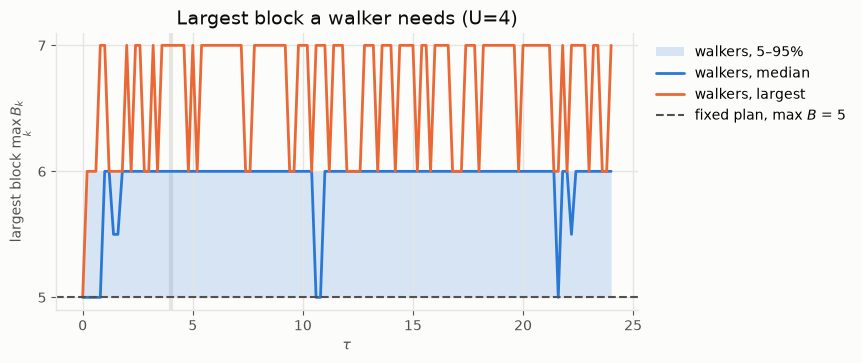

In [106]:
bmax = BS.max(axis=3).reshape(len(tau), -1)             # per walker-channel
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.fill_between(tau, np.percentile(bmax, 5, axis=1), np.percentile(bmax, 95, axis=1),
                color=PALETTE[0], alpha=0.18, lw=0, label="walkers, 5–95%")
ax.plot(tau, np.median(bmax, axis=1), color=PALETTE[0], label="walkers, median")
ax.plot(tau, bmax.max(axis=1), color=PALETTE[1], label="walkers, largest")
ax.axhline(B_REF.max(), color=INK2, ls="--", lw=1.5, label=f"fixed plan, max $B$ = {B_REF.max()}")
ax.axvline(tau[N_EQL], color=GRID, lw=3, zorder=0)
ax.set_xlabel(r"$\tau$"); ax.set_ylabel(r"largest block $\max_k B_k$")
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.set_title("Largest block a walker needs")
ax.legend(**LEGEND)
save(fig, "max_block"); plt.show()

The fixed plan is only wrong where a walker needs a *bigger* block than the plan gives it at the same site. A smaller one costs nothing, since the larger block still contains the pure mode. The plot shows, against $\tau$, the fraction of walker channels with at least one such site, and the fraction of all (walker, spin, site) entries that are too big.

saved fw_block_data/L32_U4_nw200_eps1e-10_s1234_excess_fraction.png


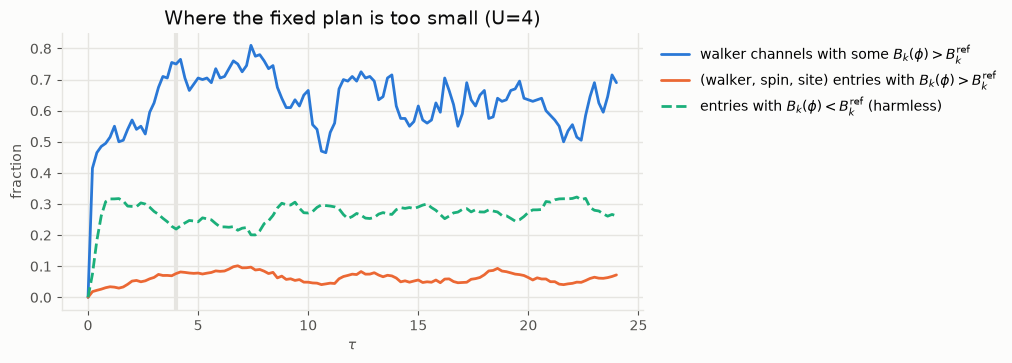

In [107]:
excess = BS - B_REF[None, None]                          # (n_snap, nw, 2, L-1)
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.plot(tau, (excess > 0).any(axis=3).mean(axis=(1, 2)), color=PALETTE[0],
        label=r"walker channels with some $B_k(\phi) > B_k^{\rm ref}$")
ax.plot(tau, (excess > 0).mean(axis=(1, 2, 3)), color=PALETTE[1],
        label=r"(walker, spin, site) entries with $B_k(\phi) > B_k^{\rm ref}$")
ax.plot(tau, (excess < 0).mean(axis=(1, 2, 3)), color=PALETTE[2], ls="--",
        label=r"entries with $B_k(\phi) < B_k^{\rm ref}$ (harmless)")
ax.axvline(tau[N_EQL], color=GRID, lw=3, zorder=0)
ax.set_xlabel(r"$\tau$"); ax.set_ylabel("fraction")
ax.set_title("Where the fixed plan is too small")
ax.legend(**LEGEND)
save(fig, "excess_fraction"); plt.show()

### Per site

The profile over the chain, averaged over walkers, spins and sampling snapshots, against the fixed plan. The plan shrinks toward the right end, because fewer sites remain to form a block.

saved fw_block_data/L32_U4_nw200_eps1e-10_s1234_site_profile.png


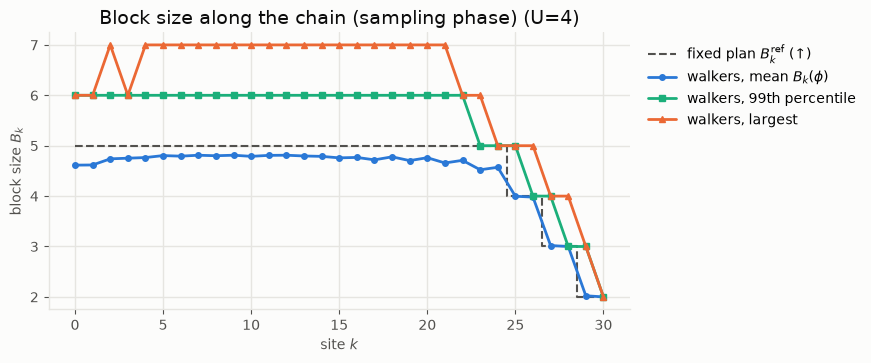

In [108]:
sites = np.arange(L - 1)
Bs = BS[samp].reshape(-1, L - 1)
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.step(sites, B_REF[0], where="mid", color=INK2, ls="--", lw=1.5, label=r"fixed plan $B_k^{\rm ref}$ (↑)")
if not np.array_equal(B_REF[0], B_REF[1]):
    ax.step(sites, B_REF[1], where="mid", color=INK2, ls=":", lw=1.5, label=r"fixed plan $B_k^{\rm ref}$ (↓)")
ax.plot(sites, Bs.mean(0), "o-", color=PALETTE[0], ms=4, label=r"walkers, mean $B_k(\phi)$")
ax.plot(sites, np.percentile(Bs, 99, axis=0), "s-", color=PALETTE[2], ms=4, label=r"walkers, 99th percentile")
ax.plot(sites, Bs.max(0), "^-", color=PALETTE[1], ms=4, label=r"walkers, largest")
ax.set_xlabel("site $k$"); ax.set_ylabel("block size $B_k$")
ax.set_title("Block size along the chain (sampling phase)")
ax.legend(**LEGEND)
save(fig, "site_profile"); plt.show()

The same excess resolved in both site and $\tau$: the fraction of walker channels whose block at site $k$ is larger than the plan's.

## What the fixed plan costs: the fidelity

$1-F$ with $F=F_\uparrow F_\downarrow$ per walker: the fraction of the walker's norm the fixed-block gMPS misses, before any bond truncation. The dotted line is the same quantity for the walkers' own plans, the floor set by $\varepsilon$.

saved fw_block_data/L32_U4_nw200_eps1e-10_s1234_infidelity.png


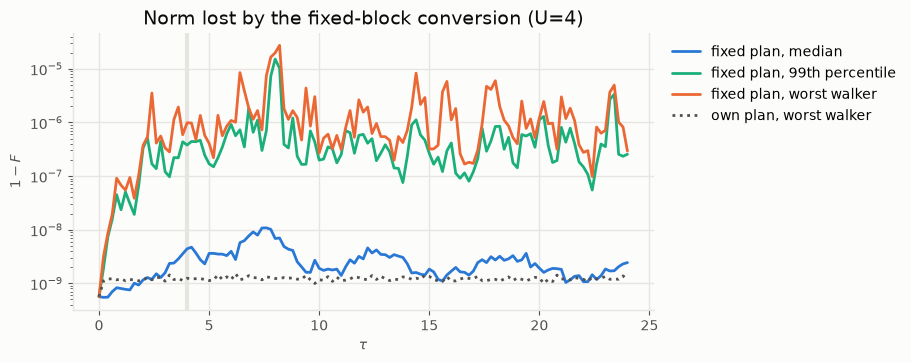

sampling phase, 20000 walker snapshots: 1-F median 2.4e-09, 99% 5.3e-07, 99.9% 4.4e-06, max 2.7e-05
own plan, max 1-F: 1.5e-09


In [109]:
inf_fixed = np.clip(1 - FF.prod(axis=2), 1e-17, None)    # (n_snap, nw)
inf_own = np.clip(1 - FO.prod(axis=2), 1e-17, None)
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.plot(tau, np.median(inf_fixed, axis=1), color=PALETTE[0], label="fixed plan, median")
ax.plot(tau, np.percentile(inf_fixed, 99, axis=1), color=PALETTE[2], label="fixed plan, 99th percentile")
ax.plot(tau, inf_fixed.max(axis=1), color=PALETTE[1], label="fixed plan, worst walker")
ax.plot(tau, inf_own.max(axis=1), color=INK2, ls=":", label="own plan, worst walker")
ax.axvline(tau[N_EQL], color=GRID, lw=3, zorder=0)
ax.set_yscale("log")
ax.set_xlabel(r"$\tau$"); ax.set_ylabel(r"$1-F$")
ax.set_title("Norm lost by the fixed-block conversion")
ax.legend(**LEGEND)
save(fig, "infidelity"); plt.show()

x = inf_fixed[samp].ravel()
print(f"sampling phase, {x.size} walker snapshots: 1-F median {np.median(x):.1e}, "
      f"99% {np.percentile(x, 99):.1e}, 99.9% {np.percentile(x, 99.9):.1e}, max {x.max():.1e}")
print(f"own plan, max 1-F: {inf_own[samp].max():.1e}")

Is the lost norm really caused by blocks that are too small? Each walker channel, sampling phase: $1-F_\sigma$ against the summed excess $\sum_k \max(B_k(\phi)-B_k^{\rm ref},0)$.

saved fw_block_data/L32_U4_nw200_eps1e-10_s1234_infidelity_vs_excess.png


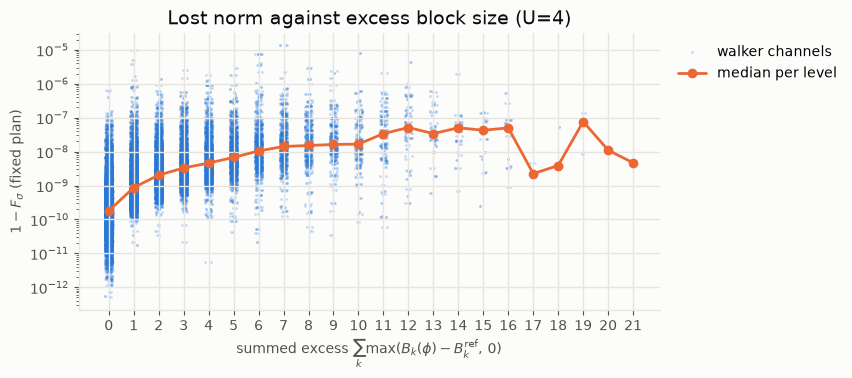

In [110]:
tot = np.clip(excess[samp], 0, None).sum(axis=3).ravel()
inf_ch = np.clip(1 - FF[samp].ravel(), 1e-17, None)
fig, ax = plt.subplots(figsize=(7.5, 3.6))
jitter = np.random.default_rng(0).uniform(-0.15, 0.15, tot.size)
ax.scatter(tot + jitter, inf_ch, s=4, alpha=0.25, color=PALETTE[0], lw=0, label="walker channels")
levels = np.unique(tot)
ax.plot(levels, [np.median(inf_ch[tot == v]) for v in levels], "o-", color=PALETTE[1], label="median per level")
ax.set_yscale("log"); ax.set_xticks(levels)
ax.set_xlabel(r"summed excess $\sum_k\max(B_k(\phi)-B_k^{\rm ref},\,0)$")
ax.set_ylabel(r"$1-F_\sigma$ (fixed plan)")
ax.set_title("Lost norm against excess block size")
ax.legend(**LEGEND)
save(fig, "infidelity_vs_excess"); plt.show()

## Truncating the gMPS

Production also truncates the walker bond: `walker_channel_chi` $=\chi_w$ per spin channel. `plan_bonds` does a dry run on the reference and freezes, gate by gate, how many singular vectors each charge sector keeps (the $\chi_w$ largest Schmidt values overall). `channel_mps(Q, plan, bond_plan)` then splits every walker with those fixed ranks. The orthogonality centre sits on the gate, so each split drops the walker's own smallest Schmidt values in each sector, but the *allocation* across sectors is the reference's.

For every snapshot and walker, and each $\chi_w$ in `CHI_W`:

- $F^{\rm bond}_\sigma=|\langle M_\sigma|M^{\chi_w}_\sigma\rangle|^2/\langle M^{\chi_w}_\sigma|M^{\chi_w}_\sigma\rangle$, where $M_\sigma$ is the untruncated fixed-plan gMPS (norm 1). This is the loss due to truncation alone; the total fidelity against the determinant is $\approx F_\sigma F^{\rm bond}_\sigma$.
- $\delta O=|O^{\chi_w}_\uparrow O^{\chi_w}_\downarrow/(O_\uparrow O_\downarrow)-1|$, with $O^{\chi_w}_\sigma=g_T\,g\,\langle\mathrm{gMPS}_T|M^{\chi_w}_\sigma\rangle$ and the exact $O_\sigma=\det(\Psi_\sigma^{\mathsf T}Q_\sigma)$. This is the error that reaches the CPMC ratios. The row "none" is the untruncated fixed plan, so it shows the block error in the same units.

Everything is jitted and vmapped over walkers with the static plan, as in `make_walker_ops`. This costs about 0.1 s per snapshot and spin, plus about 10 s of compilation per $\chi_w$. A $\chi_w$ at or above the plan's bond, $2^{\max B-1}$, is exact.

In [111]:
def jdot(A, B):
    E = jnp.ones((1, 1))
    for a, b in zip(A, B):
        E = jnp.einsum("ab,apc,bpd->cd", E, a, b)
    return E[0, 0]


PSI = (jnp.asarray(Ca), jnp.asarray(Cb))
TRIAL_GMPS = [channel_mps(C, p)[::2] for C, p in zip(PSI, PLAN)]      # (tensors, gauge) per spin
BONDS = {0: (None, None)}
for chi in CHI_W:
    BONDS[chi] = tuple(plan_bonds(C, p, chi, 0.0) for C, p in zip((Ca, Cb), PLAN))
    print(f"chi_w = {chi}: bond labels {max(len(q) for q in BONDS[chi][0].charges)}, reference discarded weight "
          f"{BONDS[chi][0].reference_discarded_weight:.1e} (↑)  {BONDS[chi][1].reference_discarded_weight:.1e} (↓)")


def make_truncated(s, bond):
    (tT, gT), plan, psi = TRIAL_GMPS[s], PLAN[s], PSI[s]

    def one(w):
        Q, _ = jnp.linalg.qr(w)
        full, _, g = channel_mps(Q, plan)
        cut = full if bond is None else channel_mps(Q, plan, bond)[0]
        kept = jdot(cut, cut)
        return jdot(full, cut) ** 2 / kept, kept, gT * g * jdot(tT, cut) / jnp.linalg.det(psi.T @ Q)
    return jax.jit(jax.vmap(one))


TR = {}
for chi, bond in BONDS.items():
    path = trunc_file(chi)
    if RERUN or not path.exists():
        start, res = time.perf_counter(), []
        for s in range(2):
            f = make_truncated(s, bond[s])
            res.append([np.asarray(jnp.stack(f(jnp.asarray(w)))) for w in WALK[s]])   # per snapshot (3, nw)
        res = np.asarray(res)                                        # (2, n_snap, 3, nw)
        np.savez_compressed(path, f_bond=res[:, :, 0].transpose(1, 2, 0), kept=res[:, :, 1].transpose(1, 2, 0),
                            ratio=res[:, :, 2].transpose(1, 2, 0))
        print(f"chi_w = {chi or 'none'}: {time.perf_counter() - start:.0f} s, saved {path}")
    TR[chi] = dict(np.load(path))                                    # arrays (n_snap, nw, 2)
    TR[chi]["dO"] = np.abs(TR[chi]["ratio"].prod(axis=2) - 1)        # (n_snap, nw)

print("\nsampling phase           1-F_bond (per spin)             delta O (per walker)          min kept norm")
print("  chi_w           median     99%       max        median     99%       max")
for chi, t in TR.items():
    fb, dO = 1 - t["f_bond"][samp].ravel(), t["dO"][samp].ravel()
    print(f"  {str(chi or 'none'):>5}        {np.median(fb):9.1e} {np.percentile(fb, 99):9.1e} {fb.max():9.1e}"
          f"   {np.median(dO):9.1e} {np.percentile(dO, 99):9.1e} {dO.max():9.1e}     {t['kept'][samp].min():.4f}")

chi_w = 2: bond labels 2, reference discarded weight 1.0e-02 (↑)  1.0e-02 (↓)
chi_w = 4: bond labels 4, reference discarded weight 3.1e-05 (↑)  3.1e-05 (↓)
chi_w = 8: bond labels 8, reference discarded weight 5.0e-09 (↑)  5.0e-09 (↓)

sampling phase           1-F_bond (per spin)             delta O (per walker)          min kept norm
  chi_w           median     99%       max        median     99%       max
   none         -1.3e-15   7.0e-15   1.3e-14     7.7e-08   5.7e-06   2.9e-04     1.0000
      2          4.4e-02   6.9e-01   1.0e+00     3.2e-02   3.8e-01   9.7e-01     0.0068
      4          2.2e-04   1.5e-02   2.4e-01     4.0e-04   3.5e-02   2.6e-01     0.7601
      8          3.3e-09   2.5e-06   2.2e-03     2.3e-06   2.4e-04   3.9e-03     0.9978


saved fw_block_data/L32_U4_nw200_eps1e-10_s1234_truncation_fidelity.png


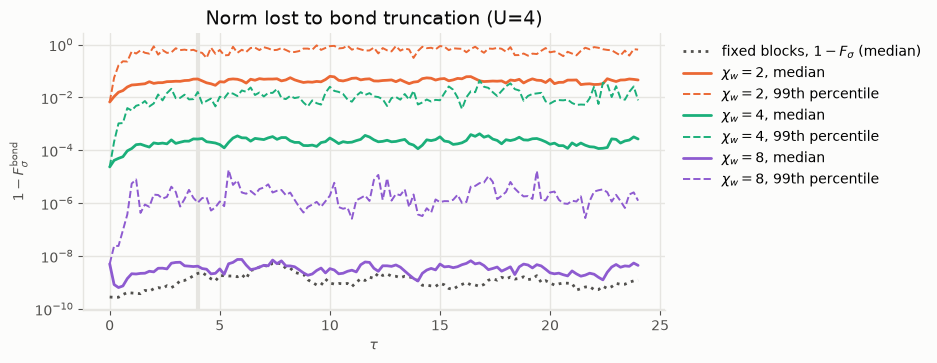

saved fw_block_data/L32_U4_nw200_eps1e-10_s1234_truncation_overlap_error.png


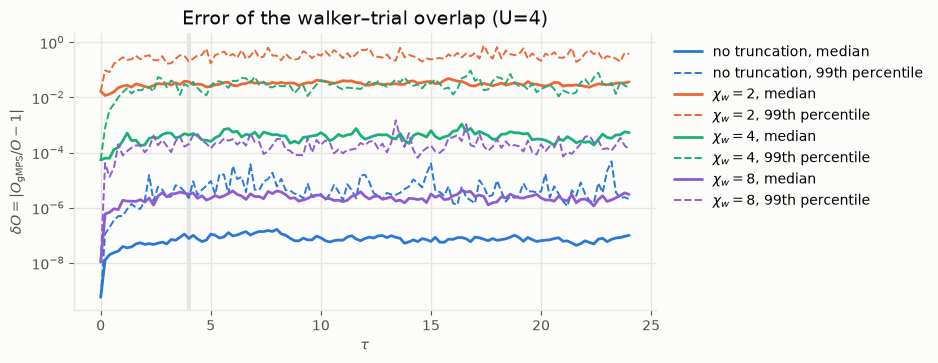

In [112]:
CHI_COLOR = {chi: PALETTE[i % len(PALETTE)] for i, chi in enumerate(TR)}
chi_label = lambda chi: "no truncation" if chi == 0 else rf"$\chi_w={chi}$"

fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.plot(tau, np.median(np.clip(1 - FF, 1e-17, None).reshape(len(tau), -1), axis=1), color=INK2, ls=":",
        label=r"fixed blocks, $1-F_\sigma$ (median)")
for chi in CHI_W:
    x = np.clip(1 - TR[chi]["f_bond"], 1e-17, None).reshape(len(tau), -1)
    ax.plot(tau, np.median(x, axis=1), color=CHI_COLOR[chi], label=f"{chi_label(chi)}, median")
    ax.plot(tau, np.percentile(x, 99, axis=1), color=CHI_COLOR[chi], ls="--", lw=1.4, label=f"{chi_label(chi)}, 99th percentile")
ax.axvline(tau[N_EQL], color=GRID, lw=3, zorder=0)
ax.set_yscale("log")
ax.set_xlabel(r"$\tau$"); ax.set_ylabel(r"$1-F^{\rm bond}_\sigma$")
ax.set_title("Norm lost to bond truncation")
ax.legend(**LEGEND)
save(fig, "truncation_fidelity"); plt.show()

fig, ax = plt.subplots(figsize=(7.5, 3.6))
for chi in TR:
    x = np.clip(TR[chi]["dO"], 1e-17, None)
    ax.plot(tau, np.median(x, axis=1), color=CHI_COLOR[chi], label=f"{chi_label(chi)}, median")
    ax.plot(tau, np.percentile(x, 99, axis=1), color=CHI_COLOR[chi], ls="--", lw=1.4, label=f"{chi_label(chi)}, 99th percentile")
ax.axvline(tau[N_EQL], color=GRID, lw=3, zorder=0)
ax.set_yscale("log")
ax.set_xlabel(r"$\tau$"); ax.set_ylabel(r"$\delta O=|O_{\rm gMPS}/O-1|$")
ax.set_title("Error of the walker–trial overlap")
ax.legend(**LEGEND)
save(fig, "truncation_overlap_error"); plt.show()

saved fw_block_data/L32_U4_nw200_eps1e-10_s1234_energy.png


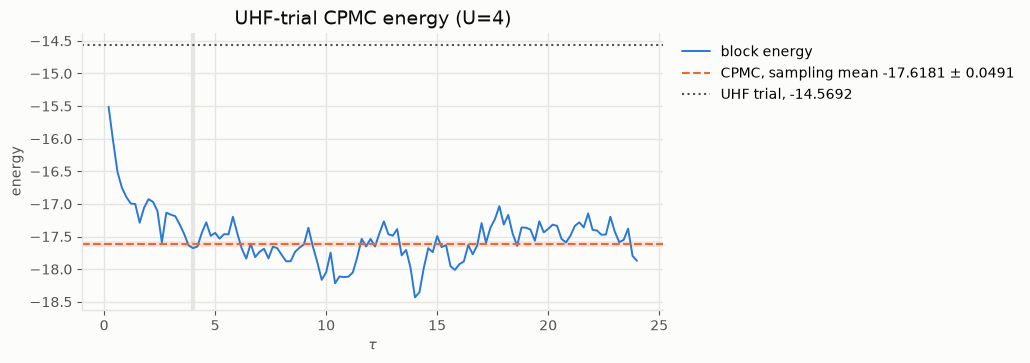

In [113]:
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.plot(tau[1:], energies, color=PALETTE[0], lw=1.4, label="block energy")
ax.axhline(E_MEAN, color=PALETTE[1], ls="--", lw=1.5,
           label=f"CPMC, sampling mean {E_MEAN:.4f} ± {E_ERR:.4f}")
if np.isfinite(E_ERR):
    ax.axhspan(E_MEAN - E_ERR, E_MEAN + E_ERR, color=PALETTE[1], alpha=0.15, lw=0)
ax.axhline(E_UHF, color=INK2, ls=":", lw=1.5, label=f"UHF trial, {E_UHF:.4f}")
ax.axvline(tau[N_EQL], color=GRID, lw=3, zorder=0)
ax.set_xlabel(r"$\tau$"); ax.set_ylabel("energy")
ax.set_title("UHF-trial CPMC energy")
ax.legend(**LEGEND)
save(fig, "energy"); plt.show()

## Three sources of error: fixed blocks, fixed particle counts, bond truncation

`entanglement_vs_gmps.ipynb` found, on $L\le12$ walkers with exact dense references, that production's truncated conversion loses far more to the **per-sector kept counts frozen on the reference** than to the fixed blocks. This section and the next ones measure the same split at $L=32$, for the UHF trial above and for a DMRG trial.

`plan_bonds` freezes, gate by gate, how many singular vectors each charge sector keeps. The charge is the number of electrons left of the gate, so these are **fixed particle counts** per sector. A walker whose Schmidt weight sits in different sectors than the reference's still has to use the reference's allocation. Production's conversion of a walker spin channel therefore makes three approximations, measured separately:

| source | conversion compared | against | quantity |
|---|---|---|---|
| **fixed blocks** | fixed plan, untruncated | the walker determinant | $1-F$, from $\det R[\mathrm{occ},:]^2$ |
| **bond truncation** | fixed plan, bond $\chi_w$, **the walker's own kept counts** | the untruncated fixed-plan gMPS | $\varepsilon^{\rm own}(\chi_w)=1-F^{\rm bond}_{\rm own}$ |
| **fixed particle counts** | fixed plan, bond $\chi_w$, **kept counts frozen on the reference** (production) | the untruncated fixed-plan gMPS | $\varepsilon^{\rm prod}(\chi_w)-\varepsilon^{\rm own}(\chi_w)$ |

- **The walker's own counts** are what `plan_bonds(Q, plan, χ_w)` would freeze if run on the walker itself: at every gate, the $\chi_w$ largest Schmidt values over all sectors survive. `channel_mps_own` below builds that state with static shapes. It keeps the untruncated bonds (16 for the UHF plan, 32 for the NO plan) and zeroes the discarded singular values, so it jits and vmaps like production. The check cell compares it with `channel_mps(Q, plan, plan_bonds(Q, plan, χ_w))` on single walkers.
- **The optimum** $a(\chi)=\max_b\varepsilon_b(\chi)$, with $\varepsilon_b(\chi)=1-\sum_{i\le\chi}\lambda^{(b)}_i$, is the lower bound no MPS with bond $\chi$ can beat. At $L=32$ there's no dense state, so the Schmidt values $\lambda^{(b)}$ come from the correlation spectrum $\nu$ on one side of the cut, as products $\prod_k(\nu_k\text{ or }1-\nu_k)$. `entanglement_vs_gmps.ipynb` checked this formula against the dense SVD to $5\times10^{-15}$; the cell below repeats the check at $L=10$, including the charges. The own counts should sit just above $a$, and production far above.
- **Dominant sector.** The charge of a walker's largest Schmidt value at cut $b$ is the number of $\nu>1/2$ on the left side. If the frozen allocation keeps no state in that sector at some cut, the walker loses most of its norm there.
- **Overlap errors.** $\delta O=|O^{\chi_w}/O^{\rm full}-1|$ is taken per walker (both spins) against the untruncated fixed-plan gMPS. For the DMRG trial, $O=\langle\Psi_T|\phi_\uparrow\phi_\downarrow\rangle$ is contracted site by site without forming the d=4 walker. The fixed blocks' own $\delta O$ needs a reference beyond the fixed plan: the exact $\det\Psi_\sigma^{\mathsf T}Q_\sigma$ exists only for the UHF trial, so both trials use a wider plan (see below), checked against the exact overlap on the UHF walkers.

The three infidelities add to first order: the gMPS production builds has $1-F\approx(1-F_{\rm fixed})+\varepsilon^{\rm prod}$ against the determinant.

In [114]:
def channel_mps_own(C, plan, chi):
    # channel_mps with the walker's own kept counts: the same circuit and centre moves on untruncated shapes, but
    # every split zeroes all but the chi largest Schmidt values over its charge sectors. That is the state
    # channel_mps(C, plan, plan_bonds(C, plan, chi)) builds, with static shapes, so it vmaps over walkers.
    tensors = [jnp.eye(2)[int(o)].reshape(1, 2, 1) for o in plan.occupation]
    charges = [np.zeros(1, int)]
    for o in plan.occupation:
        charges.append(charges[-1] + int(o))
    angles, _ = channel_angles(C, plan)
    centre = None
    for site, theta in reversed(angles):
        centre = _move_centre(tensors, charges, centre, site)
        pair = gate_pair(tensors[site], tensors[site + 1], theta)
        Dl, _, _, Dr = pair.shape
        M = pair.reshape(2 * Dl, 2 * Dr)
        sp = sector_plan(charges[site], charges[site + 2])
        svds = [jnp.linalg.svd(M[np.ix_(r, c)], full_matrices=False) for r, c, _ in sp.sectors]
        s_all = jnp.concatenate([s for _, s, _ in svds])
        keep = jnp.zeros(s_all.shape).at[jnp.argsort(-s_all)[:chi]].set(1.0)
        left, right, offset = [], [], 0
        for u, s, vh in svds:
            k = keep[offset:offset + s.shape[0]]
            offset += s.shape[0]
            left.append(u * k)
            right.append((s * k)[:, None] * vh)
        A, B = _assemble(left, right, sp)
        tensors[site], tensors[site + 1] = A.reshape(Dl, 2, -1), B.reshape(-1, 2, Dr)
        charges[site + 1] = sp.middle_charges
        centre = site + 1
    return tensors, charges


def dmrg_overlap(alpha, beta, qb):
    # <Psi_T | alpha x beta> for the DMRG trial, site by site with an environment E[a, b, t], without forming the
    # d=4 walker. The sign (-1)^(n_up q_dn), q_dn = down electrons left of the site, is combine_channels' reordering.
    E = jnp.ones((1, 1, 1))
    for A, B, q, Tt in zip(alpha, beta, qb, DMRG_TJ):
        sign = jnp.asarray((-1.0) ** np.asarray(q))
        E = sum(jnp.einsum("abt,ar,b,bs,tu->rsu", E, A[:, na, :], sign if na else jnp.ones_like(sign), B[:, nb, :],
                           Tt[:, na + 2 * nb, :], optimize=True) for na in (0, 1) for nb in (0, 1))
    return E[0, 0, 0]


def uhf_overlap(alpha, beta, qb):
    # <Psi_T | alpha x beta> for the UHF trial: one gMPS overlap per spin, with the trial's gauges
    (tA, gA), (tB, gB) = TRIAL_GMPS
    return gA * gB * jdot(tA, alpha) * jdot(tB, beta)


def make_errors(plans, bonds, chi, overlap):
    # one walker, both spins, on the fixed circuit: untruncated (full), production (kept counts frozen on the
    # reference) and own counts. Infidelities are against the full gMPS, overlaps relative to the full one's.
    def one(wa, wb):
        full, prod, own, gauge = [], [], [], []
        for s, w in enumerate((wa, wb)):
            Q, _ = jnp.linalg.qr(w)
            A, q, g = channel_mps(Q, plans[s])
            full.append((A, q))
            gauge.append(g)
            prod.append(channel_mps(Q, plans[s], bonds[s])[:2])
            own.append(channel_mps_own(Q, plans[s], chi))
        infid = lambda X, Y: 1 - jdot(X, Y) ** 2 / (jdot(X, X) * jdot(Y, Y))
        O = lambda v: overlap(v[0][0], v[1][0], v[1][1])
        O_full = O(full)
        return dict(gauge=jnp.stack(gauge),
                    prod=jnp.stack([infid(f[0], p[0]) for f, p in zip(full, prod)]),
                    own=jnp.stack([infid(f[0], o[0]) for f, o in zip(full, own)]),
                    kept_prod=jnp.stack([jdot(p[0], p[0]) for p in prod]),
                    kept_own=jnp.stack([jdot(o[0], o[0]) for o in own]),
                    O_full=gauge[0] * gauge[1] * O_full, r_prod=O(prod) / O_full, r_own=O(own) / O_full)
    return jax.jit(jax.vmap(one))


def top_schmidt(nu, chi, left, n):
    # the chi largest Schmidt values prod_k (nu_k or 1 - nu_k) at a cut and their charges (electrons left of the
    # cut), by a best-first search over flipped modes. nu: correlation spectrum of the left side (left=True) or of
    # the right side; n: electrons in the channel. Flipping a mode moves one electron out of or into that side.
    p = np.maximum(nu, 1 - nu)
    w = np.minimum(nu, 1 - nu) / p
    order = np.argsort(-w)
    w, step = w[order], np.where(nu[order] > 0.5, -1, 1)
    w, step = w[w > 0], step[w > 0]
    q0 = int(np.sum(nu > 0.5))
    if not left:
        q0, step = n - q0, -step
    P0 = float(np.prod(p))
    vals, qs, heap = [P0], [q0], []
    if len(w):
        heapq.heappush(heap, (-P0 * w[0], 0, P0 * w[0], q0 + step[0]))
    while heap and len(vals) < chi:
        _, j, val, q = heapq.heappop(heap)
        vals.append(val)
        qs.append(q)
        if j + 1 < len(w):
            heapq.heappush(heap, (-val * w[j + 1], j + 1, val * w[j + 1], q + step[j + 1]))      # also flip j+1
            swap = val / w[j] * w[j + 1]
            heapq.heappush(heap, (-swap, j + 1, swap, q - step[j] + step[j + 1]))              # flip j+1 instead of j
    return np.array(vals), np.array(qs, int)


def cut_top(Q, chi):
    # per cut b = 1..L-1: top_schmidt on the smaller side of the cut (the larger side only adds pure modes)
    L, n = Q.shape
    out = []
    for b in range(1, L):
        side = Q[:b] if b <= L - b else Q[b:]
        out.append(top_schmidt(np.clip(np.linalg.eigvalsh(side @ side.T), 0.0, 1.0), chi, b <= L - b, n))
    return out


# ---- check 1: Schmidt values and charges from nu against the dense state, one random L=10 determinant
from itertools import combinations
rng = np.random.default_rng(1)
Lc, Nc = 10, 4
Qc = np.linalg.qr(rng.standard_normal((Lc, Nc)))[0]
combos = np.array(list(combinations(range(Lc), Nc)))
psi = np.zeros(2 ** Lc)
psi[(1 << (Lc - 1 - combos)).sum(axis=1)] = np.linalg.det(Qc[combos])
pop = np.array([bin(i).count("1") for i in range(2 ** Lc)])
worst_val, mismatches = 0.0, 0
for b, (vals, qs) in enumerate(cut_top(Qc, 12), start=1):
    M = psi.reshape(2 ** b, -1)
    dense = sorted(((s ** 2, q) for q in range(max(0, Nc - (Lc - b)), min(b, Nc) + 1) for s in np.linalg.svd(
        M[np.ix_(pop[:2 ** b] == q, pop[:2 ** (Lc - b)] == Nc - q)], compute_uv=False)), reverse=True)[:len(vals)]
    worst_val = max(worst_val, np.abs(vals - [d[0] for d in dense]).max())
    mismatches += sorted(zip(np.round(vals, 12), qs)) != sorted((round(d[0], 12), d[1]) for d in dense)
print(f"nu products vs dense SVD (L={Lc}, 12 largest per cut): max |lambda difference| {worst_val:.1e}, "
      f"cuts with a charge mismatch {mismatches} of {Lc - 1}")

# ---- check 2: own counts against plan_bonds run on the walker, and production against the cached run above
w = 7
Q = np.linalg.qr(WALK[0][-1, w])[0]
for chi in CHI_W:
    own, _ = jax.jit(lambda q: channel_mps_own(q, PLAN[0], chi))(jnp.asarray(Q))
    bond_w = plan_bonds(Q, PLAN[0], chi, 0.0)
    ref = channel_mps(jnp.asarray(Q), PLAN[0], bond_w)[0]
    print(f"chi_w = {chi}: own counts vs channel_mps(Q, plan, plan_bonds(Q, ...)): 1 - fidelity "
          f"{1 - float(jdot(own, ref)) ** 2 / float(jdot(own, own) * jdot(ref, ref)):.1e}; kept norm "
          f"{float(jdot(own, own)):.12f} vs 1 - discarded {1 - bond_w.reference_discarded_weight:.12f}")

nu products vs dense SVD (L=10, 12 largest per cut): max |lambda difference| 1.2e-15, cuts with a charge mismatch 0 of 9
chi_w = 2: own counts vs channel_mps(Q, plan, plan_bonds(Q, ...)): 1 - fidelity 6.7e-16; kept norm 0.944057877385 vs 1 - discarded 0.944057872577
chi_w = 4: own counts vs channel_mps(Q, plan, plan_bonds(Q, ...)): 1 - fidelity 5.6e-16; kept norm 0.999986599090 vs 1 - discarded 0.999986599090
chi_w = 8: own counts vs channel_mps(Q, plan, plan_bonds(Q, ...)): 1 - fidelity 1.8e-15; kept norm 0.999999999776 vs 1 - discarded 0.999999999776


## A DMRG trial

The same analysis on the walkers of a **DMRG-trial** CPMC. Everything follows production (`mps_cpmc_new.py` with its defaults `plan_reference="natural"`, `walker_start="natural"`):

- **Trial.** `run_dmrg` at bond $\chi_T$ = `DMRG_CHI_T`, as in the L=32 production sweeps. Then `densify_with_charges`, and $H|\Psi_T\rangle$ from `hubbard_mpo`, `apply_mpo` and `compress_mps`.
- **Plan reference.** The determinant of the $N_\sigma$ most occupied natural orbitals of each spin (`one_rdm`, `natural_orbitals`). It freezes both the gate circuit (`make_orbital_plan(..., "adaptive")`) and the kept counts (`plan_bonds`), and every walker starts there.
- **Walkers.** At $L=32$ the DMRG overlap is not available exactly, so the walkers come from production's own MPS-CPMC: `make_walker_ops` and `make_fast_prop_ops`, with walker bond `CHI_PROP` per spin channel. It's the ensemble production samples, with its own truncation in the importance function. The CPMC parameters (walkers, $\Delta\tau$, blocks, seed, weight floor and cap) are the ones of the UHF run above. The walkers are saved after every block exactly as for the UHF run.

**Cost.** The run is the slow step of this notebook. With 16 walkers it takes 5 minutes: about 2.5 minutes of compilation, then about 1 s per block. For 200 walkers, expect roughly half an hour; this is extrapolated from production's L=32 runs, not measured. Its walkers file is cached, like the UHF one, so it runs once. The analysis cells after it take about 10 minutes in total (mostly compilation), and each stage is cached as well.

In [115]:
DMRG_FILE = DATA_DIR / f"dmrg_trial_L{L}_U{U:g}_chi{DMRG_CHI_T}.npz"
if RERUN or not DMRG_FILE.exists():
    cfg = mcn.Config(L=L, n_up=N_UP, n_down=N_DN, hopping=T, interaction=U, trial_chi=DMRG_CHI_T, dmrg_sweeps=DMRG_SWEEPS)
    start = time.perf_counter()
    dmrg_mps, e_dmrg = mcn.run_dmrg(mcn.build_dmrg_hamiltonian(cfg), cfg)
    tensors, charges = mcn.densify_with_charges(dmrg_mps, L)
    h_tensors = mcn.compress_mps(mcn.apply_mpo(mcn.hubbard_mpo(L, T, U), tensors))
    np.savez_compressed(DMRG_FILE, e_dmrg=e_dmrg, **{f"T{i}": A for i, A in enumerate(tensors)},
                        **{f"H{i}": A for i, A in enumerate(h_tensors)}, **{f"q{i}": q for i, q in enumerate(charges)})
    print(f"DMRG in {time.perf_counter() - start:.0f} s; saved {DMRG_FILE}")

z = np.load(DMRG_FILE)
DMRG_T = [z[f"T{i}"] for i in range(L)]                  # trial MPS, d=4, local index n_up + 2 n_dn
DMRG_H = [z[f"H{i}"] for i in range(L)]                  # H |trial>, compressed
DMRG_Q = tuple(z[f"q{i}"] for i in range(L + 1))         # its (N_up, N_dn) bond labels
E_DMRG = float(z["e_dmrg"])
E_VAR = float(mcn.contract_real(DMRG_H, DMRG_T) / mcn.contract_real(DMRG_T, DMRG_T))
GAMMA = mcn.one_rdm(DMRG_T)
NO = tuple(mcn.natural_orbitals(g, n)[0] for g, n in zip(GAMMA, (N_UP, N_DN)))    # plan_reference="natural"
PLAN_NO = [make_orbital_plan(C, "adaptive", EPS) for C in NO]
B_NO = np.stack([p.block_sizes for p in PLAN_NO])
occ = mcn.natural_orbitals(GAMMA[0], N_UP)[1]
print(f"DMRG trial chi_T = {DMRG_CHI_T}: E = {E_DMRG:.8f} (<H> of the dense MPS {E_VAR:.8f}), bonds up to {max(A.shape[0] for A in DMRG_T)}")
print(f"natural occupations around the Fermi level (↑): {np.round(occ[N_UP - 3:N_UP + 3], 3)}")
for s, p in zip("↑↓", PLAN_NO):
    print(f"NO plan, spin {s}: B_k = {p.block_sizes.tolist()}, gates {int((p.block_sizes - 1).sum())}, "
          f"bond up to 2^(B-1) = {2 ** (p.block_sizes.max() - 1)}")

DMRG trial chi_T = 8: E = -17.85366586 (<H> of the dense MPS -17.84893585), bonds up to 8
natural occupations around the Fermi level (↑): [0.785 0.76  0.753 0.247 0.239 0.214]
NO plan, spin ↑: B_k = [6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 5, 5, 4, 4, 3, 3, 2, 2], gates 135, bond up to 2^(B-1) = 32
NO plan, spin ↓: B_k = [6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 5, 5, 4, 4, 3, 3, 2, 2], gates 135, bond up to 2^(B-1) = 32


In [116]:
DMRG_TAG = f"{RUN_TAG}_dmrgT{DMRG_CHI_T}_w{CHI_PROP}"
DMRG_WALKERS = DATA_DIR / f"{DMRG_TAG}_walkers.npz"
if RERUN or not DMRG_WALKERS.exists():
    bonds = [plan_bonds(C, p, CHI_PROP, 0.0) for C, p in zip(NO, PLAN_NO)]
    wops = mcn.make_walker_ops(*NO, *PLAN_NO, *bonds, DMRG_T, DMRG_Q, tuple(jnp.asarray(A) for A in DMRG_H))
    dmrg_prop = mcn.make_fast_prop_ops(ham, system.walker_kind, wops.overlap, wops.sweep)
    dmrg_trial_ops = make_auto_trial_ops(system, overlap_u=wops.overlap, get_rdm1=uhf_get_rdm1)
    dmrg_meas = MeasOps(overlap=wops.overlap, kernels={k_energy: wops.energy})
    start_det = UhfTrial(mo_coeff_a=jnp.asarray(NO[0]), mo_coeff_b=jnp.asarray(NO[1]))   # only its orbitals are used: the walker start
    run_blocks, ctx, state = setup(dmrg_prop, dmrg_trial_ops, dmrg_meas, start_det, ham, params)
    n_total = N_EQL + N_BLOCKS
    snaps_up, snaps_dn, energies_d, weights_d = [], [], [], []
    start = time.perf_counter()
    for b in range(n_total + 1):
        if b:
            state, scalars, _ = run_blocks(state, **ctx, n_blocks=1)
            energies_d.append(float(scalars["energy"][0]))
            weights_d.append(float(scalars["weight"][0]))
        snaps_up.append(np.asarray(state.walkers[0]))
        snaps_dn.append(np.asarray(state.walkers[1]))
        if b % 10 == 0:
            print(f"block {b:4d}/{n_total}  E {energies_d[-1] if b else float(state.e_estimate):12.6f}"
                  f"  t {time.perf_counter() - start:6.1f} s", flush=True)
    config = dict(L=L, N_UP=N_UP, N_DN=N_DN, T=T, U=U, N_WALKERS=N_WALKERS, N_EQL=N_EQL, N_BLOCKS=N_BLOCKS,
                  N_PROP=N_PROP, DT=DT, SEED=SEED, DMRG_CHI_T=DMRG_CHI_T, CHI_PROP=CHI_PROP, E_DMRG=E_DMRG)
    np.savez_compressed(DMRG_WALKERS, up=np.stack(snaps_up), dn=np.stack(snaps_dn), energies=np.array(energies_d),
                        weights=np.array(weights_d), config=json.dumps(config))
    print(f"saved {DMRG_WALKERS}")

run_d = np.load(DMRG_WALKERS)
WALK_D = (run_d["up"], run_d["dn"])
energies_d, weights_d = run_d["energies"], run_d["weights"]
stats_d = blocking_analysis_ratio(energies_d[N_EQL:], weights_d[N_EQL:], print_q=False)
E_MEAN_D = float(stats_d["mu"])
E_ERR_D = float("nan") if stats_d["se_star"] is None else float(stats_d["se_star"])
print(f"{WALK_D[0].shape[0]} snapshots x {WALK_D[0].shape[1]} walkers;  CPMC energy (DMRG trial): "
      f"{E_MEAN_D:.6f} +- {E_ERR_D:.6f}   (DMRG trial {E_DMRG:.6f}, UHF trial CPMC {E_MEAN:.6f} +- {E_ERR:.6f})")

121 snapshots x 200 walkers;  CPMC energy (DMRG trial): -17.975331 +- 0.003239   (DMRG trial -17.853666, UHF trial CPMC -17.618055 +- 0.049117)


In [117]:
DMRG_TJ = [jnp.asarray(A) for A in DMRG_T]
DATA_D = DATA_DIR / f"{DMRG_TAG}_eps{EPS:.0e}.npz"                  # block sizes and fixed-plan fidelities
if RERUN or not DATA_D.exists():
    start, out = time.perf_counter(), [analyse((up, dn), PLAN_NO) for up, dn in zip(*WALK_D)]
    np.savez_compressed(DATA_D, block_sizes=np.stack([o[0] for o in out]), fid_fixed=np.stack([o[1] for o in out]),
                        fid_own=np.stack([o[2] for o in out]), plan_block_sizes=B_NO)
    print(f"analysed {len(out)} snapshots in {time.perf_counter() - start:.0f} s; saved {DATA_D}")
data_d = np.load(DATA_D)
BS_D, FF_D, FO_D = data_d["block_sizes"].astype(int), data_d["fid_fixed"], data_d["fid_own"]

# check: the environment contraction dmrg_overlap against production's combine_channels + contract_real
Qa, Qb = (np.linalg.qr(W[-1, 0])[0] for W in WALK_D)
bonds_prop = [plan_bonds(C, p, CHI_PROP, 0.0) for C, p in zip(NO, PLAN_NO)]
(a, qa, _), (b, qb, _) = (channel_mps(jnp.asarray(Q), p, bp) for Q, p, bp in zip((Qa, Qb), PLAN_NO, bonds_prop))
ours, theirs = float(dmrg_overlap(a, b, qb)), float(mcn.contract_real(mcn.combine_channels(a, qa, b, qb)[0], DMRG_TJ))
print(f"dmrg_overlap vs combine_channels + contract_real: {ours:+.12e} vs {theirs:+.12e}, rel. diff {abs(ours / theirs - 1):.1e}")

stag = np.diag((-1.0) ** np.arange(L))
P_up, P_dn = (x @ x.T for x in (Qa, Qb))
print(f"particle-hole symmetry, a final walker: max |P_dn - (1 - S P_up S)| = "
      f"{np.abs(P_dn - (np.eye(L) - stag @ P_up @ stag)).max():.1e}  (both spins are analysed regardless)")
excess_d = BS_D - B_NO[None, None]
x = np.clip(1 - FF_D.prod(axis=2), 0, None)[samp].ravel()
print(f"sampling phase: B_k(phi) > B_k^ref in {(excess_d[samp] > 0).mean():.2%} of (walker, spin, site) entries, "
      f"{(excess_d[samp] > 0).any(axis=3).mean():.1%} of walker channels; largest walker block {BS_D[samp].max()} "
      f"(NO plan {B_NO.max()})")
print(f"fixed NO plan, 1-F per walker: median {np.median(x):.1e}, 99% {np.percentile(x, 99):.1e}, max {x.max():.1e}; "
      f"own plans, max {np.clip(1 - FO_D.prod(axis=2), 0, None)[samp].max():.1e}")

dmrg_overlap vs combine_channels + contract_real: -1.540979847316e-02 vs -1.540979847316e-02, rel. diff 1.1e-15
particle-hole symmetry, a final walker: max |P_dn - (1 - S P_up S)| = 6.3e-15  (both spins are analysed regardless)
sampling phase: B_k(phi) > B_k^ref in 0.44% of (walker, spin, site) entries, 6.3% of walker channels; largest walker block 7 (NO plan 6)
fixed NO plan, 1-F per walker: median 3.7e-11, 99% 3.2e-08, max 4.0e-06; own plans, max 1.6e-09


The block sizes of the DMRG-trial walkers, as in the UHF section's first plots: the largest block each walker needs along the run, and the profile along the chain against the NO plan. The walkers' own block sizes don't depend on the plan reference; the dashed lines do.

saved fw_block_data/L32_U4_nw200_eps1e-10_s1234_max_block_dmrg.png


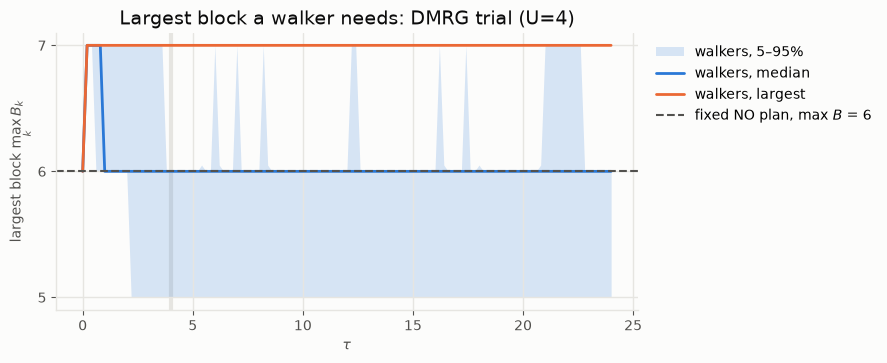

saved fw_block_data/L32_U4_nw200_eps1e-10_s1234_site_profile_dmrg.png


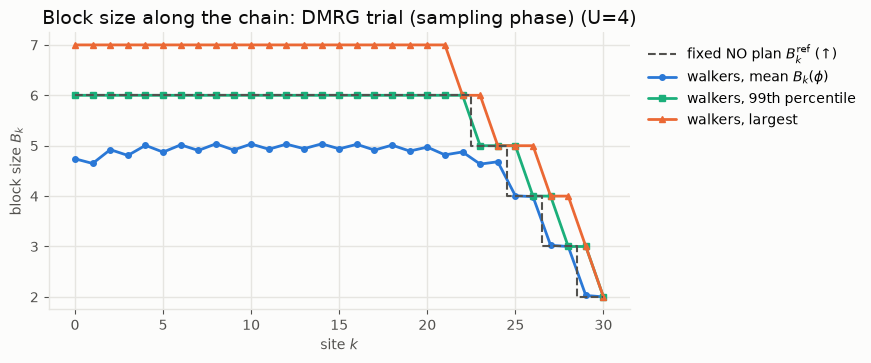

largest block per walker channel, sampling phase:
  UHF trial : B = 4: 0.0%,  B = 5: 35.9%,  B = 6: 63.3%,  B = 7: 0.8%
  DMRG trial: B = 5: 19.6%,  B = 6: 76.6%,  B = 7: 3.8%


In [118]:
# the block-size plots of the UHF section, for the DMRG-trial walkers against the NO plan
bmax_d = BS_D.max(axis=3).reshape(BS_D.shape[0], -1)            # per walker channel
tau_d = np.arange(BS_D.shape[0]) * N_PROP * DT
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.fill_between(tau_d, np.percentile(bmax_d, 5, axis=1), np.percentile(bmax_d, 95, axis=1),
                color=PALETTE[0], alpha=0.18, lw=0, label="walkers, 5–95%")
ax.plot(tau_d, np.median(bmax_d, axis=1), color=PALETTE[0], label="walkers, median")
ax.plot(tau_d, bmax_d.max(axis=1), color=PALETTE[1], label="walkers, largest")
ax.axhline(B_NO.max(), color=INK2, ls="--", lw=1.5, label=f"fixed NO plan, max $B$ = {B_NO.max()}")
ax.axvline(tau_d[N_EQL], color=GRID, lw=3, zorder=0)
ax.set_xlabel(r"$\tau$"); ax.set_ylabel(r"largest block $\max_k B_k$")
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.set_title("Largest block a walker needs: DMRG trial")
ax.legend(**LEGEND)
save(fig, "max_block_dmrg"); plt.show()

sites = np.arange(L - 1)
Bs_d = BS_D[samp].reshape(-1, L - 1)
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.step(sites, B_NO[0], where="mid", color=INK2, ls="--", lw=1.5, zorder=3, label=r"fixed NO plan $B_k^{\rm ref}$ (↑)")
if not np.array_equal(B_NO[0], B_NO[1]):
    ax.step(sites, B_NO[1], where="mid", color=INK2, ls=":", lw=1.5, zorder=3, label=r"fixed NO plan $B_k^{\rm ref}$ (↓)")
ax.plot(sites, Bs_d.mean(0), "o-", color=PALETTE[0], ms=4, label=r"walkers, mean $B_k(\phi)$")
ax.plot(sites, np.percentile(Bs_d, 99, axis=0), "s-", color=PALETTE[2], ms=4, label=r"walkers, 99th percentile")
ax.plot(sites, Bs_d.max(0), "^-", color=PALETTE[1], ms=4, label=r"walkers, largest")
ax.set_xlabel("site $k$"); ax.set_ylabel("block size $B_k$")
ax.set_title("Block size along the chain: DMRG trial (sampling phase)")
ax.legend(**LEGEND)
save(fig, "site_profile_dmrg"); plt.show()

print("largest block per walker channel, sampling phase:")
for label, B in (("UHF trial ", BS), ("DMRG trial", BS_D)):
    vals, counts = np.unique(B[samp].max(axis=3), return_counts=True)
    print(f"  {label}: " + ",  ".join(f"B = {v}: {c / counts.sum():.1%}" for v, c in zip(vals, counts)))

In [119]:
BONDS_NO = {chi: tuple(plan_bonds(C, p, chi, 0.0) for C, p in zip(NO, PLAN_NO)) for chi in CHI_W}
for chi in CHI_W:
    print(f"NO reference, chi_w = {chi}: reference discarded weight {BONDS_NO[chi][0].reference_discarded_weight:.1e} (↑)"
          f"  {BONDS_NO[chi][1].reference_discarded_weight:.1e} (↓)")
SETS = {
    "uhf": dict(label="UHF trial", walk=WALK, plans=PLAN, bonds=BONDS, overlap=uhf_overlap, F_fixed=FF, tag=TAG),
    "dmrg": dict(label=rf"DMRG trial ($\chi_T={DMRG_CHI_T}$)", walk=WALK_D, plans=PLAN_NO, bonds=BONDS_NO,
                 overlap=dmrg_overlap, F_fixed=FF_D, tag=f"{DMRG_TAG}_eps{EPS:.0e}"),
}
for st in SETS.values():
    st["tau"] = np.arange(st["walk"][0].shape[0]) * N_PROP * DT     # snapshot b at tau = b * N_PROP * DT
    st["samp"] = slice(N_EQL + 1, None)
CHI_MAX = max(CHI_W)


def optimum(walk, bonds):
    # per walker channel and chi: the optimum max_b eps_b(chi) from the nu spectra; the number of cuts whose
    # dominant charge sector gets no kept state in the frozen allocation; the charges of the CHI_MAX largest
    # Schmidt values at the centre cut (-1 where there are fewer)
    n_snap, nw = walk[0].shape[:2]
    a = np.zeros((n_snap, nw, 2, len(CHI_W)))
    unkept = np.zeros((n_snap, nw, 2, len(CHI_W)), np.int16)
    centre_q = np.full((n_snap, nw, 2, CHI_MAX), -1, np.int16)
    for j in range(n_snap):
        for s in range(2):
            for w in range(nw):
                tops = cut_top(np.linalg.qr(walk[s][j, w])[0], CHI_MAX)
                for b, (vals, qs) in enumerate(tops, start=1):
                    cum = np.cumsum(vals)
                    for k, chi in enumerate(CHI_W):
                        a[j, w, s, k] = max(a[j, w, s, k], 1 - cum[min(chi, len(cum)) - 1])
                        unkept[j, w, s, k] += qs[0] not in bonds[chi][s].charges[b]
                qs = tops[L // 2 - 1][1]
                centre_q[j, w, s, :len(qs)] = qs
    return dict(a=a, unkept=unkept, centre_q=centre_q)


ERR, OPT = {}, {}
for key, st in SETS.items():
    ERR[key] = {}
    for chi in CHI_W:
        path = DATA_DIR / f"{st['tag']}_sources_chi{chi}.npz"
        if RERUN or not path.exists():
            start = time.perf_counter()
            f = make_errors(st["plans"], st["bonds"][chi], chi, st["overlap"])
            res = [jax.tree_util.tree_map(np.asarray, f(jnp.asarray(up), jnp.asarray(dn))) for up, dn in zip(*st["walk"])]
            np.savez_compressed(path, **{k: np.stack([r[k] for r in res]) for k in res[0]})
            print(f"{key}, chi_w = {chi}: {time.perf_counter() - start:.0f} s, saved {path}")
        ERR[key][chi] = dict(np.load(path))
    path = DATA_DIR / f"{st['tag']}_optimum.npz"
    if RERUN or not path.exists():
        start = time.perf_counter()
        np.savez_compressed(path, **optimum(st["walk"], st["bonds"]))
        print(f"{key}, optimum: {time.perf_counter() - start:.0f} s, saved {path}")
    OPT[key] = dict(np.load(path))

# checks: production against the truncation cell above; the gauge against det R; nothing beats the optimum
e = ERR["uhf"]
print(f"\nUHF: production 1-F^bond here vs the truncation cell: max |diff| "
      f"{max(np.abs(e[chi]['prod'] - (1 - TR[chi]['f_bond'])).max() for chi in CHI_W):.1e}")
for key, st in SETS.items():
    e, block_loss = ERR[key], np.clip(1 - st["F_fixed"], 0, None)
    gauge_err = max(np.abs(e[chi]["gauge"] ** 2 - st["F_fixed"]).max() for chi in CHI_W)
    viol = {chi: int((np.minimum(e[chi]["own"], e[chi]["prod"]) < OPT[key]["a"][..., k] - block_loss - 1e-12).sum())
            for k, chi in enumerate(CHI_W)}
    worse = {chi: (e[chi]["prod"] < e[chi]["own"] - 1e-15).mean() for chi in CHI_W}
    print(f"{key}: |gauge^2 - det R^2| max {gauge_err:.1e};  own counts or production below the optimum "
          f"(beyond the block loss): {viol};  production below own counts in "
          + ", ".join(f"{v:.1%} (chi_w={c})" for c, v in worse.items()) + " of walker channels")

NO reference, chi_w = 2: reference discarded weight 2.0e-01 (↑)  2.0e-01 (↓)
NO reference, chi_w = 4: reference discarded weight 2.5e-04 (↑)  2.5e-04 (↓)
NO reference, chi_w = 8: reference discarded weight 1.1e-06 (↑)  1.1e-06 (↓)

UHF: production 1-F^bond here vs the truncation cell: max |diff| 1.9e-14
uhf: |gauge^2 - det R^2| max 4.7e-14;  own counts or production below the optimum (beyond the block loss): {2: 0, 4: 0, 8: 0};  production below own counts in 38.5% (chi_w=2), 2.3% (chi_w=4), 0.6% (chi_w=8) of walker channels
dmrg: |gauge^2 - det R^2| max 2.1e-14;  own counts or production below the optimum (beyond the block loss): {2: 0, 4: 0, 8: 0};  production below own counts in 3.8% (chi_w=2), 1.0% (chi_w=4), 0.4% (chi_w=8) of walker channels


### The fixed blocks' overlap error, for both trials

The Cauchy–Schwarz bound $\sqrt{1-F}/|O|$ is useless here: on the UHF walkers it is about $10^{-3}$ at the median, against an exact $\delta O$ of $10^{-7}$, because the norm the blocks drop is nearly orthogonal to the trial. So for the DMRG trial, where no exact overlap exists at $L=32$, the fixed-block $\delta O$ is measured against a **wider reference plan** instead. It uses the same adaptive rule on the same reference determinant, at purity tolerance `EPS_WIDE` instead of $\varepsilon$, which widens the blocks by about two sites. Its loss is far below the fixed plan's, and on the UHF walkers its overlap is checked against the exact $\det\Psi^{\mathsf T}Q$.

This is the costliest contraction in the notebook (bond $2^{B-1}=128$ per spin for the wide NO plan, against the DMRG trial), so it runs on every `WIDE_EVERY`-th sampling snapshot only.

In [120]:
EPS_WIDE = {"uhf": 1e-15, "dmrg": 1e-13}     # tolerance of the wider reference plans: B = 7 (UHF), 8 (NO)
WIDE_EVERY, WIDE_CHUNK = 10, 50              # every 10th sampling snapshot; walkers per jitted batch
for key, st in SETS.items():
    ref = (Ca, Cb) if key == "uhf" else NO
    st["plans_wide"] = [make_orbital_plan(C, "adaptive", EPS_WIDE[key]) for C in ref]
    st["wide_snaps"] = np.arange(N_EQL + 1, st["walk"][0].shape[0], WIDE_EVERY)
    print(f"{key}: wide plan max B {max(p.block_sizes.max() for p in st['plans_wide'])} "
          f"(fixed plan {max(p.block_sizes.max() for p in st['plans'])}), {len(st['wide_snaps'])} snapshots")


def make_block_overlap(plans, plans_wide, overlap):
    # normalised overlaps <Psi_T|phi> of one walker through the fixed plan and through the wide plan (untruncated),
    # and the wide plan's own fidelity
    def one(wa, wb):
        conv = [[channel_mps(jnp.linalg.qr(w)[0], p) for w, p in zip((wa, wb), ps)] for ps in (plans, plans_wide)]
        O = [c[0][2] * c[1][2] * overlap(c[0][0], c[1][0], c[1][1]) for c in conv]
        return O[0], O[1], (conv[1][0][2] * conv[1][1][2]) ** 2
    return jax.jit(jax.vmap(one))


WIDE = {}
for key, st in SETS.items():
    path = DATA_DIR / f"{st['tag']}_block_overlap_wide{EPS_WIDE[key]:.0e}_every{WIDE_EVERY}.npz"
    if RERUN or not path.exists():
        start = time.perf_counter()
        f = make_block_overlap(st["plans"], st["plans_wide"], st["overlap"])
        res = []
        for j in st["wide_snaps"]:
            up, dn = st["walk"][0][j], st["walk"][1][j]
            parts = [f(jnp.asarray(up[i:i + WIDE_CHUNK]), jnp.asarray(dn[i:i + WIDE_CHUNK])) for i in range(0, len(up), WIDE_CHUNK)]
            res.append([np.concatenate([np.asarray(p[k]) for p in parts]) for k in range(3)])
        res = np.array(res)                                          # (3 quantities, ...) per snapshot
        np.savez_compressed(path, O_fixed=res[:, 0], O_wide=res[:, 1], F_wide=res[:, 2])
        print(f"{key}: {time.perf_counter() - start:.0f} s, saved {path}")
    WIDE[key] = dict(np.load(path))
    WIDE[key]["dO"] = np.abs(WIDE[key]["O_fixed"] / WIDE[key]["O_wide"] - 1)      # (n_wide_snaps, nw)

z = WIDE["uhf"]
exact = np.stack([np.linalg.det(np.einsum("ik,wil->wkl", Ca, np.linalg.qr(WALK[0][j])[0]))
                  * np.linalg.det(np.einsum("ik,wil->wkl", Cb, np.linalg.qr(WALK[1][j])[0])) for j in SETS["uhf"]["wide_snaps"]])
wide_err, fixed_err = np.abs(z["O_wide"] / exact - 1), np.abs(z["O_fixed"] / exact - 1)
print(f"\nUHF check against det(Psi^T Q), {exact.size} walkers:   median     99%       max")
print(f"  wide plan, |O_wide / O - 1|                         {np.median(wide_err):9.1e} {np.percentile(wide_err, 99):9.1e} {wide_err.max():9.1e}")
print(f"  fixed plan, exact |O_fixed / O - 1|                 {np.median(fixed_err):9.1e} {np.percentile(fixed_err, 99):9.1e} {fixed_err.max():9.1e}")
print(f"  fixed plan, against the wide plan                   {np.median(z['dO']):9.1e} {np.percentile(z['dO'], 99):9.1e} {z['dO'].max():9.1e}")
for key in SETS:
    x, loss = WIDE[key]["dO"], np.clip(1 - WIDE[key]["F_wide"], 0, None)
    print(f"{key}: fixed-block delta O against the wide plan: median {np.median(x):.1e}, 99% {np.percentile(x, 99):.1e}, "
          f"max {x.max():.1e};  wide plan's own 1-F: median {np.median(loss):.1e}, max {loss.max():.1e}")

uhf: wide plan max B 7 (fixed plan 5), 10 snapshots
dmrg: wide plan max B 8 (fixed plan 6), 10 snapshots

UHF check against det(Psi^T Q), 2000 walkers:   median     99%       max
  wide plan, |O_wide / O - 1|                           2.4e-08   8.0e-07   3.2e-06
  fixed plan, exact |O_fixed / O - 1|                   7.7e-08   9.0e-06   2.9e-04
  fixed plan, against the wide plan                     5.6e-08   9.0e-06   2.9e-04
uhf: fixed-block delta O against the wide plan: median 5.6e-08, 99% 9.0e-06, max 2.9e-04;  wide plan's own 1-F: median 6.2e-15, max 7.7e-10
dmrg: fixed-block delta O against the wide plan: median 5.2e-09, 99% 1.1e-06, max 1.0e-05;  wide plan's own 1-F: median 0.0e+00, max 4.8e-12


### The three errors along the run

One plot per trial: the median over walker channels of each conversion's infidelity per spin channel, against $\tau$. The gap between a solid line (production, kept counts frozen on the reference) and the dashed line of the same colour (the walker's own counts, same circuit and bond) is what freezing the particle counts costs. The gold line is the fixed-block loss of the untruncated conversion. At $\tau=0$ every walker is the plan reference, so all conversions coincide there.

saved fw_block_data/L32_U4_nw200_eps1e-10_s1234_sources_tau_uhf.png


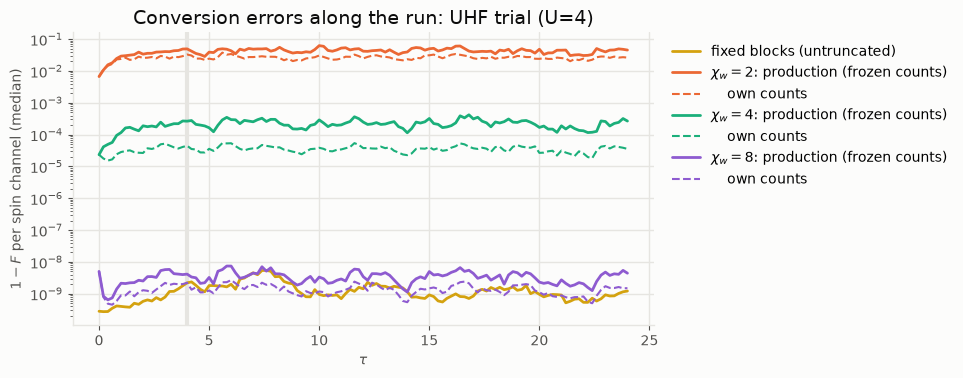

saved fw_block_data/L32_U4_nw200_eps1e-10_s1234_sources_tau_dmrg.png


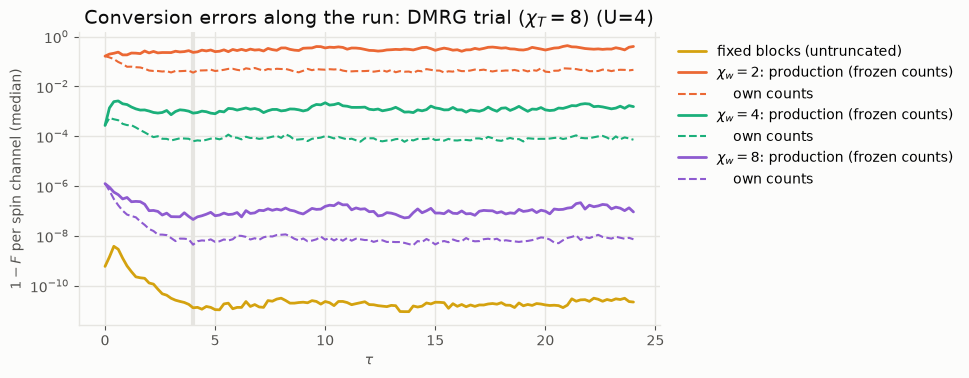

In [121]:
TRIAL_LS = {"uhf": "-", "dmrg": "--"}
SOURCE_COLOR = {"blocks": PALETTE[4], "truncation": PALETTE[0], "counts": PALETTE[1], "optimum": INK2}
SOURCE_LABEL = {"blocks": "fixed blocks", "truncation": "bond truncation (own counts)",
                "counts": "fixed particle counts (production − own)"}
FLOOR = 1e-16                                            # below roundoff, for log axes


def sources_of(key, chi):
    # per walker channel, (n_snap, nw, 2): the three sources, production's total truncation error and the optimum
    e, k = ERR[key][chi], CHI_W.index(chi)
    return dict(blocks=np.clip(1 - SETS[key]["F_fixed"], 0, None), truncation=np.clip(e["own"], 0, None),
                counts=e["prod"] - e["own"], production=np.clip(e["prod"], 0, None),
                optimum=np.clip(OPT[key]["a"][..., k], 0, None))


def median_tau(x):
    return np.median(np.maximum(x, FLOOR).reshape(x.shape[0], -1), axis=1)


for key, st in SETS.items():
    fig, ax = plt.subplots(figsize=(7.5, 3.8))
    ax.plot(st["tau"], median_tau(np.clip(1 - st["F_fixed"], 0, None)), color=SOURCE_COLOR["blocks"],
            label="fixed blocks (untruncated)")
    for chi in CHI_W:
        src = sources_of(key, chi)
        ax.plot(st["tau"], median_tau(src["production"]), color=CHI_COLOR[chi], label=f"{chi_label(chi)}: production (frozen counts)")
        ax.plot(st["tau"], median_tau(src["truncation"]), color=CHI_COLOR[chi], ls="--", lw=1.5, label="    own counts")
    ax.axvline(st["tau"][N_EQL], color=GRID, lw=3, zorder=0)
    ax.set_yscale("log")
    ax.set_xlabel(r"$\tau$"); ax.set_ylabel(r"$1-F$ per spin channel (median)")
    ax.set_title(f"Conversion errors along the run: {st['label']}")
    ax.legend(**LEGEND)
    save(fig, f"sources_tau_{key}"); plt.show()

The cost of the frozen counts as a factor, for both trials in one plot: production's infidelity over the own-counts infidelity, per walker channel, median against $\tau$. Walker channels whose own-counts error is at roundoff ($<10^{-13}$) are left out, since the ratio means nothing there.

saved fw_block_data/L32_U4_nw200_eps1e-10_s1234_counts_factor_tau.png


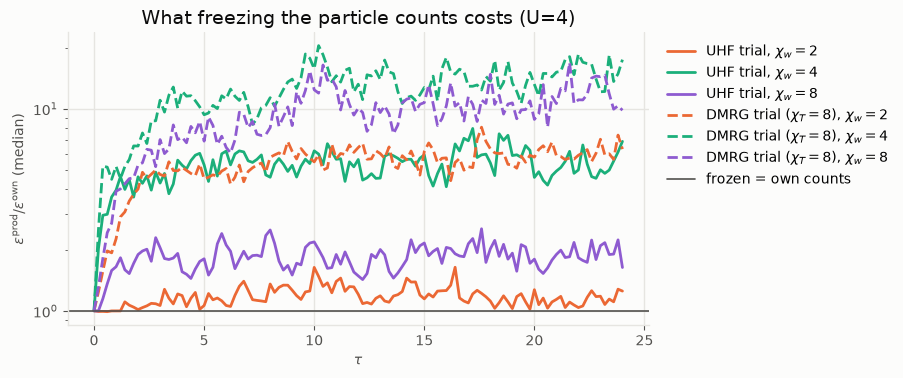

sampling phase, production / own counts per walker channel:   median   90%     99%
  uhf   chi_w = 2                                                 1.2      5.8     28.6
  uhf   chi_w = 4                                                 5.4     34.6    250.4
  uhf   chi_w = 8                                                 1.8     11.5    116.4
  dmrg  chi_w = 2                                                 5.7     28.8    103.7
  dmrg  chi_w = 4                                                13.4    171.9   1889.5
  dmrg  chi_w = 8                                                 9.9    287.6  17009.7


In [122]:
fig, ax = plt.subplots(figsize=(7.5, 3.8))
for key, st in SETS.items():
    for chi in CHI_W:
        e = ERR[key][chi]
        ratio = np.where(e["own"] > 1e-13, np.maximum(e["prod"], FLOOR) / np.maximum(e["own"], FLOOR), np.nan)
        ax.plot(st["tau"], np.nanmedian(ratio.reshape(len(st["tau"]), -1), axis=1), color=CHI_COLOR[chi],
                ls=TRIAL_LS[key], label=f"{st['label']}, {chi_label(chi)}")
ax.axhline(1.0, color=INK2, lw=1.2, label="frozen = own counts")
ax.set_yscale("log")
ax.set_xlabel(r"$\tau$"); ax.set_ylabel(r"$\varepsilon^{\rm prod}/\varepsilon^{\rm own}$ (median)")
ax.set_title("What freezing the particle counts costs")
ax.legend(**LEGEND)
save(fig, "counts_factor_tau"); plt.show()

print("sampling phase, production / own counts per walker channel:   median   90%     99%")
for key, st in SETS.items():
    for chi in CHI_W:
        e = ERR[key][chi]
        own, prod = e["own"][st["samp"]].ravel(), e["prod"][st["samp"]].ravel()
        ok = own > 1e-13
        if not ok.any():
            print(f"  {key:5s} chi_w = {chi}      own counts at roundoff in every walker channel: no ratio")
            continue
        r = np.maximum(prod[ok], FLOOR) / own[ok]
        print(f"  {key:5s} chi_w = {chi}                                             {np.median(r):7.1f}  "
              f"{np.percentile(r, 90):7.1f}  {np.percentile(r, 99):7.1f}")

The whole distribution rather than the median, at $\chi_w=4$: for each source, the fraction of sampling-phase walker channels whose error exceeds $x$. The source colours are the same for both trials; the line style tells the trials apart. Where production happens to beat the walker's own counts (the per-gate greedy allocation isn't globally optimal), the difference is negative and sits at the left edge.

saved fw_block_data/L32_U4_nw200_eps1e-10_s1234_sources_ccdf_chi4.png


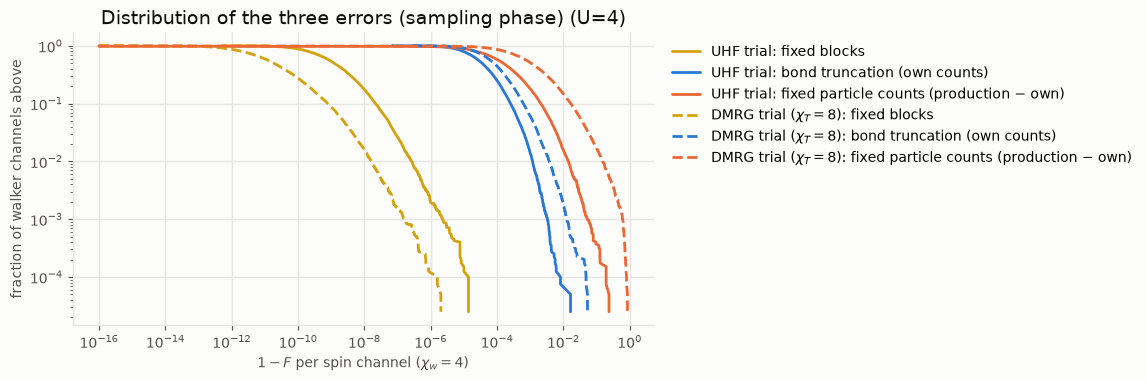

In [123]:
CHI_SHOW = 4
fig, ax = plt.subplots(figsize=(7.5, 3.8))
for key, st in SETS.items():
    src = sources_of(key, CHI_SHOW)
    for name in ("blocks", "truncation", "counts"):
        x = np.sort(np.maximum(src[name][st["samp"]].ravel(), FLOOR))
        ax.plot(x, 1 - np.arange(x.size) / x.size, color=SOURCE_COLOR[name], ls=TRIAL_LS[key],
                label=f"{st['label']}: {SOURCE_LABEL[name]}")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(rf"$1-F$ per spin channel ($\chi_w={CHI_SHOW}$)"); ax.set_ylabel("fraction of walker channels above")
ax.set_title("Distribution of the three errors (sampling phase)")
ax.legend(**LEGEND)
save(fig, f"sources_ccdf_chi{CHI_SHOW}"); plt.show()

### Why: where the walkers keep their states

At the centre cut, the kept states per charge sector (spin ↑ electrons left of the cut), at $\chi_w=4$. For each trial, compare the allocation `plan_bonds` freezes on the reference with the walkers' own optimal allocation (the sectors of their 4 largest Schmidt values), averaged over sampling-phase walkers. The printout gives, per $\chi_w$, the fraction of walker channels with at least one cut where the frozen allocation keeps no state in the walker's dominant sector.

## Comparison: all three sources, both trials

Sampling phase, one number per source, trial and $\chi_w$. The first table is the infidelity per spin channel, which adds up: production's total is the frozen-counts line plus the truncation line, and the fixed blocks come on top. The second table is the overlap error per walker, which is what enters the CPMC ratios:

- **fixed blocks:** against the wider reference plan (previous section), on a subsample of snapshots;
- **own counts** and **production:** $|O^{\chi_w}/O^{\rm full}-1|$ against the untruncated fixed-plan gMPS.

sampling phase, 1-F per spin channel: median (99th percentile)
trial  chi_w         fixed blocks      bond truncation         fixed counts     production total              optimum       prod/own
uhf        2    1.2e-09 (2.6e-07)    2.7e-02 (2.0e-01)    4.8e-03 (6.3e-01)    4.4e-02 (6.9e-01)    8.0e-03 (7.2e-02)            1.6
uhf        4    1.2e-09 (2.6e-07)    3.5e-05 (1.2e-03)    1.5e-04 (1.4e-02)    2.2e-04 (1.5e-02)    1.3e-05 (5.6e-04)            6.2
uhf        8    1.2e-09 (2.6e-07)    1.3e-09 (2.9e-07)    1.1e-09 (2.4e-06)    3.3e-09 (2.5e-06)    6.4e-10 (1.6e-07)            2.5

dmrg       2    1.9e-11 (1.6e-08)    4.4e-02 (3.5e-01)    2.4e-01 (9.7e-01)    3.2e-01 (1.0e+00)    1.1e-02 (1.0e-01)            7.2
dmrg       4    1.9e-11 (1.6e-08)    8.0e-05 (3.7e-03)    1.1e-03 (1.5e-01)    1.3e-03 (1.5e-01)    2.5e-05 (1.4e-03)           15.9
dmrg       8    1.9e-11 (1.6e-08)    7.1e-09 (2.2e-06)    7.9e-08 (2.7e-04)    1.0e-07 (2.7e-04)    2.2e-09 (8.7e-07)           14.5

samp

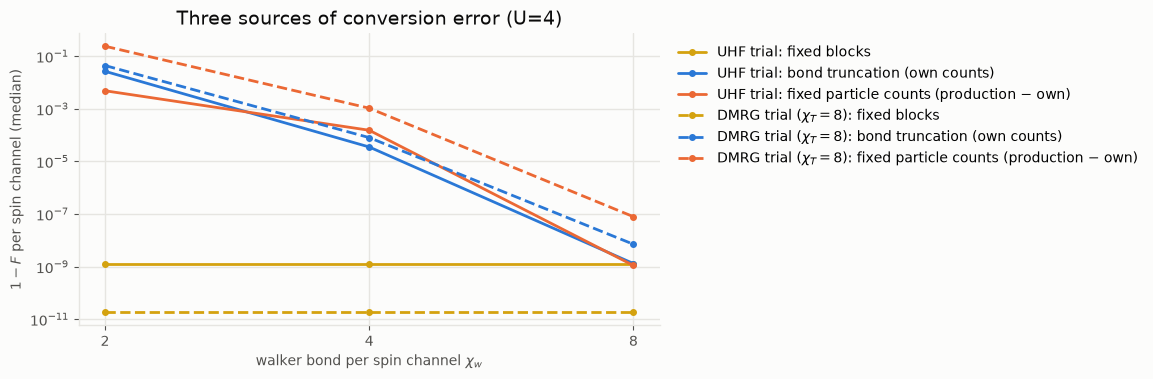

saved fw_block_data/L32_U4_nw200_eps1e-10_s1234_sources_compare_overlap.png


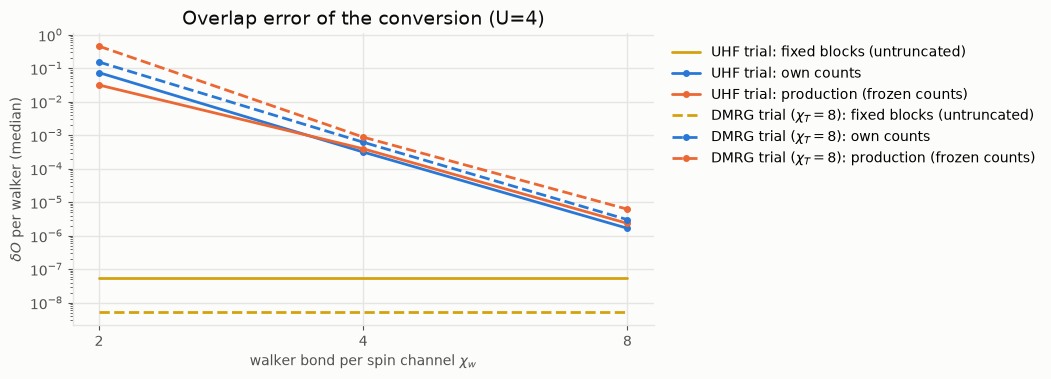

In [124]:
q = lambda x, sm: f"{np.median(x[sm]):8.1e} ({np.percentile(x[sm], 99):7.1e})"
print("sampling phase, 1-F per spin channel: median (99th percentile)")
print(f"{'trial':6s} {'chi_w':>5s}   {'fixed blocks':>18s}   {'bond truncation':>18s}   {'fixed counts':>18s}   "
      f"{'production total':>18s}   {'optimum':>18s}   {'prod/own':>12s}")
for key, st in SETS.items():
    for chi in CHI_W:
        src, sm = sources_of(key, chi), st["samp"]
        ratio = np.median(src["production"][sm]) / max(np.median(src["truncation"][sm]), FLOOR)
        print(f"{key:6s} {chi:5d}   {q(src['blocks'], sm)}   {q(src['truncation'], sm)}   {q(src['counts'], sm)}   "
              f"{q(src['production'], sm)}   {q(src['optimum'], sm)}   {ratio:12.1f}")
    print()

print("sampling phase, delta O per walker: median (99th percentile)")
print(f"{'trial':6s} {'chi_w':>5s}   {'fixed blocks':>18s}   {'own counts':>18s}   {'production':>18s}   {'prod/own':>8s}")
for key, st in SETS.items():
    sm, dO_blocks = st["samp"], WIDE[key]["dO"]
    blk = f"{np.median(dO_blocks):8.1e} ({np.percentile(dO_blocks, 99):7.1e})"
    for chi in CHI_W:
        e = ERR[key][chi]
        own, prod = np.abs(e["r_own"] - 1), np.abs(e["r_prod"] - 1)
        print(f"{key:6s} {chi:5d}   {blk}   {q(own, sm)}   {q(prod, sm)}   {np.median(prod[sm]) / max(np.median(own[sm]), FLOOR):8.1f}")
    print()
print("fixed blocks: against the wider plan, every WIDE_EVERY-th sampling snapshot (UHF, exact: "
      f"{np.median(TR[0]['dO'][SETS['uhf']['samp']]):.1e} median)")

x = np.array(CHI_W)
fig, ax = plt.subplots(figsize=(7.5, 3.8))
for key, st in SETS.items():
    sm = st["samp"]
    for name in ("blocks", "truncation", "counts"):
        y = [np.median(np.maximum(sources_of(key, chi)[name][sm], FLOOR)) for chi in CHI_W]
        ax.plot(x, y, ls=TRIAL_LS[key], marker="o", ms=4, color=SOURCE_COLOR[name], label=f"{st['label']}: {SOURCE_LABEL[name]}")
ax.set_xscale("log", base=2); ax.set_yscale("log"); ax.set_xticks(x, [str(c) for c in CHI_W])
ax.set_xlabel(r"walker bond per spin channel $\chi_w$"); ax.set_ylabel(r"$1-F$ per spin channel (median)")
ax.set_title("Three sources of conversion error")
ax.legend(**LEGEND)
save(fig, "sources_compare"); plt.show()

fig, ax = plt.subplots(figsize=(7.5, 3.8))
for key, st in SETS.items():
    sm = st["samp"]
    ax.plot(x, [np.median(WIDE[key]["dO"])] * len(x), ls=TRIAL_LS[key], color=SOURCE_COLOR["blocks"],
            label=f"{st['label']}: fixed blocks (untruncated)")
    for name, rkey in (("truncation", "r_own"), ("counts", "r_prod")):
        y = [np.median(np.maximum(np.abs(ERR[key][chi][rkey][sm] - 1), FLOOR)) for chi in CHI_W]
        ax.plot(x, y, ls=TRIAL_LS[key], marker="o", ms=4, color=SOURCE_COLOR[name],
                label=f"{st['label']}: " + ("own counts" if rkey == "r_own" else "production (frozen counts)"))
ax.set_xscale("log", base=2); ax.set_yscale("log"); ax.set_xticks(x, [str(c) for c in CHI_W])
ax.set_xlabel(r"walker bond per spin channel $\chi_w$"); ax.set_ylabel(r"$\delta O$ per walker (median)")
ax.set_title("Overlap error of the conversion")
ax.legend(**LEGEND)
save(fig, "sources_compare_overlap"); plt.show()

## Summary

### Fixed blocks, UHF trial

At L=32, U=4, $\varepsilon=10^{-10}$, 200 walkers, 120 blocks (τ = 24), one seed:

- **Walkers do outgrow the plan, but only by one site.** The fixed plan uses $B=5$ in the bulk. Over the sampling phase, 66% of (walker, spin, site) block sizes equal the plan's and 27% are smaller (harmless). 6.5% are one site larger and 0.03% two sites larger. The median walker's largest block is 6, and the largest seen anywhere is 7.
- **The excess appears within τ≈1**, as soon as the walkers leave the reference, and then stays statistically flat. There is no drift with τ: the plots show a stationary distribution, not growth.
- **The norm it costs is tiny.** $1-F$ for the fixed plan has a median of $2\times10^{-9}$ against a floor of $1.5\times10^{-9}$ for the walkers' own plans, a 99th percentile of $5\times10^{-7}$ and a worst case of $3\times10^{-5}$ in 20,000 walker snapshots. It grows with the summed excess block size, so the loss really comes from blocks that are too small.
- **Bond truncation costs far more than the fixed blocks, at every $\chi_w$ tested.** For the walker–trial overlap error $\delta O$ over the sampling phase:

  | $\chi_w$ (d=4 bond $\chi_w^2$) | median | 99th percentile | worst |
  |---|---|---|---|
  | no truncation (fixed blocks only) | $8\times10^{-8}$ | $6\times10^{-6}$ | $3\times10^{-4}$ |
  | 8 (64) | $2\times10^{-6}$ | $2\times10^{-4}$ | $4\times10^{-3}$ |
  | 4 (16) | $4\times10^{-4}$ | $4\times10^{-2}$ | $0.26$ |
  | 2 (4) | $3\times10^{-2}$ | $0.38$ | $0.97$ |

  Even at $\chi_w=8$ the truncation error is about 30× the block error, at the median and at the 99th percentile. The plan's full bond here is 16, so $\chi_w\ge16$ is truncation-free, and only then do the fixed blocks set the error.
- **The fixed-block overlap error ($\sim10^{-7}$) is much larger than its norm loss ($\sim10^{-9}$) suggests.** $\delta O$ is relative to the walker's overlap with the trial, and a small $O$ amplifies it: the missing $\sqrt{1-F}\sim10^{-4.5}$ amplitude need not be orthogonal to the trial. The truncated $\delta O$ tracks $1-F^{\rm bond}$ more closely, because the truncation removes whole Schmidt components.
- **So the fixed-block approximation is not what limits the MPS-CPMC walkers.** Walker bond truncation is. An own-plan conversion would need a bond of $2^{6-1}=32$ instead of $16$ for most walkers, to remove an error that is already below the truncation error of any affordable $\chi_w$.

### Three sources, two trials

Sampling phase, per spin channel, medians unless stated. The UHF numbers are from the 200-walker run. **The DMRG numbers are preliminary**: they come from a 16-walker validation run of the same cells and should be updated after the 200-walker run.

| $\chi_w$ | trial | fixed blocks | bond truncation (own counts) | fixed particle counts | optimum | production / own |
|---|---|---|---|---|---|---|
| 2 | UHF | $1.2\times10^{-9}$ | $2.7\times10^{-2}$ | $4.8\times10^{-3}$ | $8.0\times10^{-3}$ | 1.6 |
| 4 | UHF | | $3.5\times10^{-5}$ | $1.5\times10^{-4}$ | $1.3\times10^{-5}$ | 6.2 |
| 8 | UHF | | $1.3\times10^{-9}$ | $1.1\times10^{-9}$ | $6.4\times10^{-10}$ | 2.5 |
| 2 | DMRG | $4.3\times10^{-11}$ | $4.7\times10^{-2}$ | $0.27$ | $1.2\times10^{-2}$ | 7.5 |
| 4 | DMRG | | $1.0\times10^{-4}$ | $1.6\times10^{-3}$ | $3.2\times10^{-5}$ | 18 |
| 8 | DMRG | | $1.2\times10^{-8}$ | $1.6\times10^{-7}$ | $3.7\times10^{-9}$ | 16 |

- **L=32 confirms `entanglement_vs_gmps.ipynb`: the frozen particle counts cost far more than the fixed blocks.** For the DMRG trial this holds at every $\chi_w$; at $\chi_w=8$ it is $1.6\times10^{-7}$ against $4\times10^{-11}$. For the UHF trial it holds at $\chi_w\le4$. At $\chi_w=8$ the UHF trial's three sources are all about $10^{-9}$.
- **The DMRG trial's natural-orbital reference is the bad case.** Freezing its counts makes the truncation 7.5–18× worse than the walker's own counts would, against 1.6–6× for the UHF reference. In the tails, the per-walker ratio reaches $2\times10^3$ (DMRG, $\chi_w=4$, 99th percentile) against $250$ (UHF). At $\chi_w=2$, 25% of DMRG walker channels have a cut where the frozen allocation keeps no state in their dominant sector; for the UHF trial it is 2%.
- **The own counts are close to the optimum**, 2–4× above it, as at $L\le12$. So the truncation proper is near what any MPS with that bond could do, and the frozen allocation accounts for most of production's excess. The own counts are greedy gate by gate, so production occasionally does better: in 38% of UHF walker channels at $\chi_w=2$, and in 0.3–4% elsewhere.
- **The overlap error the CPMC sees suffers much less.** For $\delta O$ per walker, production over own counts is 1.3–1.4 (UHF, $\chi_w\ge4$) and 1.7–2.8 (DMRG). For the UHF trial at $\chi_w=2$, production is even better (0.4×). A likely reason, not tested here: the UHF counts are frozen on the trial determinant itself, so they keep the sectors that carry the trial overlap, while the walker's own counts keep its largest Schmidt weight regardless of the trial.
- **The fixed blocks never matter for $\delta O$.** It is $\le10^{-7}$ at the median for both trials: $7.7\times10^{-8}$ exact for UHF, and about $10^{-8}$ for DMRG, measured against the wider plan (a resolution-limited value). Every truncation error at $\chi_w\le8$ is at least $2\times10^{-6}$.

Caveats:

- One seed, one $U$ and one $\varepsilon$.
- The DMRG-trial walkers come from production's MPS-CPMC at $\chi_w=$ `CHI_PROP` $=8$, so their importance sampling includes that conversion's own error.
- The fixed-block $\delta O$ of the DMRG trial is measured against a wider plan, which is itself accurate only to about $2\times10^{-8}$ in $\delta O$ (checked on the UHF walkers). Its median is therefore an estimate; its 99th percentile ($9\times10^{-7}$) is not affected.
- The CPMC energies are sanity checks of the runs, not results. The UHF trial gives $-17.62\pm0.05$, against the DMRG reference $\approx-18.00$ from earlier runs; that is the constraint bias of a strongly symmetry-broken trial. The 16-walker DMRG-trial run gives $-17.975\pm0.009$.

# U = 8

Everything above, again at $U$ = `U2` (config cell), with all other settings unchanged: the UHF-trial run, the fixed-plan analysis and its plots, the truncation, the DMRG-trial run and the three-source comparison. The code cells are copies of the ones above; for what each one does, see its section there. Every stage is cached under names that carry $U$, and every plot title ends in its $U$.

**Cost.** The two CPMC runs are the slow steps, as at $U=4$. The rest takes about 15 minutes, mostly compilation.

In [125]:
# switch the interaction; every cell below is a copy of the one above it in the U = 4 part
U = U2
RUN_TAG, TAG, WALKERS, DATA = data_names(U)
print(f"U = {U:g}: runs tagged {RUN_TAG}, analyses tagged {TAG}")

U = 8: runs tagged L32_U8_nw200_s1234, analyses tagged L32_U8_nw200_eps1e-10_s1234


## UHF trial (U = 8)

In [126]:
h1 = hopping_matrix(L, T)


def uhf_scf(h1, u, na, nb, guess=0.3, mix=0.5, tol=1e-12, iters=5000):
    n = h1.shape[0]
    stag = (-1.0) ** np.arange(n)
    da, db = na / n + guess * stag, nb / n - guess * stag
    for it in range(iters):
        _, va = np.linalg.eigh(h1 + u * np.diag(db))
        _, vb = np.linalg.eigh(h1 + u * np.diag(da))
        Ca, Cb = va[:, :na], vb[:, :nb]
        new_a, new_b = np.einsum("ik,ik->i", Ca, Ca), np.einsum("ik,ik->i", Cb, Cb)
        change = max(abs(new_a - da).max(), abs(new_b - db).max())
        da, db = (1 - mix) * da + mix * new_a, (1 - mix) * db + mix * new_b
        if change < tol:
            break
    Pa, Pb = Ca @ Ca.T, Cb @ Cb.T
    energy = np.sum(h1 * (Pa + Pb)) + u * np.diag(Pa) @ np.diag(Pb)
    return Ca, Cb, energy, it, change


Ca, Cb, E_UHF, it, change = uhf_scf(h1, U, N_UP, N_DN)
m = np.einsum("ik,ik->i", Ca, Ca) - np.einsum("ik,ik->i", Cb, Cb)
print(f"UHF: E = {E_UHF:.10f}  ({it} iterations, last density change {change:.1e})")
print(f"staggered moment (n_up - n_dn), first sites: {np.round(m[:6], 3)}")

UHF: E = -7.6327744952  (45 iterations, last density change 6.4e-13)
staggered moment (n_up - n_dn), first sites: [ 0.969 -0.938  0.939 -0.939  0.939 -0.939]


## The UHF trial in trot (U = 8)

In [127]:
ham = HamHubbard(h1=jnp.asarray(h1), u=U)                     # propagation
onsite = np.zeros((L, L, L))
onsite[np.arange(L), np.arange(L), np.arange(L)] = np.sqrt(U)
ham_meas = HamChol(h0=jnp.zeros(()), h1=jnp.asarray(h1), chol=jnp.asarray(onsite))   # U n_up n_dn as L Cholesky vectors

system = System(norb=L, nelec=(N_UP, N_DN), walker_kind="unrestricted")
trial = UhfTrial(mo_coeff_a=jnp.asarray(Ca), mo_coeff_b=jnp.asarray(Cb))
TRIAL_OPS = make_uhf_trial_ops(system)
MEAS_OPS = make_uhf_meas_ops(system)
PROP_OPS = cpmc_slow.make_prop_ops(ham, "unrestricted")
params = QmcParams(dt=DT, n_walkers=N_WALKERS, n_prop_steps=N_PROP, n_blocks=N_BLOCKS,
                   n_eql_blocks=N_EQL, seed=SEED)


def setup(prop_ops, trial_ops, meas_ops, trial_data, ham_data, params):
    run_blocks = make_run_blocks(block_fn=blocks.block, sys=system, params=params,
                                 trial_ops=trial_ops, meas_ops=meas_ops, prop_ops=prop_ops)
    ctx = dict(ham_data=ham_data, trial_data=trial_data,
               meas_ctx=meas_ops.build_meas_ctx(ham_data, trial_data),
               prop_ctx=prop_ops.build_prop_ctx(ham, trial_ops.get_rdm1(trial_data), params))
    state = prop_ops.init_prop_state(sys=system, ham_data=ham_data, trial_ops=trial_ops,
                                     trial_data=trial_data, meas_ops=meas_ops, params=params)
    return run_blocks, ctx, state


small = dataclasses.replace(params, n_walkers=16)
ghf_trial = GhfTrial(mo_coeff=jnp.asarray(scipy.linalg.block_diag(Ca, Cb)))
ghf_ops = make_ghf_trial_ops(system)
out = {}
for name, args in [("UHF, slow step", (PROP_OPS, TRIAL_OPS, MEAS_OPS, trial, ham_meas)),
                   ("GHF, fast step", (cpmc.make_prop_ops(ham, "unrestricted", ghf_ops), ghf_ops,
                                       make_ghf_meas_ops_hubbard(system), ghf_trial, ham))]:
    run_blocks, ctx, state = setup(*args, small)
    out[name] = run_blocks(state, **ctx, n_blocks=2)[:2]
    print(f"block energies, {name}: {np.asarray(out[name][1]['energy'])}")
(s1, _), (s2, _) = out.values()
print("max |walker difference|:", max(float(jnp.abs(a - b).max()) for a, b in zip(s1.walkers, s2.walkers)))

block energies, UHF, slow step: [-7.86906871 -7.92709707]
block energies, GHF, fast step: [-7.86906871 -7.92709707]
max |walker difference|: 0.0


## The fixed plan (U = 8)

In [128]:
PLAN = [make_orbital_plan(C, "adaptive", EPS) for C in (Ca, Cb)]
B_REF = np.stack([p.block_sizes for p in PLAN])           # (2, L-1)
for s, p in zip("↑↓", PLAN):
    print(f"spin {s}: B_k = {p.block_sizes.tolist()}")
    print(f"        gates = {int((p.block_sizes - 1).sum())},  max B = {p.block_sizes.max()}  ->  "
          f"bond up to 2^(B-1) = {2 ** (p.block_sizes.max() - 1)} before truncation")

spin ↑: B_k = [4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 3, 3, 2, 2]
        gates = 87,  max B = 4  ->  bond up to 2^(B-1) = 8 before truncation
spin ↓: B_k = [4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 3, 3, 2, 2]
        gates = 87,  max B = 4  ->  bond up to 2^(B-1) = 8 before truncation


## Converting every walker, every block (U = 8)

In [129]:
def fidelity(Q, plan):
    _, rows = channel_angles(Q, plan, xp=np)
    return np.linalg.det(np.stack([rows[i] for i in np.flatnonzero(plan.occupation)])) ** 2


def analyse(walkers, plans=PLAN):
    nw = walkers[0].shape[0]
    B = np.zeros((nw, 2, L - 1), np.int8)
    F_fixed, F_own = np.zeros((nw, 2)), np.zeros((nw, 2))
    for s in range(2):
        W = np.asarray(walkers[s])
        for w in range(nw):
            Q, _ = np.linalg.qr(W[w])
            own = make_orbital_plan(Q, "adaptive", EPS)
            B[w, s] = own.block_sizes
            F_own[w, s] = fidelity(Q, own)
            F_fixed[w, s] = fidelity(Q, plans[s])
    return B, F_fixed, F_own

## The run (U = 8)

In [130]:
if RERUN or not WALKERS.exists():
    run_blocks, ctx, state = setup(PROP_OPS, TRIAL_OPS, MEAS_OPS, trial, ham_meas, params)
    n_total = N_EQL + N_BLOCKS
    snaps_up, snaps_dn, energies, weights = [], [], [], []
    start = time.perf_counter()
    for b in range(n_total + 1):
        if b:
            state, scalars, _ = run_blocks(state, **ctx, n_blocks=1)
            energies.append(float(scalars["energy"][0]))
            weights.append(float(scalars["weight"][0]))
        snaps_up.append(np.asarray(state.walkers[0]))
        snaps_dn.append(np.asarray(state.walkers[1]))
        if b % 20 == 0:
            print(f"block {b:4d}/{n_total}  E {energies[-1] if b else float(state.e_estimate):12.6f}"
                  f"  t {time.perf_counter() - start:6.1f} s", flush=True)
    config = dict(L=L, N_UP=N_UP, N_DN=N_DN, T=T, U=U, N_WALKERS=N_WALKERS, N_EQL=N_EQL,
                  N_BLOCKS=N_BLOCKS, N_PROP=N_PROP, DT=DT, SEED=SEED, E_UHF=E_UHF)
    np.savez_compressed(WALKERS, up=np.stack(snaps_up), dn=np.stack(snaps_dn), energies=np.array(energies),
                        weights=np.array(weights), config=json.dumps(config))
    print(f"saved {WALKERS}")

run = np.load(WALKERS)
WALK = (run["up"], run["dn"])                # each (n_snap, n_walkers, L, N_sigma)
energies, weights = run["energies"], run["weights"]
tau = np.arange(WALK[0].shape[0]) * N_PROP * DT   # snapshot b at tau = b * N_PROP * DT
samp = slice(N_EQL + 1, None)                     # snapshots after the equilibration blocks
print(f"{len(tau)} snapshots x {WALK[0].shape[1]} walkers, tau up to {tau[-1]:g}")

block    0/120  E    -7.632774  t    0.0 s
block   20/120  E    -9.716181  t   17.3 s
block   40/120  E    -8.969363  t   33.9 s
block   60/120  E    -8.547581  t   50.2 s
block   80/120  E    -8.896722  t   66.2 s
block  100/120  E    -8.489801  t   82.2 s
block  120/120  E    -9.336856  t   98.3 s
saved fw_block_data/L32_U8_nw200_s1234_walkers.npz
121 snapshots x 200 walkers, tau up to 24


In [131]:
if RERUN or not DATA.exists():
    start, out = time.perf_counter(), [analyse((up, dn)) for up, dn in zip(*WALK)]
    np.savez_compressed(DATA, block_sizes=np.stack([o[0] for o in out]), fid_fixed=np.stack([o[1] for o in out]),
                        fid_own=np.stack([o[2] for o in out]), plan_block_sizes=B_REF)
    print(f"analysed {len(out)} snapshots in {time.perf_counter() - start:.0f} s; saved {DATA}")

data = np.load(DATA)
BS = data["block_sizes"].astype(int)        # (n_snap, n_walkers, 2, L-1)
FF = data["fid_fixed"]                       # (n_snap, n_walkers, 2)
FO = data["fid_own"]
print(f"{BS.shape[0]} snapshots x {BS.shape[1]} walkers x 2 spins x {BS.shape[3]} sites")

analysed 121 snapshots in 120 s; saved fw_block_data/L32_U8_nw200_eps1e-10_s1234.npz
121 snapshots x 200 walkers x 2 spins x 31 sites


### Checks: explicit gMPS, and the energy (U = 8)

In [132]:
def mps_dot(A, B):
    E = np.ones((1, 1))
    for a, b in zip(A, B):
        E = np.einsum("ab,apc,bpd->cd", E, np.asarray(a), np.asarray(b))
    return E[0, 0]


final = (WALK[0][-1], WALK[1][-1])
trial_mps = [channel_mps(jnp.asarray(C), p) for C, p in zip((Ca, Cb), PLAN)]
worst = np.argsort(FF[-1].prod(1))[:2]                  # the two walkers the fixed plan fits worst
print(" walker spin   det(Psi^T Q)      own-plan rel.err   fixed-plan rel.err   1-F_fixed   bond (own/fixed)")
for w in [0, *worst]:
    for s in range(2):
        Q, _ = np.linalg.qr(final[s][w])
        exact = np.linalg.det(np.asarray((Ca, Cb)[s]).T @ Q)
        tT, _, gT = trial_mps[s]
        row = []
        for plan in (make_orbital_plan(Q, "adaptive", EPS), PLAN[s]):
            tW, _, gW = channel_mps(jnp.asarray(Q), plan)
            row.append((float(gT * gW) * mps_dot(tT, tW), max(a.shape[0] for a in tW)))
        print(f"  {w:4d}   {'↑↓'[s]}   {exact:+.6e}      {abs(row[0][0] / exact - 1):.1e}"
              f"            {abs(row[1][0] / exact - 1):.1e}           {1 - FF[-1, w, s]:.1e}     "
              f"{row[0][1]}/{row[1][1]}")

a, b = final[0][0], final[1][0]
P_up, P_dn = (x @ np.linalg.solve(x.T @ x, x.T) for x in (a, b))
stag = np.diag((-1.0) ** np.arange(L))
print(f"\nparticle-hole symmetry: max |P_dn - (1 - S P_up S)| = {np.abs(P_dn - (np.eye(L) - stag @ P_up @ stag)).max():.1e}, "
      f"max |F_up - F_dn| over the run = {np.abs(FF[..., 0] - FF[..., 1]).max():.1e}, "
      f"B_up != B_dn in {(BS[:, :, 0] != BS[:, :, 1]).sum()} of {BS[:, :, 0].size} (snapshot, walker, site) entries")

stats = blocking_analysis_ratio(energies[N_EQL:], weights[N_EQL:], print_q=False)
E_MEAN = float(stats["mu"])
E_ERR = float("nan") if stats["se_star"] is None else float(stats["se_star"])   # None: too few blocks for a plateau
print(f"\nCPMC energy (UHF trial): {E_MEAN:.6f} +- {E_ERR:.6f}   UHF: {E_UHF:.6f}")

 walker spin   det(Psi^T Q)      own-plan rel.err   fixed-plan rel.err   1-F_fixed   bond (own/fixed)
     0   ↑   -2.329845e-01      2.0e-09            2.5e-09           1.8e-09     16/8
     0   ↓   +2.329845e-01      2.0e-09            2.5e-09           1.8e-09     16/8
    16   ↑   -8.718241e-01      1.1e-10            2.5e-07           3.8e-08     16/8
    16   ↓   -8.718241e-01      1.1e-10            2.5e-07           3.8e-08     16/8
    23   ↑   +1.801016e-01      2.7e-09            2.8e-08           3.7e-08     8/8
    23   ↓   +1.801016e-01      2.7e-09            2.8e-08           3.7e-08     8/8

particle-hole symmetry: max |P_dn - (1 - S P_up S)| = 2.2e-15, max |F_up - F_dn| over the run = 1.3e-14, B_up != B_dn in 0 of 750200 (snapshot, walker, site) entries

CPMC energy (UHF trial): -9.147543 +- 0.051595   UHF: -7.632774


## Block sizes along the run (U = 8)

saved fw_block_data/L32_U8_nw200_eps1e-10_s1234_max_block.png


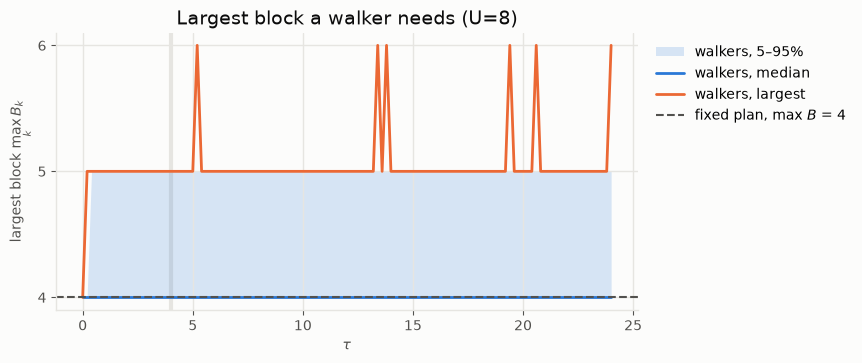

In [133]:
bmax = BS.max(axis=3).reshape(len(tau), -1)             # per walker-channel
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.fill_between(tau, np.percentile(bmax, 5, axis=1), np.percentile(bmax, 95, axis=1),
                color=PALETTE[0], alpha=0.18, lw=0, label="walkers, 5–95%")
ax.plot(tau, np.median(bmax, axis=1), color=PALETTE[0], label="walkers, median")
ax.plot(tau, bmax.max(axis=1), color=PALETTE[1], label="walkers, largest")
ax.axhline(B_REF.max(), color=INK2, ls="--", lw=1.5, label=f"fixed plan, max $B$ = {B_REF.max()}")
ax.axvline(tau[N_EQL], color=GRID, lw=3, zorder=0)
ax.set_xlabel(r"$\tau$"); ax.set_ylabel(r"largest block $\max_k B_k$")
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.set_title("Largest block a walker needs")
ax.legend(**LEGEND)
save(fig, "max_block"); plt.show()

saved fw_block_data/L32_U8_nw200_eps1e-10_s1234_excess_fraction.png


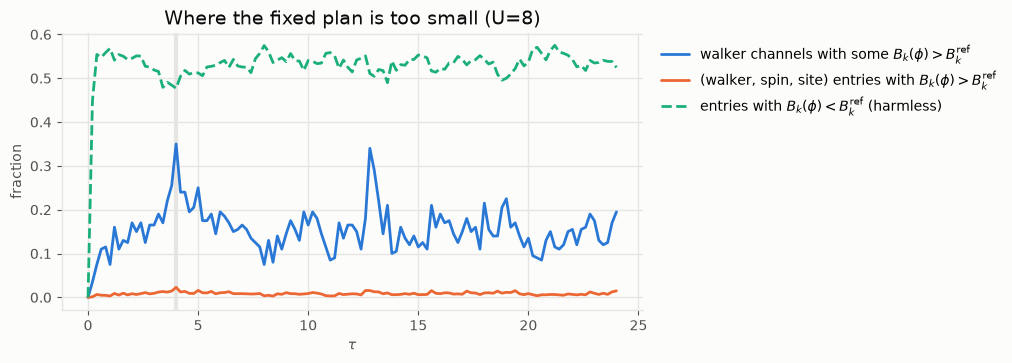

In [134]:
excess = BS - B_REF[None, None]                          # (n_snap, nw, 2, L-1)
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.plot(tau, (excess > 0).any(axis=3).mean(axis=(1, 2)), color=PALETTE[0],
        label=r"walker channels with some $B_k(\phi) > B_k^{\rm ref}$")
ax.plot(tau, (excess > 0).mean(axis=(1, 2, 3)), color=PALETTE[1],
        label=r"(walker, spin, site) entries with $B_k(\phi) > B_k^{\rm ref}$")
ax.plot(tau, (excess < 0).mean(axis=(1, 2, 3)), color=PALETTE[2], ls="--",
        label=r"entries with $B_k(\phi) < B_k^{\rm ref}$ (harmless)")
ax.axvline(tau[N_EQL], color=GRID, lw=3, zorder=0)
ax.set_xlabel(r"$\tau$"); ax.set_ylabel("fraction")
ax.set_title("Where the fixed plan is too small")
ax.legend(**LEGEND)
save(fig, "excess_fraction"); plt.show()

### Per site (U = 8)

saved fw_block_data/L32_U8_nw200_eps1e-10_s1234_site_profile.png


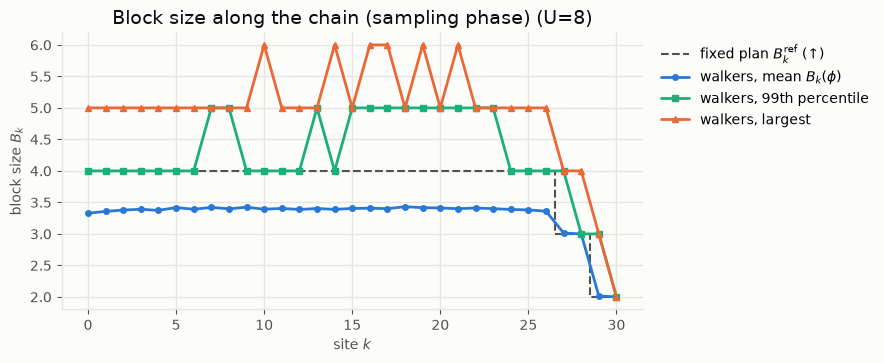

In [135]:
sites = np.arange(L - 1)
Bs = BS[samp].reshape(-1, L - 1)
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.step(sites, B_REF[0], where="mid", color=INK2, ls="--", lw=1.5, label=r"fixed plan $B_k^{\rm ref}$ (↑)")
if not np.array_equal(B_REF[0], B_REF[1]):
    ax.step(sites, B_REF[1], where="mid", color=INK2, ls=":", lw=1.5, label=r"fixed plan $B_k^{\rm ref}$ (↓)")
ax.plot(sites, Bs.mean(0), "o-", color=PALETTE[0], ms=4, label=r"walkers, mean $B_k(\phi)$")
ax.plot(sites, np.percentile(Bs, 99, axis=0), "s-", color=PALETTE[2], ms=4, label=r"walkers, 99th percentile")
ax.plot(sites, Bs.max(0), "^-", color=PALETTE[1], ms=4, label=r"walkers, largest")
ax.set_xlabel("site $k$"); ax.set_ylabel("block size $B_k$")
ax.set_title("Block size along the chain (sampling phase)")
ax.legend(**LEGEND)
save(fig, "site_profile"); plt.show()

## What the fixed plan costs: the fidelity (U = 8)

saved fw_block_data/L32_U8_nw200_eps1e-10_s1234_infidelity.png


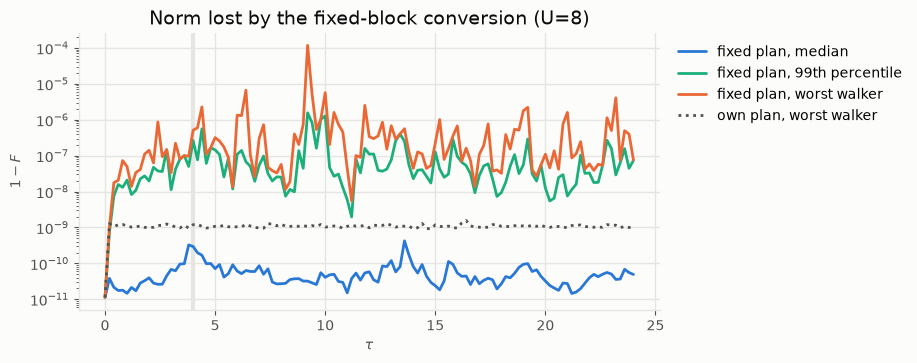

sampling phase, 20000 walker snapshots: 1-F median 4.4e-11, 99% 9.4e-08, 99.9% 1.3e-06, max 1.2e-04
own plan, max 1-F: 1.6e-09


In [136]:
inf_fixed = np.clip(1 - FF.prod(axis=2), 1e-17, None)    # (n_snap, nw)
inf_own = np.clip(1 - FO.prod(axis=2), 1e-17, None)
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.plot(tau, np.median(inf_fixed, axis=1), color=PALETTE[0], label="fixed plan, median")
ax.plot(tau, np.percentile(inf_fixed, 99, axis=1), color=PALETTE[2], label="fixed plan, 99th percentile")
ax.plot(tau, inf_fixed.max(axis=1), color=PALETTE[1], label="fixed plan, worst walker")
ax.plot(tau, inf_own.max(axis=1), color=INK2, ls=":", label="own plan, worst walker")
ax.axvline(tau[N_EQL], color=GRID, lw=3, zorder=0)
ax.set_yscale("log")
ax.set_xlabel(r"$\tau$"); ax.set_ylabel(r"$1-F$")
ax.set_title("Norm lost by the fixed-block conversion")
ax.legend(**LEGEND)
save(fig, "infidelity"); plt.show()

x = inf_fixed[samp].ravel()
print(f"sampling phase, {x.size} walker snapshots: 1-F median {np.median(x):.1e}, "
      f"99% {np.percentile(x, 99):.1e}, 99.9% {np.percentile(x, 99.9):.1e}, max {x.max():.1e}")
print(f"own plan, max 1-F: {inf_own[samp].max():.1e}")

saved fw_block_data/L32_U8_nw200_eps1e-10_s1234_infidelity_vs_excess.png


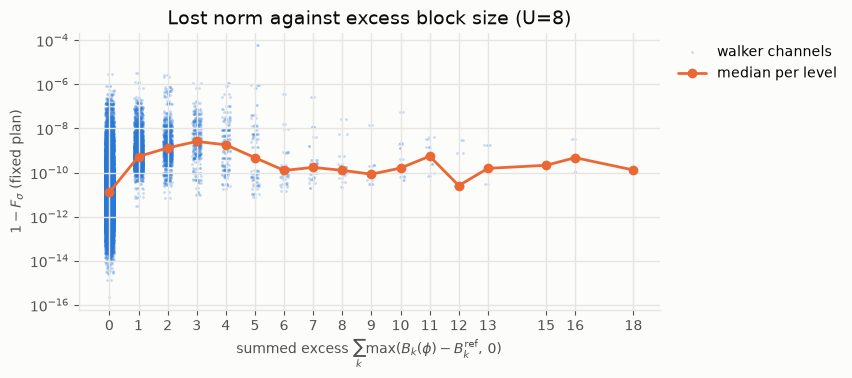

In [137]:
tot = np.clip(excess[samp], 0, None).sum(axis=3).ravel()
inf_ch = np.clip(1 - FF[samp].ravel(), 1e-17, None)
fig, ax = plt.subplots(figsize=(7.5, 3.6))
jitter = np.random.default_rng(0).uniform(-0.15, 0.15, tot.size)
ax.scatter(tot + jitter, inf_ch, s=4, alpha=0.25, color=PALETTE[0], lw=0, label="walker channels")
levels = np.unique(tot)
ax.plot(levels, [np.median(inf_ch[tot == v]) for v in levels], "o-", color=PALETTE[1], label="median per level")
ax.set_yscale("log"); ax.set_xticks(levels)
ax.set_xlabel(r"summed excess $\sum_k\max(B_k(\phi)-B_k^{\rm ref},\,0)$")
ax.set_ylabel(r"$1-F_\sigma$ (fixed plan)")
ax.set_title("Lost norm against excess block size")
ax.legend(**LEGEND)
save(fig, "infidelity_vs_excess"); plt.show()

## Truncating the gMPS (U = 8)

In [138]:
def jdot(A, B):
    E = jnp.ones((1, 1))
    for a, b in zip(A, B):
        E = jnp.einsum("ab,apc,bpd->cd", E, a, b)
    return E[0, 0]


PSI = (jnp.asarray(Ca), jnp.asarray(Cb))
TRIAL_GMPS = [channel_mps(C, p)[::2] for C, p in zip(PSI, PLAN)]      # (tensors, gauge) per spin
BONDS = {0: (None, None)}
for chi in CHI_W:
    BONDS[chi] = tuple(plan_bonds(C, p, chi, 0.0) for C, p in zip((Ca, Cb), PLAN))
    print(f"chi_w = {chi}: bond labels {max(len(q) for q in BONDS[chi][0].charges)}, reference discarded weight "
          f"{BONDS[chi][0].reference_discarded_weight:.1e} (↑)  {BONDS[chi][1].reference_discarded_weight:.1e} (↓)")


def make_truncated(s, bond):
    (tT, gT), plan, psi = TRIAL_GMPS[s], PLAN[s], PSI[s]

    def one(w):
        Q, _ = jnp.linalg.qr(w)
        full, _, g = channel_mps(Q, plan)
        cut = full if bond is None else channel_mps(Q, plan, bond)[0]
        kept = jdot(cut, cut)
        return jdot(full, cut) ** 2 / kept, kept, gT * g * jdot(tT, cut) / jnp.linalg.det(psi.T @ Q)
    return jax.jit(jax.vmap(one))


TR = {}
for chi, bond in BONDS.items():
    path = trunc_file(chi)
    if RERUN or not path.exists():
        start, res = time.perf_counter(), []
        for s in range(2):
            f = make_truncated(s, bond[s])
            res.append([np.asarray(jnp.stack(f(jnp.asarray(w)))) for w in WALK[s]])   # per snapshot (3, nw)
        res = np.asarray(res)                                        # (2, n_snap, 3, nw)
        np.savez_compressed(path, f_bond=res[:, :, 0].transpose(1, 2, 0), kept=res[:, :, 1].transpose(1, 2, 0),
                            ratio=res[:, :, 2].transpose(1, 2, 0))
        print(f"chi_w = {chi or 'none'}: {time.perf_counter() - start:.0f} s, saved {path}")
    TR[chi] = dict(np.load(path))                                    # arrays (n_snap, nw, 2)
    TR[chi]["dO"] = np.abs(TR[chi]["ratio"].prod(axis=2) - 1)        # (n_snap, nw)

print("\nsampling phase           1-F_bond (per spin)             delta O (per walker)          min kept norm")
print("  chi_w           median     99%       max        median     99%       max")
for chi, t in TR.items():
    fb, dO = 1 - t["f_bond"][samp].ravel(), t["dO"][samp].ravel()
    print(f"  {str(chi or 'none'):>5}        {np.median(fb):9.1e} {np.percentile(fb, 99):9.1e} {fb.max():9.1e}"
          f"   {np.median(dO):9.1e} {np.percentile(dO, 99):9.1e} {dO.max():9.1e}     {t['kept'][samp].min():.4f}")

chi_w = 2: bond labels 2, reference discarded weight 1.7e-04 (↑)  1.8e-04 (↓)
chi_w = 4: bond labels 4, reference discarded weight 2.5e-08 (↑)  2.5e-08 (↓)
chi_w = 8: bond labels 8, reference discarded weight 0.0e+00 (↑)  0.0e+00 (↓)
chi_w = none: 17 s, saved fw_block_data/L32_U8_nw200_eps1e-10_s1234_chi0.npz
chi_w = 2: 24 s, saved fw_block_data/L32_U8_nw200_eps1e-10_s1234_chi2.npz
chi_w = 4: 28 s, saved fw_block_data/L32_U8_nw200_eps1e-10_s1234_chi4.npz
chi_w = 8: 28 s, saved fw_block_data/L32_U8_nw200_eps1e-10_s1234_chi8.npz

sampling phase           1-F_bond (per spin)             delta O (per walker)          min kept norm
  chi_w           median     99%       max        median     99%       max
   none         -1.1e-15   5.6e-15   1.1e-14     4.0e-10   6.9e-07   1.2e-04     1.0000
      2          4.4e-04   1.1e-01   9.7e-01     3.5e-04   7.9e-02   4.7e-01     0.0271
      4          1.2e-07   1.3e-04   2.9e-02     2.0e-07   4.3e-04   3.4e-02     0.9709
      8         -1.1e-15  

saved fw_block_data/L32_U8_nw200_eps1e-10_s1234_truncation_fidelity.png


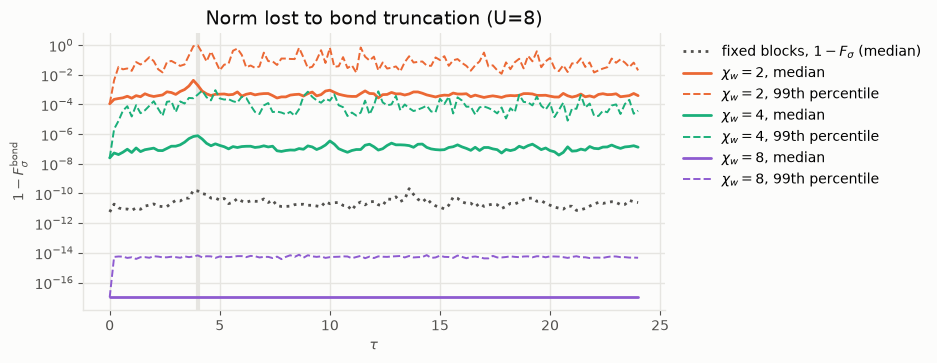

saved fw_block_data/L32_U8_nw200_eps1e-10_s1234_truncation_overlap_error.png


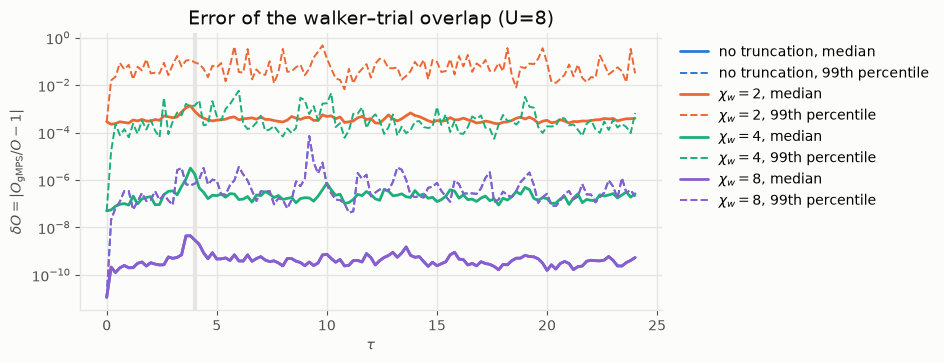

In [139]:
CHI_COLOR = {chi: PALETTE[i % len(PALETTE)] for i, chi in enumerate(TR)}
chi_label = lambda chi: "no truncation" if chi == 0 else rf"$\chi_w={chi}$"

fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.plot(tau, np.median(np.clip(1 - FF, 1e-17, None).reshape(len(tau), -1), axis=1), color=INK2, ls=":",
        label=r"fixed blocks, $1-F_\sigma$ (median)")
for chi in CHI_W:
    x = np.clip(1 - TR[chi]["f_bond"], 1e-17, None).reshape(len(tau), -1)
    ax.plot(tau, np.median(x, axis=1), color=CHI_COLOR[chi], label=f"{chi_label(chi)}, median")
    ax.plot(tau, np.percentile(x, 99, axis=1), color=CHI_COLOR[chi], ls="--", lw=1.4, label=f"{chi_label(chi)}, 99th percentile")
ax.axvline(tau[N_EQL], color=GRID, lw=3, zorder=0)
ax.set_yscale("log")
ax.set_xlabel(r"$\tau$"); ax.set_ylabel(r"$1-F^{\rm bond}_\sigma$")
ax.set_title("Norm lost to bond truncation")
ax.legend(**LEGEND)
save(fig, "truncation_fidelity"); plt.show()

fig, ax = plt.subplots(figsize=(7.5, 3.6))
for chi in TR:
    x = np.clip(TR[chi]["dO"], 1e-17, None)
    ax.plot(tau, np.median(x, axis=1), color=CHI_COLOR[chi], label=f"{chi_label(chi)}, median")
    ax.plot(tau, np.percentile(x, 99, axis=1), color=CHI_COLOR[chi], ls="--", lw=1.4, label=f"{chi_label(chi)}, 99th percentile")
ax.axvline(tau[N_EQL], color=GRID, lw=3, zorder=0)
ax.set_yscale("log")
ax.set_xlabel(r"$\tau$"); ax.set_ylabel(r"$\delta O=|O_{\rm gMPS}/O-1|$")
ax.set_title("Error of the walker–trial overlap")
ax.legend(**LEGEND)
save(fig, "truncation_overlap_error"); plt.show()

saved fw_block_data/L32_U8_nw200_eps1e-10_s1234_energy.png


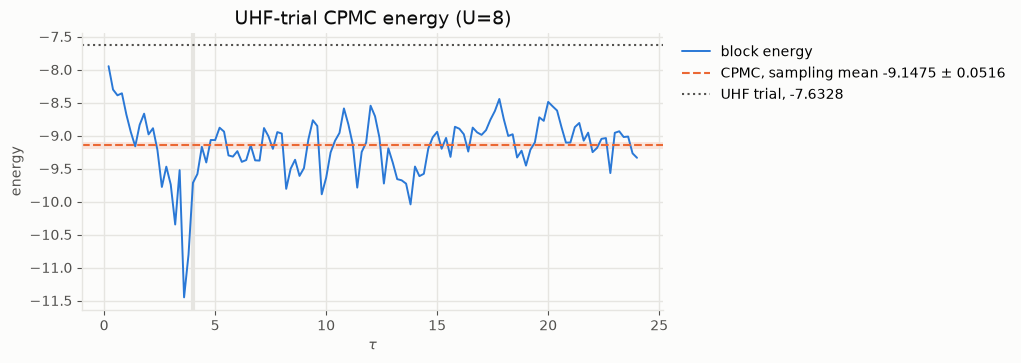

In [140]:
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.plot(tau[1:], energies, color=PALETTE[0], lw=1.4, label="block energy")
ax.axhline(E_MEAN, color=PALETTE[1], ls="--", lw=1.5,
           label=f"CPMC, sampling mean {E_MEAN:.4f} ± {E_ERR:.4f}")
if np.isfinite(E_ERR):
    ax.axhspan(E_MEAN - E_ERR, E_MEAN + E_ERR, color=PALETTE[1], alpha=0.15, lw=0)
ax.axhline(E_UHF, color=INK2, ls=":", lw=1.5, label=f"UHF trial, {E_UHF:.4f}")
ax.axvline(tau[N_EQL], color=GRID, lw=3, zorder=0)
ax.set_xlabel(r"$\tau$"); ax.set_ylabel("energy")
ax.set_title("UHF-trial CPMC energy")
ax.legend(**LEGEND)
save(fig, "energy"); plt.show()

## Three sources of error: fixed blocks, fixed particle counts, bond truncation (U = 8)

In [141]:
def channel_mps_own(C, plan, chi):
    # channel_mps with the walker's own kept counts: the same circuit and centre moves on untruncated shapes, but
    # every split zeroes all but the chi largest Schmidt values over its charge sectors. That is the state
    # channel_mps(C, plan, plan_bonds(C, plan, chi)) builds, with static shapes, so it vmaps over walkers.
    tensors = [jnp.eye(2)[int(o)].reshape(1, 2, 1) for o in plan.occupation]
    charges = [np.zeros(1, int)]
    for o in plan.occupation:
        charges.append(charges[-1] + int(o))
    angles, _ = channel_angles(C, plan)
    centre = None
    for site, theta in reversed(angles):
        centre = _move_centre(tensors, charges, centre, site)
        pair = gate_pair(tensors[site], tensors[site + 1], theta)
        Dl, _, _, Dr = pair.shape
        M = pair.reshape(2 * Dl, 2 * Dr)
        sp = sector_plan(charges[site], charges[site + 2])
        svds = [jnp.linalg.svd(M[np.ix_(r, c)], full_matrices=False) for r, c, _ in sp.sectors]
        s_all = jnp.concatenate([s for _, s, _ in svds])
        keep = jnp.zeros(s_all.shape).at[jnp.argsort(-s_all)[:chi]].set(1.0)
        left, right, offset = [], [], 0
        for u, s, vh in svds:
            k = keep[offset:offset + s.shape[0]]
            offset += s.shape[0]
            left.append(u * k)
            right.append((s * k)[:, None] * vh)
        A, B = _assemble(left, right, sp)
        tensors[site], tensors[site + 1] = A.reshape(Dl, 2, -1), B.reshape(-1, 2, Dr)
        charges[site + 1] = sp.middle_charges
        centre = site + 1
    return tensors, charges


def dmrg_overlap(alpha, beta, qb):
    # <Psi_T | alpha x beta> for the DMRG trial, site by site with an environment E[a, b, t], without forming the
    # d=4 walker. The sign (-1)^(n_up q_dn), q_dn = down electrons left of the site, is combine_channels' reordering.
    E = jnp.ones((1, 1, 1))
    for A, B, q, Tt in zip(alpha, beta, qb, DMRG_TJ):
        sign = jnp.asarray((-1.0) ** np.asarray(q))
        E = sum(jnp.einsum("abt,ar,b,bs,tu->rsu", E, A[:, na, :], sign if na else jnp.ones_like(sign), B[:, nb, :],
                           Tt[:, na + 2 * nb, :], optimize=True) for na in (0, 1) for nb in (0, 1))
    return E[0, 0, 0]


def uhf_overlap(alpha, beta, qb):
    # <Psi_T | alpha x beta> for the UHF trial: one gMPS overlap per spin, with the trial's gauges
    (tA, gA), (tB, gB) = TRIAL_GMPS
    return gA * gB * jdot(tA, alpha) * jdot(tB, beta)


def make_errors(plans, bonds, chi, overlap):
    # one walker, both spins, on the fixed circuit: untruncated (full), production (kept counts frozen on the
    # reference) and own counts. Infidelities are against the full gMPS, overlaps relative to the full one's.
    def one(wa, wb):
        full, prod, own, gauge = [], [], [], []
        for s, w in enumerate((wa, wb)):
            Q, _ = jnp.linalg.qr(w)
            A, q, g = channel_mps(Q, plans[s])
            full.append((A, q))
            gauge.append(g)
            prod.append(channel_mps(Q, plans[s], bonds[s])[:2])
            own.append(channel_mps_own(Q, plans[s], chi))
        infid = lambda X, Y: 1 - jdot(X, Y) ** 2 / (jdot(X, X) * jdot(Y, Y))
        O = lambda v: overlap(v[0][0], v[1][0], v[1][1])
        O_full = O(full)
        return dict(gauge=jnp.stack(gauge),
                    prod=jnp.stack([infid(f[0], p[0]) for f, p in zip(full, prod)]),
                    own=jnp.stack([infid(f[0], o[0]) for f, o in zip(full, own)]),
                    kept_prod=jnp.stack([jdot(p[0], p[0]) for p in prod]),
                    kept_own=jnp.stack([jdot(o[0], o[0]) for o in own]),
                    O_full=gauge[0] * gauge[1] * O_full, r_prod=O(prod) / O_full, r_own=O(own) / O_full)
    return jax.jit(jax.vmap(one))


def top_schmidt(nu, chi, left, n):
    # the chi largest Schmidt values prod_k (nu_k or 1 - nu_k) at a cut and their charges (electrons left of the
    # cut), by a best-first search over flipped modes. nu: correlation spectrum of the left side (left=True) or of
    # the right side; n: electrons in the channel. Flipping a mode moves one electron out of or into that side.
    p = np.maximum(nu, 1 - nu)
    w = np.minimum(nu, 1 - nu) / p
    order = np.argsort(-w)
    w, step = w[order], np.where(nu[order] > 0.5, -1, 1)
    w, step = w[w > 0], step[w > 0]
    q0 = int(np.sum(nu > 0.5))
    if not left:
        q0, step = n - q0, -step
    P0 = float(np.prod(p))
    vals, qs, heap = [P0], [q0], []
    if len(w):
        heapq.heappush(heap, (-P0 * w[0], 0, P0 * w[0], q0 + step[0]))
    while heap and len(vals) < chi:
        _, j, val, q = heapq.heappop(heap)
        vals.append(val)
        qs.append(q)
        if j + 1 < len(w):
            heapq.heappush(heap, (-val * w[j + 1], j + 1, val * w[j + 1], q + step[j + 1]))      # also flip j+1
            swap = val / w[j] * w[j + 1]
            heapq.heappush(heap, (-swap, j + 1, swap, q - step[j] + step[j + 1]))              # flip j+1 instead of j
    return np.array(vals), np.array(qs, int)


def cut_top(Q, chi):
    # per cut b = 1..L-1: top_schmidt on the smaller side of the cut (the larger side only adds pure modes)
    L, n = Q.shape
    out = []
    for b in range(1, L):
        side = Q[:b] if b <= L - b else Q[b:]
        out.append(top_schmidt(np.clip(np.linalg.eigvalsh(side @ side.T), 0.0, 1.0), chi, b <= L - b, n))
    return out


# ---- check 1: Schmidt values and charges from nu against the dense state, one random L=10 determinant
from itertools import combinations
rng = np.random.default_rng(1)
Lc, Nc = 10, 4
Qc = np.linalg.qr(rng.standard_normal((Lc, Nc)))[0]
combos = np.array(list(combinations(range(Lc), Nc)))
psi = np.zeros(2 ** Lc)
psi[(1 << (Lc - 1 - combos)).sum(axis=1)] = np.linalg.det(Qc[combos])
pop = np.array([bin(i).count("1") for i in range(2 ** Lc)])
worst_val, mismatches = 0.0, 0
for b, (vals, qs) in enumerate(cut_top(Qc, 12), start=1):
    M = psi.reshape(2 ** b, -1)
    dense = sorted(((s ** 2, q) for q in range(max(0, Nc - (Lc - b)), min(b, Nc) + 1) for s in np.linalg.svd(
        M[np.ix_(pop[:2 ** b] == q, pop[:2 ** (Lc - b)] == Nc - q)], compute_uv=False)), reverse=True)[:len(vals)]
    worst_val = max(worst_val, np.abs(vals - [d[0] for d in dense]).max())
    mismatches += sorted(zip(np.round(vals, 12), qs)) != sorted((round(d[0], 12), d[1]) for d in dense)
print(f"nu products vs dense SVD (L={Lc}, 12 largest per cut): max |lambda difference| {worst_val:.1e}, "
      f"cuts with a charge mismatch {mismatches} of {Lc - 1}")

# ---- check 2: own counts against plan_bonds run on the walker, and production against the cached run above
w = 7
Q = np.linalg.qr(WALK[0][-1, w])[0]
for chi in CHI_W:
    own, _ = jax.jit(lambda q: channel_mps_own(q, PLAN[0], chi))(jnp.asarray(Q))
    bond_w = plan_bonds(Q, PLAN[0], chi, 0.0)
    ref = channel_mps(jnp.asarray(Q), PLAN[0], bond_w)[0]
    print(f"chi_w = {chi}: own counts vs channel_mps(Q, plan, plan_bonds(Q, ...)): 1 - fidelity "
          f"{1 - float(jdot(own, ref)) ** 2 / float(jdot(own, own) * jdot(ref, ref)):.1e}; kept norm "
          f"{float(jdot(own, own)):.12f} vs 1 - discarded {1 - bond_w.reference_discarded_weight:.12f}")

nu products vs dense SVD (L=10, 12 largest per cut): max |lambda difference| 1.2e-15, cuts with a charge mismatch 0 of 9
chi_w = 2: own counts vs channel_mps(Q, plan, plan_bonds(Q, ...)): 1 - fidelity 1.2e-11; kept norm 0.994390469496 vs 1 - discarded 0.994390696042
chi_w = 4: own counts vs channel_mps(Q, plan, plan_bonds(Q, ...)): 1 - fidelity 0.0e+00; kept norm 0.999999977936 vs 1 - discarded 0.999999977936
chi_w = 8: own counts vs channel_mps(Q, plan, plan_bonds(Q, ...)): 1 - fidelity -6.7e-16; kept norm 1.000000000000 vs 1 - discarded 1.000000000000


## A DMRG trial (U = 8)

In [142]:
DMRG_FILE = DATA_DIR / f"dmrg_trial_L{L}_U{U:g}_chi{DMRG_CHI_T}.npz"
if RERUN or not DMRG_FILE.exists():
    cfg = mcn.Config(L=L, n_up=N_UP, n_down=N_DN, hopping=T, interaction=U, trial_chi=DMRG_CHI_T, dmrg_sweeps=DMRG_SWEEPS)
    start = time.perf_counter()
    dmrg_mps, e_dmrg = mcn.run_dmrg(mcn.build_dmrg_hamiltonian(cfg), cfg)
    tensors, charges = mcn.densify_with_charges(dmrg_mps, L)
    h_tensors = mcn.compress_mps(mcn.apply_mpo(mcn.hubbard_mpo(L, T, U), tensors))
    np.savez_compressed(DMRG_FILE, e_dmrg=e_dmrg, **{f"T{i}": A for i, A in enumerate(tensors)},
                        **{f"H{i}": A for i, A in enumerate(h_tensors)}, **{f"q{i}": q for i, q in enumerate(charges)})
    print(f"DMRG in {time.perf_counter() - start:.0f} s; saved {DMRG_FILE}")

z = np.load(DMRG_FILE)
DMRG_T = [z[f"T{i}"] for i in range(L)]                  # trial MPS, d=4, local index n_up + 2 n_dn
DMRG_H = [z[f"H{i}"] for i in range(L)]                  # H |trial>, compressed
DMRG_Q = tuple(z[f"q{i}"] for i in range(L + 1))         # its (N_up, N_dn) bond labels
E_DMRG = float(z["e_dmrg"])
E_VAR = float(mcn.contract_real(DMRG_H, DMRG_T) / mcn.contract_real(DMRG_T, DMRG_T))
GAMMA = mcn.one_rdm(DMRG_T)
NO = tuple(mcn.natural_orbitals(g, n)[0] for g, n in zip(GAMMA, (N_UP, N_DN)))    # plan_reference="natural"
PLAN_NO = [make_orbital_plan(C, "adaptive", EPS) for C in NO]
B_NO = np.stack([p.block_sizes for p in PLAN_NO])
occ = mcn.natural_orbitals(GAMMA[0], N_UP)[1]
print(f"DMRG trial chi_T = {DMRG_CHI_T}: E = {E_DMRG:.8f} (<H> of the dense MPS {E_VAR:.8f}), bonds up to {max(A.shape[0] for A in DMRG_T)}")
print(f"natural occupations around the Fermi level (↑): {np.round(occ[N_UP - 3:N_UP + 3], 3)}")
for s, p in zip("↑↓", PLAN_NO):
    print(f"NO plan, spin {s}: B_k = {p.block_sizes.tolist()}, gates {int((p.block_sizes - 1).sum())}, "
          f"bond up to 2^(B-1) = {2 ** (p.block_sizes.max() - 1)}")

QC MPO site   0 / 32
QC MPO site   1 / 32
QC MPO site   2 / 32
QC MPO site   3 / 32
QC MPO site   4 / 32
QC MPO site   5 / 32
QC MPO site   6 / 32
QC MPO site   7 / 32
QC MPO site   8 / 32
QC MPO site   9 / 32
QC MPO site  10 / 32
QC MPO site  11 / 32
QC MPO site  12 / 32
QC MPO site  13 / 32
QC MPO site  14 / 32
QC MPO site  15 / 32
QC MPO site  16 / 32
QC MPO site  17 / 32
QC MPO site  18 / 32
QC MPO site  19 / 32
QC MPO site  20 / 32
QC MPO site  21 / 32
QC MPO site  22 / 32
QC MPO site  23 / 32
QC MPO site  24 / 32
QC MPO site  25 / 32
QC MPO site  26 / 32
QC MPO site  27 / 32
QC MPO site  28 / 32
QC MPO site  29 / 32
QC MPO site  30 / 32
QC MPO site  31 / 32
DMRG in 87 s; saved fw_block_data/dmrg_trial_L32_U8_chi8.npz
DMRG trial chi_T = 8: E = -10.18628851 (<H> of the dense MPS -10.18317052), bonds up to 8
natural occupations around the Fermi level (↑): [0.719 0.702 0.687 0.311 0.297 0.287]
NO plan, spin ↑: B_k = [5, 5, 5, 5, 5, 6, 5, 6, 5, 6, 5, 6, 5, 6, 5, 6, 5, 6, 5, 6, 5, 5, 5

In [143]:
DMRG_TAG = f"{RUN_TAG}_dmrgT{DMRG_CHI_T}_w{CHI_PROP}"
DMRG_WALKERS = DATA_DIR / f"{DMRG_TAG}_walkers.npz"
if RERUN or not DMRG_WALKERS.exists():
    bonds = [plan_bonds(C, p, CHI_PROP, 0.0) for C, p in zip(NO, PLAN_NO)]
    wops = mcn.make_walker_ops(*NO, *PLAN_NO, *bonds, DMRG_T, DMRG_Q, tuple(jnp.asarray(A) for A in DMRG_H))
    dmrg_prop = mcn.make_fast_prop_ops(ham, system.walker_kind, wops.overlap, wops.sweep)
    dmrg_trial_ops = make_auto_trial_ops(system, overlap_u=wops.overlap, get_rdm1=uhf_get_rdm1)
    dmrg_meas = MeasOps(overlap=wops.overlap, kernels={k_energy: wops.energy})
    start_det = UhfTrial(mo_coeff_a=jnp.asarray(NO[0]), mo_coeff_b=jnp.asarray(NO[1]))   # only its orbitals are used: the walker start
    run_blocks, ctx, state = setup(dmrg_prop, dmrg_trial_ops, dmrg_meas, start_det, ham, params)
    n_total = N_EQL + N_BLOCKS
    snaps_up, snaps_dn, energies_d, weights_d = [], [], [], []
    start = time.perf_counter()
    for b in range(n_total + 1):
        if b:
            state, scalars, _ = run_blocks(state, **ctx, n_blocks=1)
            energies_d.append(float(scalars["energy"][0]))
            weights_d.append(float(scalars["weight"][0]))
        snaps_up.append(np.asarray(state.walkers[0]))
        snaps_dn.append(np.asarray(state.walkers[1]))
        if b % 10 == 0:
            print(f"block {b:4d}/{n_total}  E {energies_d[-1] if b else float(state.e_estimate):12.6f}"
                  f"  t {time.perf_counter() - start:6.1f} s", flush=True)
    config = dict(L=L, N_UP=N_UP, N_DN=N_DN, T=T, U=U, N_WALKERS=N_WALKERS, N_EQL=N_EQL, N_BLOCKS=N_BLOCKS,
                  N_PROP=N_PROP, DT=DT, SEED=SEED, DMRG_CHI_T=DMRG_CHI_T, CHI_PROP=CHI_PROP, E_DMRG=E_DMRG)
    np.savez_compressed(DMRG_WALKERS, up=np.stack(snaps_up), dn=np.stack(snaps_dn), energies=np.array(energies_d),
                        weights=np.array(weights_d), config=json.dumps(config))
    print(f"saved {DMRG_WALKERS}")

run_d = np.load(DMRG_WALKERS)
WALK_D = (run_d["up"], run_d["dn"])
energies_d, weights_d = run_d["energies"], run_d["weights"]
stats_d = blocking_analysis_ratio(energies_d[N_EQL:], weights_d[N_EQL:], print_q=False)
E_MEAN_D = float(stats_d["mu"])
E_ERR_D = float("nan") if stats_d["se_star"] is None else float(stats_d["se_star"])
print(f"{WALK_D[0].shape[0]} snapshots x {WALK_D[0].shape[1]} walkers;  CPMC energy (DMRG trial): "
      f"{E_MEAN_D:.6f} +- {E_ERR_D:.6f}   (DMRG trial {E_DMRG:.6f}, UHF trial CPMC {E_MEAN:.6f} +- {E_ERR:.6f})")

block    0/120  E   -10.284260  t    0.0 s
block   10/120  E   -10.225278  t  198.7 s
block   20/120  E   -10.257167  t  272.5 s
block   30/120  E   -10.246720  t  346.6 s
block   40/120  E   -10.228224  t  420.3 s
block   50/120  E   -10.259002  t  493.4 s
block   60/120  E   -10.240903  t  566.7 s
block   70/120  E   -10.234759  t  640.5 s
block   80/120  E   -10.234075  t  714.4 s
block   90/120  E   -10.234889  t  788.3 s
block  100/120  E   -10.234337  t  863.5 s
block  110/120  E   -10.257241  t  937.8 s
block  120/120  E   -10.243465  t 1011.8 s
saved fw_block_data/L32_U8_nw200_s1234_dmrgT8_w8_walkers.npz
121 snapshots x 200 walkers;  CPMC energy (DMRG trial): -10.243481 +- 0.001826   (DMRG trial -10.186289, UHF trial CPMC -9.147543 +- 0.051595)


In [144]:
DMRG_TJ = [jnp.asarray(A) for A in DMRG_T]
DATA_D = DATA_DIR / f"{DMRG_TAG}_eps{EPS:.0e}.npz"                  # block sizes and fixed-plan fidelities
if RERUN or not DATA_D.exists():
    start, out = time.perf_counter(), [analyse((up, dn), PLAN_NO) for up, dn in zip(*WALK_D)]
    np.savez_compressed(DATA_D, block_sizes=np.stack([o[0] for o in out]), fid_fixed=np.stack([o[1] for o in out]),
                        fid_own=np.stack([o[2] for o in out]), plan_block_sizes=B_NO)
    print(f"analysed {len(out)} snapshots in {time.perf_counter() - start:.0f} s; saved {DATA_D}")
data_d = np.load(DATA_D)
BS_D, FF_D, FO_D = data_d["block_sizes"].astype(int), data_d["fid_fixed"], data_d["fid_own"]

# check: the environment contraction dmrg_overlap against production's combine_channels + contract_real
Qa, Qb = (np.linalg.qr(W[-1, 0])[0] for W in WALK_D)
bonds_prop = [plan_bonds(C, p, CHI_PROP, 0.0) for C, p in zip(NO, PLAN_NO)]
(a, qa, _), (b, qb, _) = (channel_mps(jnp.asarray(Q), p, bp) for Q, p, bp in zip((Qa, Qb), PLAN_NO, bonds_prop))
ours, theirs = float(dmrg_overlap(a, b, qb)), float(mcn.contract_real(mcn.combine_channels(a, qa, b, qb)[0], DMRG_TJ))
print(f"dmrg_overlap vs combine_channels + contract_real: {ours:+.12e} vs {theirs:+.12e}, rel. diff {abs(ours / theirs - 1):.1e}")

stag = np.diag((-1.0) ** np.arange(L))
P_up, P_dn = (x @ x.T for x in (Qa, Qb))
print(f"particle-hole symmetry, a final walker: max |P_dn - (1 - S P_up S)| = "
      f"{np.abs(P_dn - (np.eye(L) - stag @ P_up @ stag)).max():.1e}  (both spins are analysed regardless)")
excess_d = BS_D - B_NO[None, None]
x = np.clip(1 - FF_D.prod(axis=2), 0, None)[samp].ravel()
print(f"sampling phase: B_k(phi) > B_k^ref in {(excess_d[samp] > 0).mean():.2%} of (walker, spin, site) entries, "
      f"{(excess_d[samp] > 0).any(axis=3).mean():.1%} of walker channels; largest walker block {BS_D[samp].max()} "
      f"(NO plan {B_NO.max()})")
print(f"fixed NO plan, 1-F per walker: median {np.median(x):.1e}, 99% {np.percentile(x, 99):.1e}, max {x.max():.1e}; "
      f"own plans, max {np.clip(1 - FO_D.prod(axis=2), 0, None)[samp].max():.1e}")

analysed 121 snapshots in 128 s; saved fw_block_data/L32_U8_nw200_s1234_dmrgT8_w8_eps1e-10.npz
dmrg_overlap vs combine_channels + contract_real: +2.030429679928e-02 vs +2.030429679928e-02, rel. diff 1.6e-15
particle-hole symmetry, a final walker: max |P_dn - (1 - S P_up S)| = 1.0e-15  (both spins are analysed regardless)
sampling phase: B_k(phi) > B_k^ref in 0.17% of (walker, spin, site) entries, 2.1% of walker channels; largest walker block 6 (NO plan 6)
fixed NO plan, 1-F per walker: median 2.3e-14, 99% 2.3e-10, max 7.4e-07; own plans, max 1.4e-09


saved fw_block_data/L32_U8_nw200_eps1e-10_s1234_max_block_dmrg.png


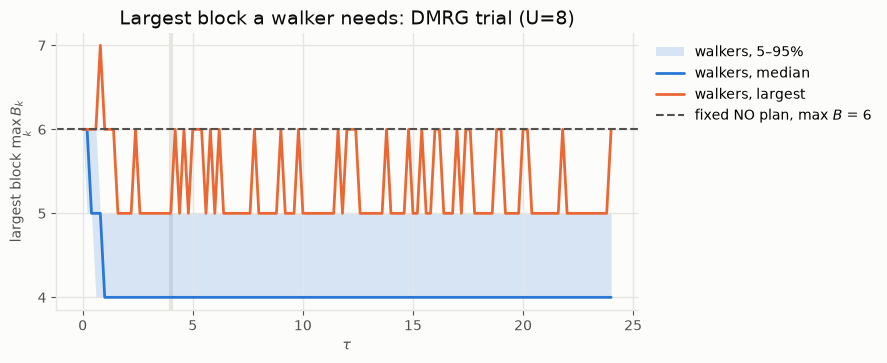

saved fw_block_data/L32_U8_nw200_eps1e-10_s1234_site_profile_dmrg.png


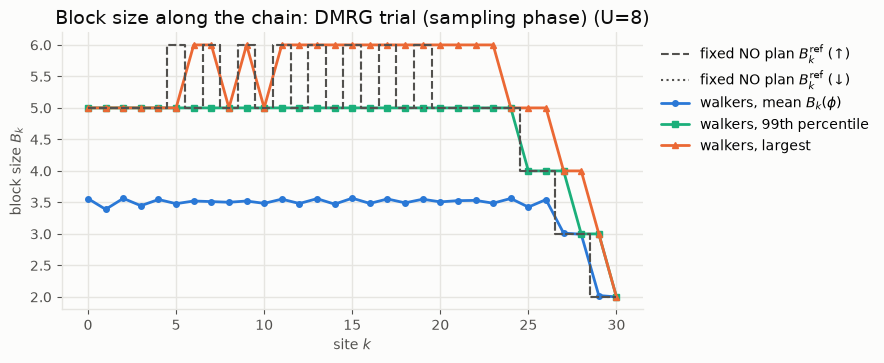

largest block per walker channel, sampling phase:
  UHF trial : B = 3: 0.1%,  B = 4: 84.8%,  B = 5: 15.1%,  B = 6: 0.0%
  DMRG trial: B = 3: 0.0%,  B = 4: 72.8%,  B = 5: 27.0%,  B = 6: 0.2%


In [145]:
# the block-size plots of the UHF section, for the DMRG-trial walkers against the NO plan
bmax_d = BS_D.max(axis=3).reshape(BS_D.shape[0], -1)            # per walker channel
tau_d = np.arange(BS_D.shape[0]) * N_PROP * DT
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.fill_between(tau_d, np.percentile(bmax_d, 5, axis=1), np.percentile(bmax_d, 95, axis=1),
                color=PALETTE[0], alpha=0.18, lw=0, label="walkers, 5–95%")
ax.plot(tau_d, np.median(bmax_d, axis=1), color=PALETTE[0], label="walkers, median")
ax.plot(tau_d, bmax_d.max(axis=1), color=PALETTE[1], label="walkers, largest")
ax.axhline(B_NO.max(), color=INK2, ls="--", lw=1.5, label=f"fixed NO plan, max $B$ = {B_NO.max()}")
ax.axvline(tau_d[N_EQL], color=GRID, lw=3, zorder=0)
ax.set_xlabel(r"$\tau$"); ax.set_ylabel(r"largest block $\max_k B_k$")
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.set_title("Largest block a walker needs: DMRG trial")
ax.legend(**LEGEND)
save(fig, "max_block_dmrg"); plt.show()

sites = np.arange(L - 1)
Bs_d = BS_D[samp].reshape(-1, L - 1)
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.step(sites, B_NO[0], where="mid", color=INK2, ls="--", lw=1.5, zorder=3, label=r"fixed NO plan $B_k^{\rm ref}$ (↑)")
if not np.array_equal(B_NO[0], B_NO[1]):
    ax.step(sites, B_NO[1], where="mid", color=INK2, ls=":", lw=1.5, zorder=3, label=r"fixed NO plan $B_k^{\rm ref}$ (↓)")
ax.plot(sites, Bs_d.mean(0), "o-", color=PALETTE[0], ms=4, label=r"walkers, mean $B_k(\phi)$")
ax.plot(sites, np.percentile(Bs_d, 99, axis=0), "s-", color=PALETTE[2], ms=4, label=r"walkers, 99th percentile")
ax.plot(sites, Bs_d.max(0), "^-", color=PALETTE[1], ms=4, label=r"walkers, largest")
ax.set_xlabel("site $k$"); ax.set_ylabel("block size $B_k$")
ax.set_title("Block size along the chain: DMRG trial (sampling phase)")
ax.legend(**LEGEND)
save(fig, "site_profile_dmrg"); plt.show()

print("largest block per walker channel, sampling phase:")
for label, B in (("UHF trial ", BS), ("DMRG trial", BS_D)):
    vals, counts = np.unique(B[samp].max(axis=3), return_counts=True)
    print(f"  {label}: " + ",  ".join(f"B = {v}: {c / counts.sum():.1%}" for v, c in zip(vals, counts)))

In [146]:
BONDS_NO = {chi: tuple(plan_bonds(C, p, chi, 0.0) for C, p in zip(NO, PLAN_NO)) for chi in CHI_W}
for chi in CHI_W:
    print(f"NO reference, chi_w = {chi}: reference discarded weight {BONDS_NO[chi][0].reference_discarded_weight:.1e} (↑)"
          f"  {BONDS_NO[chi][1].reference_discarded_weight:.1e} (↓)")
SETS = {
    "uhf": dict(label="UHF trial", walk=WALK, plans=PLAN, bonds=BONDS, overlap=uhf_overlap, F_fixed=FF, tag=TAG),
    "dmrg": dict(label=rf"DMRG trial ($\chi_T={DMRG_CHI_T}$)", walk=WALK_D, plans=PLAN_NO, bonds=BONDS_NO,
                 overlap=dmrg_overlap, F_fixed=FF_D, tag=f"{DMRG_TAG}_eps{EPS:.0e}"),
}
for st in SETS.values():
    st["tau"] = np.arange(st["walk"][0].shape[0]) * N_PROP * DT     # snapshot b at tau = b * N_PROP * DT
    st["samp"] = slice(N_EQL + 1, None)
CHI_MAX = max(CHI_W)


def optimum(walk, bonds):
    # per walker channel and chi: the optimum max_b eps_b(chi) from the nu spectra; the number of cuts whose
    # dominant charge sector gets no kept state in the frozen allocation; the charges of the CHI_MAX largest
    # Schmidt values at the centre cut (-1 where there are fewer)
    n_snap, nw = walk[0].shape[:2]
    a = np.zeros((n_snap, nw, 2, len(CHI_W)))
    unkept = np.zeros((n_snap, nw, 2, len(CHI_W)), np.int16)
    centre_q = np.full((n_snap, nw, 2, CHI_MAX), -1, np.int16)
    for j in range(n_snap):
        for s in range(2):
            for w in range(nw):
                tops = cut_top(np.linalg.qr(walk[s][j, w])[0], CHI_MAX)
                for b, (vals, qs) in enumerate(tops, start=1):
                    cum = np.cumsum(vals)
                    for k, chi in enumerate(CHI_W):
                        a[j, w, s, k] = max(a[j, w, s, k], 1 - cum[min(chi, len(cum)) - 1])
                        unkept[j, w, s, k] += qs[0] not in bonds[chi][s].charges[b]
                qs = tops[L // 2 - 1][1]
                centre_q[j, w, s, :len(qs)] = qs
    return dict(a=a, unkept=unkept, centre_q=centre_q)


ERR, OPT = {}, {}
for key, st in SETS.items():
    ERR[key] = {}
    for chi in CHI_W:
        path = DATA_DIR / f"{st['tag']}_sources_chi{chi}.npz"
        if RERUN or not path.exists():
            start = time.perf_counter()
            f = make_errors(st["plans"], st["bonds"][chi], chi, st["overlap"])
            res = [jax.tree_util.tree_map(np.asarray, f(jnp.asarray(up), jnp.asarray(dn))) for up, dn in zip(*st["walk"])]
            np.savez_compressed(path, **{k: np.stack([r[k] for r in res]) for k in res[0]})
            print(f"{key}, chi_w = {chi}: {time.perf_counter() - start:.0f} s, saved {path}")
        ERR[key][chi] = dict(np.load(path))
    path = DATA_DIR / f"{st['tag']}_optimum.npz"
    if RERUN or not path.exists():
        start = time.perf_counter()
        np.savez_compressed(path, **optimum(st["walk"], st["bonds"]))
        print(f"{key}, optimum: {time.perf_counter() - start:.0f} s, saved {path}")
    OPT[key] = dict(np.load(path))

# checks: production against the truncation cell above; the gauge against det R; nothing beats the optimum
e = ERR["uhf"]
print(f"\nUHF: production 1-F^bond here vs the truncation cell: max |diff| "
      f"{max(np.abs(e[chi]['prod'] - (1 - TR[chi]['f_bond'])).max() for chi in CHI_W):.1e}")
for key, st in SETS.items():
    e, block_loss = ERR[key], np.clip(1 - st["F_fixed"], 0, None)
    gauge_err = max(np.abs(e[chi]["gauge"] ** 2 - st["F_fixed"]).max() for chi in CHI_W)
    viol = {chi: int((np.minimum(e[chi]["own"], e[chi]["prod"]) < OPT[key]["a"][..., k] - block_loss - 1e-12).sum())
            for k, chi in enumerate(CHI_W)}
    worse = {chi: (e[chi]["prod"] < e[chi]["own"] - 1e-15).mean() for chi in CHI_W}
    print(f"{key}: |gauge^2 - det R^2| max {gauge_err:.1e};  own counts or production below the optimum "
          f"(beyond the block loss): {viol};  production below own counts in "
          + ", ".join(f"{v:.1%} (chi_w={c})" for c, v in worse.items()) + " of walker channels")

NO reference, chi_w = 2: reference discarded weight 3.4e-02 (↑)  3.5e-02 (↓)
NO reference, chi_w = 4: reference discarded weight 6.5e-05 (↑)  5.5e-05 (↓)
NO reference, chi_w = 8: reference discarded weight 3.4e-08 (↑)  3.1e-08 (↓)
uhf, chi_w = 2: 64 s, saved fw_block_data/L32_U8_nw200_eps1e-10_s1234_sources_chi2.npz
uhf, chi_w = 4: 70 s, saved fw_block_data/L32_U8_nw200_eps1e-10_s1234_sources_chi4.npz
uhf, chi_w = 8: 68 s, saved fw_block_data/L32_U8_nw200_eps1e-10_s1234_sources_chi8.npz
uhf, optimum: 53 s, saved fw_block_data/L32_U8_nw200_eps1e-10_s1234_optimum.npz
dmrg, chi_w = 2: 154 s, saved fw_block_data/L32_U8_nw200_s1234_dmrgT8_w8_eps1e-10_sources_chi2.npz
dmrg, chi_w = 4: 164 s, saved fw_block_data/L32_U8_nw200_s1234_dmrgT8_w8_eps1e-10_sources_chi4.npz
dmrg, chi_w = 8: 172 s, saved fw_block_data/L32_U8_nw200_s1234_dmrgT8_w8_eps1e-10_sources_chi8.npz
dmrg, optimum: 51 s, saved fw_block_data/L32_U8_nw200_s1234_dmrgT8_w8_eps1e-10_optimum.npz

UHF: production 1-F^bond here vs the tr

### The fixed blocks' overlap error, for both trials (U = 8)

In [147]:
EPS_WIDE = {"uhf": 1e-15, "dmrg": 1e-13}     # tolerance of the wider reference plans: B = 7 (UHF), 8 (NO)
WIDE_EVERY, WIDE_CHUNK = 10, 50              # every 10th sampling snapshot; walkers per jitted batch
for key, st in SETS.items():
    ref = (Ca, Cb) if key == "uhf" else NO
    st["plans_wide"] = [make_orbital_plan(C, "adaptive", EPS_WIDE[key]) for C in ref]
    st["wide_snaps"] = np.arange(N_EQL + 1, st["walk"][0].shape[0], WIDE_EVERY)
    print(f"{key}: wide plan max B {max(p.block_sizes.max() for p in st['plans_wide'])} "
          f"(fixed plan {max(p.block_sizes.max() for p in st['plans'])}), {len(st['wide_snaps'])} snapshots")


def make_block_overlap(plans, plans_wide, overlap):
    # normalised overlaps <Psi_T|phi> of one walker through the fixed plan and through the wide plan (untruncated),
    # and the wide plan's own fidelity
    def one(wa, wb):
        conv = [[channel_mps(jnp.linalg.qr(w)[0], p) for w, p in zip((wa, wb), ps)] for ps in (plans, plans_wide)]
        O = [c[0][2] * c[1][2] * overlap(c[0][0], c[1][0], c[1][1]) for c in conv]
        return O[0], O[1], (conv[1][0][2] * conv[1][1][2]) ** 2
    return jax.jit(jax.vmap(one))


WIDE = {}
for key, st in SETS.items():
    path = DATA_DIR / f"{st['tag']}_block_overlap_wide{EPS_WIDE[key]:.0e}_every{WIDE_EVERY}.npz"
    if RERUN or not path.exists():
        start = time.perf_counter()
        f = make_block_overlap(st["plans"], st["plans_wide"], st["overlap"])
        res = []
        for j in st["wide_snaps"]:
            up, dn = st["walk"][0][j], st["walk"][1][j]
            parts = [f(jnp.asarray(up[i:i + WIDE_CHUNK]), jnp.asarray(dn[i:i + WIDE_CHUNK])) for i in range(0, len(up), WIDE_CHUNK)]
            res.append([np.concatenate([np.asarray(p[k]) for p in parts]) for k in range(3)])
        res = np.array(res)                                          # (3 quantities, ...) per snapshot
        np.savez_compressed(path, O_fixed=res[:, 0], O_wide=res[:, 1], F_wide=res[:, 2])
        print(f"{key}: {time.perf_counter() - start:.0f} s, saved {path}")
    WIDE[key] = dict(np.load(path))
    WIDE[key]["dO"] = np.abs(WIDE[key]["O_fixed"] / WIDE[key]["O_wide"] - 1)      # (n_wide_snaps, nw)

z = WIDE["uhf"]
exact = np.stack([np.linalg.det(np.einsum("ik,wil->wkl", Ca, np.linalg.qr(WALK[0][j])[0]))
                  * np.linalg.det(np.einsum("ik,wil->wkl", Cb, np.linalg.qr(WALK[1][j])[0])) for j in SETS["uhf"]["wide_snaps"]])
wide_err, fixed_err = np.abs(z["O_wide"] / exact - 1), np.abs(z["O_fixed"] / exact - 1)
print(f"\nUHF check against det(Psi^T Q), {exact.size} walkers:   median     99%       max")
print(f"  wide plan, |O_wide / O - 1|                         {np.median(wide_err):9.1e} {np.percentile(wide_err, 99):9.1e} {wide_err.max():9.1e}")
print(f"  fixed plan, exact |O_fixed / O - 1|                 {np.median(fixed_err):9.1e} {np.percentile(fixed_err, 99):9.1e} {fixed_err.max():9.1e}")
print(f"  fixed plan, against the wide plan                   {np.median(z['dO']):9.1e} {np.percentile(z['dO'], 99):9.1e} {z['dO'].max():9.1e}")
for key in SETS:
    x, loss = WIDE[key]["dO"], np.clip(1 - WIDE[key]["F_wide"], 0, None)
    print(f"{key}: fixed-block delta O against the wide plan: median {np.median(x):.1e}, 99% {np.percentile(x, 99):.1e}, "
          f"max {x.max():.1e};  wide plan's own 1-F: median {np.median(loss):.1e}, max {loss.max():.1e}")

uhf: wide plan max B 5 (fixed plan 4), 10 snapshots
dmrg: wide plan max B 7 (fixed plan 6), 10 snapshots
uhf: 27 s, saved fw_block_data/L32_U8_nw200_eps1e-10_s1234_block_overlap_wide1e-15_every10.npz
dmrg: 64 s, saved fw_block_data/L32_U8_nw200_s1234_dmrgT8_w8_eps1e-10_block_overlap_wide1e-13_every10.npz

UHF check against det(Psi^T Q), 2000 walkers:   median     99%       max
  wide plan, |O_wide / O - 1|                           7.1e-11   5.6e-09   1.6e-07
  fixed plan, exact |O_fixed / O - 1|                   4.7e-10   6.0e-07   4.7e-06
  fixed plan, against the wide plan                     3.1e-10   6.0e-07   4.7e-06
uhf: fixed-block delta O against the wide plan: median 3.1e-10, 99% 6.0e-07, max 4.7e-06;  wide plan's own 1-F: median 2.4e-15, max 2.3e-10
dmrg: fixed-block delta O against the wide plan: median 9.8e-12, 99% 7.5e-09, max 3.6e-07;  wide plan's own 1-F: median 0.0e+00, max 2.6e-13


### The three errors along the run (U = 8)

saved fw_block_data/L32_U8_nw200_eps1e-10_s1234_sources_tau_uhf.png


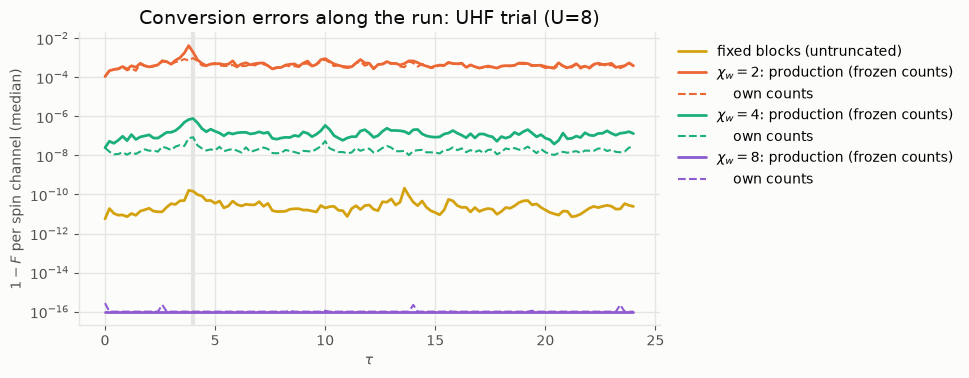

saved fw_block_data/L32_U8_nw200_eps1e-10_s1234_sources_tau_dmrg.png


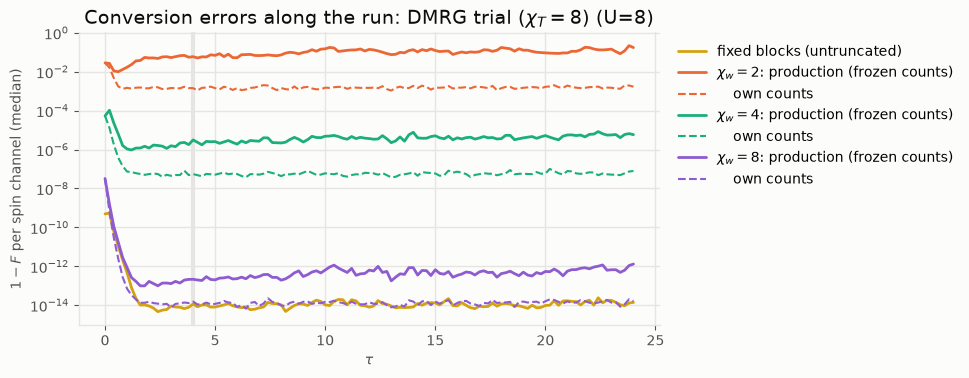

In [148]:
TRIAL_LS = {"uhf": "-", "dmrg": "--"}
SOURCE_COLOR = {"blocks": PALETTE[4], "truncation": PALETTE[0], "counts": PALETTE[1], "optimum": INK2}
SOURCE_LABEL = {"blocks": "fixed blocks", "truncation": "bond truncation (own counts)",
                "counts": "fixed particle counts (production − own)"}
FLOOR = 1e-16                                            # below roundoff, for log axes


def sources_of(key, chi):
    # per walker channel, (n_snap, nw, 2): the three sources, production's total truncation error and the optimum
    e, k = ERR[key][chi], CHI_W.index(chi)
    return dict(blocks=np.clip(1 - SETS[key]["F_fixed"], 0, None), truncation=np.clip(e["own"], 0, None),
                counts=e["prod"] - e["own"], production=np.clip(e["prod"], 0, None),
                optimum=np.clip(OPT[key]["a"][..., k], 0, None))


def median_tau(x):
    return np.median(np.maximum(x, FLOOR).reshape(x.shape[0], -1), axis=1)


for key, st in SETS.items():
    fig, ax = plt.subplots(figsize=(7.5, 3.8))
    ax.plot(st["tau"], median_tau(np.clip(1 - st["F_fixed"], 0, None)), color=SOURCE_COLOR["blocks"],
            label="fixed blocks (untruncated)")
    for chi in CHI_W:
        src = sources_of(key, chi)
        ax.plot(st["tau"], median_tau(src["production"]), color=CHI_COLOR[chi], label=f"{chi_label(chi)}: production (frozen counts)")
        ax.plot(st["tau"], median_tau(src["truncation"]), color=CHI_COLOR[chi], ls="--", lw=1.5, label="    own counts")
    ax.axvline(st["tau"][N_EQL], color=GRID, lw=3, zorder=0)
    ax.set_yscale("log")
    ax.set_xlabel(r"$\tau$"); ax.set_ylabel(r"$1-F$ per spin channel (median)")
    ax.set_title(f"Conversion errors along the run: {st['label']}")
    ax.legend(**LEGEND)
    save(fig, f"sources_tau_{key}"); plt.show()

/var/folders/j0/gqhj6qh51cqgcllfhm572rrw0000gp/T/ipykernel_57655/1898840385.py:6: RuntimeWarning: All-NaN slice encountered
  ax.plot(st["tau"], np.nanmedian(ratio.reshape(len(st["tau"]), -1), axis=1), color=CHI_COLOR[chi],


saved fw_block_data/L32_U8_nw200_eps1e-10_s1234_counts_factor_tau.png


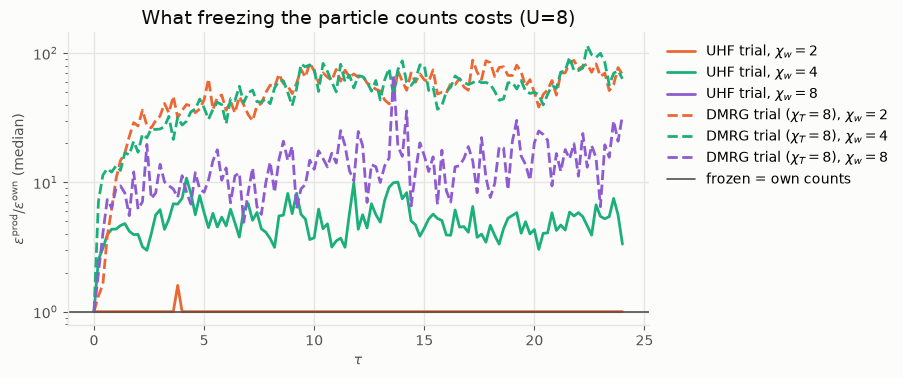

sampling phase, production / own counts per walker channel:   median   90%     99%
  uhf   chi_w = 2                                                 1.0      2.6     49.8
  uhf   chi_w = 4                                                 5.1     72.3    756.5
  uhf   chi_w = 8      own counts at roundoff in every walker channel: no ratio
  dmrg  chi_w = 2                                                57.4   1073.4   6080.1
  dmrg  chi_w = 4                                                55.8   2569.2  154743.9
  dmrg  chi_w = 8                                                14.0   1052.8  184098.6


In [149]:
fig, ax = plt.subplots(figsize=(7.5, 3.8))
for key, st in SETS.items():
    for chi in CHI_W:
        e = ERR[key][chi]
        ratio = np.where(e["own"] > 1e-13, np.maximum(e["prod"], FLOOR) / np.maximum(e["own"], FLOOR), np.nan)
        ax.plot(st["tau"], np.nanmedian(ratio.reshape(len(st["tau"]), -1), axis=1), color=CHI_COLOR[chi],
                ls=TRIAL_LS[key], label=f"{st['label']}, {chi_label(chi)}")
ax.axhline(1.0, color=INK2, lw=1.2, label="frozen = own counts")
ax.set_yscale("log")
ax.set_xlabel(r"$\tau$"); ax.set_ylabel(r"$\varepsilon^{\rm prod}/\varepsilon^{\rm own}$ (median)")
ax.set_title("What freezing the particle counts costs")
ax.legend(**LEGEND)
save(fig, "counts_factor_tau"); plt.show()

print("sampling phase, production / own counts per walker channel:   median   90%     99%")
for key, st in SETS.items():
    for chi in CHI_W:
        e = ERR[key][chi]
        own, prod = e["own"][st["samp"]].ravel(), e["prod"][st["samp"]].ravel()
        ok = own > 1e-13
        if not ok.any():
            print(f"  {key:5s} chi_w = {chi}      own counts at roundoff in every walker channel: no ratio")
            continue
        r = np.maximum(prod[ok], FLOOR) / own[ok]
        print(f"  {key:5s} chi_w = {chi}                                             {np.median(r):7.1f}  "
              f"{np.percentile(r, 90):7.1f}  {np.percentile(r, 99):7.1f}")

saved fw_block_data/L32_U8_nw200_eps1e-10_s1234_sources_ccdf_chi4.png


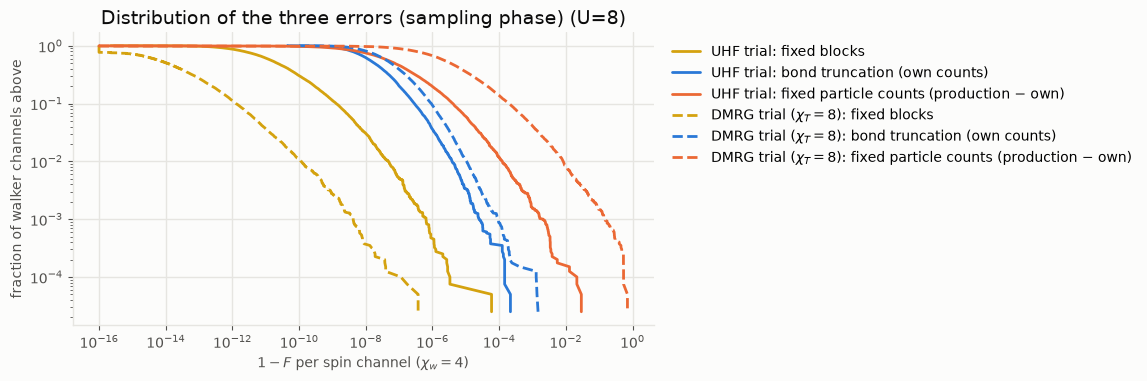

In [150]:
CHI_SHOW = 4
fig, ax = plt.subplots(figsize=(7.5, 3.8))
for key, st in SETS.items():
    src = sources_of(key, CHI_SHOW)
    for name in ("blocks", "truncation", "counts"):
        x = np.sort(np.maximum(src[name][st["samp"]].ravel(), FLOOR))
        ax.plot(x, 1 - np.arange(x.size) / x.size, color=SOURCE_COLOR[name], ls=TRIAL_LS[key],
                label=f"{st['label']}: {SOURCE_LABEL[name]}")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(rf"$1-F$ per spin channel ($\chi_w={CHI_SHOW}$)"); ax.set_ylabel("fraction of walker channels above")
ax.set_title("Distribution of the three errors (sampling phase)")
ax.legend(**LEGEND)
save(fig, f"sources_ccdf_chi{CHI_SHOW}"); plt.show()

## Comparison: all three sources, both trials (U = 8)

sampling phase, 1-F per spin channel: median (99th percentile)
trial  chi_w         fixed blocks      bond truncation         fixed counts     production total              optimum       prod/own
uhf        2    2.2e-11 (4.7e-08)    4.0e-04 (1.7e-02)    0.0e+00 (1.0e-01)    4.4e-04 (1.1e-01)    2.0e-04 (1.2e-02)            1.1
uhf        4    2.2e-11 (4.7e-08)    1.8e-08 (3.8e-06)    7.3e-08 (1.2e-04)    1.2e-07 (1.3e-04)    9.1e-09 (2.8e-06)            6.8
uhf        8    2.2e-11 (4.7e-08)    0.0e+00 (1.8e-15)    0.0e+00 (1.8e-15)    0.0e+00 (0.0e+00)    2.9e-15 (5.2e-12)            0.0

dmrg       2    1.1e-14 (1.2e-10)    1.5e-03 (7.0e-02)    9.7e-02 (1.0e+00)    1.0e-01 (1.0e+00)    5.0e-04 (1.6e-02)           68.5
dmrg       4    1.1e-14 (1.2e-10)    5.6e-08 (1.1e-05)    3.4e-06 (8.2e-03)    3.8e-06 (8.2e-03)    2.4e-08 (5.1e-06)           67.8
dmrg       8    1.1e-14 (1.2e-10)    1.3e-14 (2.8e-11)    3.4e-13 (4.8e-08)    4.5e-13 (4.8e-08)    7.7e-15 (1.9e-11)           33.7

samp

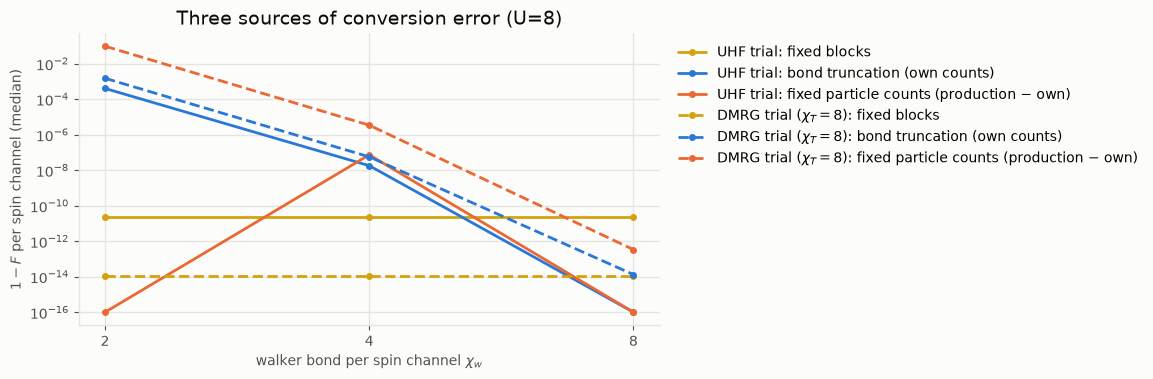

saved fw_block_data/L32_U8_nw200_eps1e-10_s1234_sources_compare_overlap.png


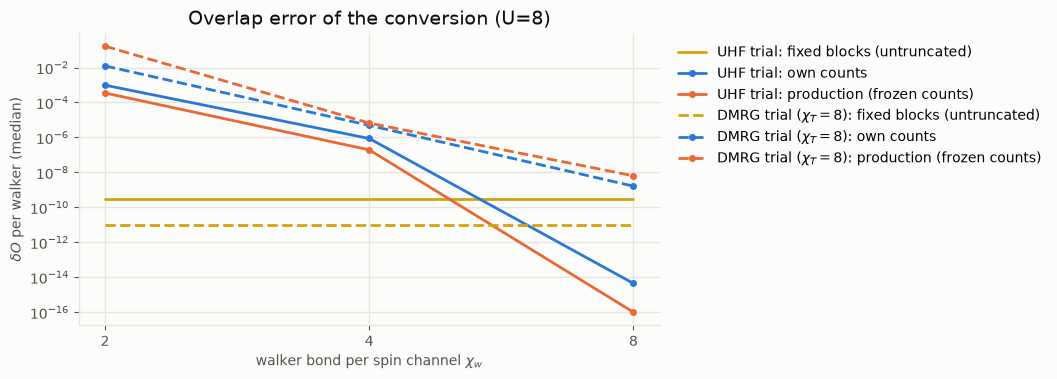

In [151]:
q = lambda x, sm: f"{np.median(x[sm]):8.1e} ({np.percentile(x[sm], 99):7.1e})"
print("sampling phase, 1-F per spin channel: median (99th percentile)")
print(f"{'trial':6s} {'chi_w':>5s}   {'fixed blocks':>18s}   {'bond truncation':>18s}   {'fixed counts':>18s}   "
      f"{'production total':>18s}   {'optimum':>18s}   {'prod/own':>12s}")
for key, st in SETS.items():
    for chi in CHI_W:
        src, sm = sources_of(key, chi), st["samp"]
        ratio = np.median(src["production"][sm]) / max(np.median(src["truncation"][sm]), FLOOR)
        print(f"{key:6s} {chi:5d}   {q(src['blocks'], sm)}   {q(src['truncation'], sm)}   {q(src['counts'], sm)}   "
              f"{q(src['production'], sm)}   {q(src['optimum'], sm)}   {ratio:12.1f}")
    print()

print("sampling phase, delta O per walker: median (99th percentile)")
print(f"{'trial':6s} {'chi_w':>5s}   {'fixed blocks':>18s}   {'own counts':>18s}   {'production':>18s}   {'prod/own':>8s}")
for key, st in SETS.items():
    sm, dO_blocks = st["samp"], WIDE[key]["dO"]
    blk = f"{np.median(dO_blocks):8.1e} ({np.percentile(dO_blocks, 99):7.1e})"
    for chi in CHI_W:
        e = ERR[key][chi]
        own, prod = np.abs(e["r_own"] - 1), np.abs(e["r_prod"] - 1)
        print(f"{key:6s} {chi:5d}   {blk}   {q(own, sm)}   {q(prod, sm)}   {np.median(prod[sm]) / max(np.median(own[sm]), FLOOR):8.1f}")
    print()
print("fixed blocks: against the wider plan, every WIDE_EVERY-th sampling snapshot (UHF, exact: "
      f"{np.median(TR[0]['dO'][SETS['uhf']['samp']]):.1e} median)")

x = np.array(CHI_W)
fig, ax = plt.subplots(figsize=(7.5, 3.8))
for key, st in SETS.items():
    sm = st["samp"]
    for name in ("blocks", "truncation", "counts"):
        y = [np.median(np.maximum(sources_of(key, chi)[name][sm], FLOOR)) for chi in CHI_W]
        ax.plot(x, y, ls=TRIAL_LS[key], marker="o", ms=4, color=SOURCE_COLOR[name], label=f"{st['label']}: {SOURCE_LABEL[name]}")
ax.set_xscale("log", base=2); ax.set_yscale("log"); ax.set_xticks(x, [str(c) for c in CHI_W])
ax.set_xlabel(r"walker bond per spin channel $\chi_w$"); ax.set_ylabel(r"$1-F$ per spin channel (median)")
ax.set_title("Three sources of conversion error")
ax.legend(**LEGEND)
save(fig, "sources_compare"); plt.show()

fig, ax = plt.subplots(figsize=(7.5, 3.8))
for key, st in SETS.items():
    sm = st["samp"]
    ax.plot(x, [np.median(WIDE[key]["dO"])] * len(x), ls=TRIAL_LS[key], color=SOURCE_COLOR["blocks"],
            label=f"{st['label']}: fixed blocks (untruncated)")
    for name, rkey in (("truncation", "r_own"), ("counts", "r_prod")):
        y = [np.median(np.maximum(np.abs(ERR[key][chi][rkey][sm] - 1), FLOOR)) for chi in CHI_W]
        ax.plot(x, y, ls=TRIAL_LS[key], marker="o", ms=4, color=SOURCE_COLOR[name],
                label=f"{st['label']}: " + ("own counts" if rkey == "r_own" else "production (frozen counts)"))
ax.set_xscale("log", base=2); ax.set_yscale("log"); ax.set_xticks(x, [str(c) for c in CHI_W])
ax.set_xlabel(r"walker bond per spin channel $\chi_w$"); ax.set_ylabel(r"$\delta O$ per walker (median)")
ax.set_title("Overlap error of the conversion")
ax.legend(**LEGEND)
save(fig, "sources_compare_overlap"); plt.show()